### Воспроизводимость и импорты

Блокнот запускался в гугл коллаб

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random
import os
import pandas as pd
import gc
from collections import Counter

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(14)

# Определим девайс
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


При желании взять веса можно отсюда https://drive.google.com/drive/folders/1vhb0M_biYr5smT_0oZzpNLzNH8JmwWEF?usp=sharing

### Критерии оценки

Итоговая оценка — **100 баллов**, из трёх блоков:
- **Содержание проекта** — 50 баллов
- **Защита проекта** — 40 баллов
- **Индивидуальный вклад** — 10 баллов

Каждый критерий оценивается по шкале до 10 баллов:

| Баллы | Уровень |
|-------|---------|
| 10–8 | Отлично: исчерпывающее представление, результаты полноценно подтверждены, нет существенных недочётов |
| 7–6 | Хорошо: требования соблюдены, логика и доказательность в целом достаточны, недочёты точечные |
| 5–4 | Частично: значимые недочёты (ошибки в логике, слабая доказательность, недостаток экспериментов), выводы ограниченно подтверждены |
| 3–1 | Формально: существенные ошибки, отсутствуют необходимые обоснования, результат неполный или недостоверный |

**Содержание проекта (50 баллов)**

- **Подготовка и обработка данных** — 10 баллов
  Корректность и полнота предобработки, качество входного представления, отсутствие утечек, корректная организация train/validation, обоснование решений

- **Обоснованность моделей** — 10 баллов
  Корректность выбора моделей для задачи последовательного предсказания, соответствие ограничениям данных, аргументация гиперпараметров/архитектуры, сравнение подходов и обоснование выбора «3 лучших»

- **Качество метрики и её обоснованность** — 10 баллов
  Корректность выбора и расчёта метрики, валидационный протокол, интерпретация метрики, сопоставимость результатов между моделями, обоснованность заявленных улучшений

- **Анализ ошибок** — 10 баллов
  Выявление типовых ошибок и режимов деградации, анализ причин, демонстрация примеров/срезов, предложения по улучшению, проверка гипотез

- **Воспроизводимость** — 10 баллов
  Возможность полного воспроизведения результатов по ноутбуку, наличие инструкций и фиксации окружения/seed, корректность запуска «с нуля», контроль расхождений при повторных запусках

**Защита проекта (40 баллов)**

- **Ясность** — 10 баллов
  Понятность постановки задачи, корректность терминологии, ясность выводов, отсутствие противоречий, качество устного изложения

- **Структура** — 10 баллов
  Логика подачи, соблюдение регламента (15 мин. выступление + 10 мин. вопросы), связность рассказа, распределение ролей

- **Визуализация результатов** — 10 баллов
  Корректность и информативность графиков/таблиц, сравнение моделей, иллюстрация ключевых эффектов, читабельность слайдов

- **Ответы на вопросы** — 10 баллов
  Корректность, полнота и аргументированность ответов, владение деталями решения, способность объяснить ограничения и риски, реакция на замечания

**Индивидуальный вклад (10 баллов)**

Выставляется каждому участнику индивидуально. Учитываются: активность в ходе защиты, степень вовлечённости в представление проекта, вклад в разработку оригинальных решений, полнота и корректность ответов на вопросы.

### Постановка задачи

**Кейс:** Моделирование и прогноз динамики операций в банковских данных
**Конкурс:** «Твой проект», 2025/2026 учебный год, направление «Интеллектуальный анализ данных»

Дан набор банковских данных — история покупок (транзакций), агрегированная по объектам наблюдения (клиент или карта). Каждый объект описывается тремя полями:

- **`Id`** — уникальный идентификатор объекта
- **`Data`** — последовательность MCC-кодов в хронологическом порядке совершения покупок; длина истории варьируется от нескольких событий до 200; коды могут повторяться, отражая регулярные паттерны трат
- **`Target`** — продолжение той же последовательности: 8 следующих покупок, которые необходимо предсказать; повторы также возможны

**Цель** — построить модель, которая по истории `Data` предсказывает последовательность `Target`. Практическое применение подобных моделей: понимание клиентских паттернов, персонализация предложений, планирование коммуникаций.

Данные представлены двумя файлами: `df_train.csv` (обучение) и `df_test.csv` (валидация).

**Требуемые результаты:**

1. **Jupyter Notebook** — воспроизводимый код с описанием данных, предобработки, признаков и не менее трёх моделей с оценкой их качества
2. **Презентация** — наглядный разбор проделанной работы и выводов; на защите команда представляет результаты и отвечает на вопросы комиссии

Важно: приоритет не на сложность моделей, а на **корректность, логику и понятность** решения.

### Особенности задачи

В данном кейсе требуется по последовательности прошлых транзакций `Data` предсказать 8 следующих MCC-кодов, образующих целевую последовательность `Target`.
При этом в целевой последовательности возможны повторы, а длина входной истории различается между объектами, поэтому задача ближе не к обычной многоклассовой классификации, а к задаче **последовательного предсказания / next-basket recommendation**.  
Следовательно, качество решения должно отражать сразу два аспекта: насколько модель восстанавливает **состав** будущих MCC-кодов и насколько корректно она располагает их по **позициям** в предсказании.

### Обзор литературы

Задача предсказания следующих транзакций (MCC-кодов) концептуально пересекается с областью рекомендательных систем, в частности с направлениями **Next-Basket Recommendation (NBR)** и **Next-Purchase Prediction**. В академической среде для таких задач сложился определенный стандарт оценки, который мы взяли за основу.

Ниже представлены ключевые исследования, определившие наш выбор метрик:

**1. Фундаментальный бенчмарк по рекомендациям корзин**
* **Исследование:** *«A Systematical Evaluation for Next-Basket Recommendation Algorithms»* (Shao et al., 2022) [[arXiv:2209.02892](https://arxiv.org/pdf/2209.02892)]
* **Используемые метрики:** Recall@K, Precision@K, F1@K, NDCG@K, MAP@K, MRR@K, PHR (Person-wise Hit Ratio).
* **Причина включения:** Это наиболее полный современный обзор подходов к задаче NBR. Авторы доказывают, что при предсказании набора будущих элементов (как наши 8 кодов) де-факто стандартом является оценка через полноту угадывания (Recall) и качество ранжирования выдачи (NDCG, MAP).

**2. Учет повторяющихся действий в прогнозе**
* **Исследование:** *«A Next Basket Recommendation Reality Check»* (Li et al., 2023, ACM TOIS) [[arXiv:2109.14233](https://arxiv.org/pdf/2109.14233)]
* **Используемые метрики:** Recall@K, NDCG@K, а также специализированные метрики повторов (Repetition Ratio — RepR, Recall_rep).
* **Причина включения:** В описании нашего кейса прямо указано, что MCC-коды могут повторяться, отражая привычки клиента. Данная статья делает акцент на предсказании именно повторяющихся паттернов потребления и подтверждает, что связка Recall + NDCG является оптимальной базой для оценки таких последовательностей.

**3. Применение на реальных банковских данных**
* **Исследование:** *«Sequential Recommendation Model for Next Purchase Prediction»* (Chen et al., 2022) [[arXiv:2207.06225](https://arxiv.org/pdf/2207.06225)]
* **Используемые метрики:** MAP@K, Recall@K.
* **Причина включения:** В отличие от классического E-commerce, в данной работе модели обучаются **непосредственно на последовательностях транзакций по кредитным картам**. Использование авторами ранговых метрик подтверждает, что методология рекомендательных систем (в частности, Recall и MAP/NDCG) абсолютно валидна для прогнозирования финансовых операций и MCC-кодов.

**4. Значимость позиции первого правильного прогноза**
* **Источник:** Обзоры индустриальных стандартов оценки рекомендательных систем (Habr / PVSM, 2025) [[habr](https://habr.com/ru/companies/X5Tech/articles/885376/)]
* **Используемые метрики:** MRR (Mean Reciprocal Rank), Hit Rate.
* **Причина включения:** Показывает важность метрики MRR для бизнес-задач. Для банка может быть критически важно угадать правильную транзакцию на первых позициях предсказания, чтобы сделать клиенту релевантный оффер. MRR идеально отражает, насколько быстро (высоко в списке) модель выдает первый правильный код.

**Резюме по литературе:** Анализ предметной области показывает, что индустриальным и академическим стандартом для таких задач является комбинирование метрик охвата (Recall@K) и метрик качества ранжирования (NDCG@K, MRR). Однако так как нам важно предсказать именно правильную последовательность, то основными метриками будут Recall@1 для каждого этапа предсказания(всего их 8), и MRR для понимания того насколько бытро пользователь увидит релевантную транзакцию.

### Выбор метрик

Таким образом, для итогового сравнения моделей принимается следующий набор метрик:

- **Positional Accuracy** — Самая интерпритируемая метрика, которая показывает качество предсказания именно последовательности данных;поэтому используется нами как одна из основных метрик сравнения.
- **Positional MRR** — Ранговая метрика; характеризует позицию первого корректного предсказания и позволяет оценить, насколько быстро модель предлагает релевантную транзакцию.
- **NDCG@8** — ранговая метрика; учитывает не только факт попадания, но и позицию правильных предсказаний, придавая больший вес элементам в верхней части списка.
- **Recall@8** — вспомогательная метрика качества из статей; отражает полноту восстановления целевых MCC-кодов и показывает, какая доля фактически совершённых транзакций была предсказана моделью.

Итоговое сопоставление моделей проводится по метрикам **Recall@8** и **NDCG@8** как основным, а также **MRR** как дополнительной метрике, отражающей прикладную ценность ранних попаданий. Метрика **Hit Rate@8** используется для дополнительной интерпретации результатов и проверки согласованности поведения моделей.

Такой выбор метрик соответствует практике задач next-basket recommendation и sequential/timeline recommendation, обеспечивая одновременную оценку полноты предсказаний и качества их ранжирования, а также сопоставимость результатов в рамках единого валидационного протокола.

### Предварительный анализ данных (EDA)

#### Функции блока

##### Парсинг строк mcc кодов

In [ ]:
import pandas as pd
from typing import List, Optional

def parse_sequence_columns(
    df: pd.DataFrame,
    columns: Optional[List[str]] = None,
    sep: str = ','
) -> pd.DataFrame:
    """
    Преобразует строковые представления последовательностей в списки элементов.

    Функция создает копию датафрейма и разделяет строки в указанных колонках
    по заданному разделителю, превращая их в списки (list). Исходный
    датафрейм не модифицируется (pure function).

    Args:
        df (pd.DataFrame): Исходный датафрейм.
        columns (List[str], optional): Список колонок для преобразования.
            По умолчанию ['Data', 'Target'].
        sep (str): Символ-разделитель. По умолчанию ','.

    Returns:
        pd.DataFrame: Новый датафрейм со столбцами типа list.
    """
    if columns is None:
        columns = ['Data', 'Target']

    df_processed = df.copy()

    for col in columns:
        if col in df_processed.columns:
            # Преобразуем только строковые значения, пропуская NaN
            df_processed[col] = df_processed[col].astype(str).str.split(sep)

    return df_processed

##### Базовая статистика mcc кодов

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

_MERGED = "__MERGED__"

def _format_smart(val):
    if val == _MERGED:
        return val
    if isinstance(val, (int, np.integer)):
        return f"{val:,}".replace(',', ' ')
    if isinstance(val, (float, np.float64)):
        if val == int(val):
            return f"{int(val):,}".replace(',', ' ')
        return f"{val:.2f}"
    return str(val)


def _get_sequence_stats(series: pd.Series, name: str) -> pd.DataFrame:
    lengths = series.apply(len)
    stats = lengths.describe(percentiles=[0.25, 0.5, 0.75]).drop('count')
    df_stats = stats.to_frame(name=name).reset_index()
    df_stats.columns = ['Метрика', name]
    return df_stats


def _shannon_entropy(series: pd.Series) -> float:
    probs = series.value_counts(normalize=True).values
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def _gini(series: pd.Series) -> float:
    counts = np.sort(series.value_counts().values).astype(float)
    n = len(counts)
    return float((2 * np.sum(np.arange(1, n + 1) * counts) / (n * counts.sum())) - (n + 1) / n)


def _top10_share(series: pd.Series) -> float:
    return float(series.value_counts(normalize=True).head(10).sum() * 100)


def _calculate_full_mcc_metrics(df_train: pd.DataFrame, df_test: pd.DataFrame):
    train_exp = df_train['Data'].explode()
    test_exp  = df_test['Data'].explode()

    train_unique = set(train_exp.unique())
    test_unique  = set(test_exp.unique())
    common       = train_unique & test_unique

    code_coverage = f"{len(common) / len(test_unique) * 100:.1f}%"
    vol_coverage  = f"{test_exp.isin(train_unique).mean() * 100:.1f}%"

    # Сессии длиной == max считаются обрезанными (реальный конец неизвестен)
    max_len     = max(df_train['Data'].apply(len).max(), df_test['Data'].apply(len).max())
    trunc_train = f"{(df_train['Data'].apply(len) == max_len).mean() * 100:.1f}%"
    trunc_test  = f"{(df_test['Data'].apply(len)  == max_len).mean() * 100:.1f}%"

    rows = [
        ["Всего транзакций (mcc)",                  len(train_exp),                   len(test_exp)],
        ["Уникальных MCC",                          len(train_unique),                len(test_unique)],
        ["Кол-во сессий (строк)",                   len(df_train),                    len(df_test)],

        ["--- Пересечение множеств ---",            "---",                            "---"],
        ["Общих MCC кодов",                         _MERGED,                          len(common)],
        ["Только в этом датасете",                  len(train_unique - test_unique),  len(test_unique - train_unique)],
        ["Покрытие тестом кодов трейна",            _MERGED,                          code_coverage],
        ["Покрытие по объёму транзакций",           _MERGED,                          vol_coverage],

        ["--- Распределение MCC ---",               "---",                            "---"],
        ["Энтропия Шеннона (бит)",                  _shannon_entropy(train_exp),      _shannon_entropy(test_exp)],
        ["Топ-10 MCC, % транзакций",                _top10_share(train_exp),          _top10_share(test_exp)],
        ["Gini-коэффициент",                        _gini(train_exp),                 _gini(test_exp)],

        ["--- Статистика длин рядов ---",           "---",                            "---"],
    ]
    df_base = pd.DataFrame(rows, columns=['Метрика', 'Train', 'Test'])

    df_lens = pd.merge(
        _get_sequence_stats(df_train['Data'], "Train"),
        _get_sequence_stats(df_test['Data'],  "Test"),
        on="Метрика",
    )
    df_trunc = pd.DataFrame(
        [["Сессий с макс. длиной (обрезаны)", trunc_train, trunc_test]],
        columns=['Метрика', 'Train', 'Test'],
    )

    full_stats = pd.concat([df_base, df_lens, df_trunc], ignore_index=True)

    # Собираем ДО форматирования, но сразу форматируем значения
    merged_meta = {
        idx: _format_smart(full_stats.loc[idx, 'Test'])
        for idx in full_stats.index[full_stats['Train'] == _MERGED]
    }

    for col in ['Train', 'Test']:
        full_stats[col] = full_stats[col].apply(_format_smart)
    full_stats['Train'] = full_stats['Train'].replace(_MERGED, "")

    return full_stats, merged_meta


def _apply_cell_styles(table, full_stats: pd.DataFrame, merged_meta: dict):
    merged_rows = set(merged_meta.keys())

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#eeeeee')

        if col == 0:
            cell.get_text().set_ha('left')
        else:
            cell.get_text().set_ha('center')

        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            continue

        data_row = row - 1
        is_sep   = "---" in str(full_stats.iloc[data_row, 0])
        bg       = '#fcfcfc' if row % 2 == 0 else 'white'

        if is_sep:
            cell.set_facecolor('#f8f9fa')
            cell.set_text_props(weight='bold', color='#555555')

        elif data_row in merged_rows:
            cell.set_facecolor(bg)
            if col == 1:
                cell.visible_edges = 'TBL'
            elif col == 2:
                cell.visible_edges = 'TBR'
                cell.get_text().set_text('')

        else:
            if row % 2 == 0:
                cell.set_facecolor(bg)


def _draw_merged_texts(table, merged_meta: dict, fig):
    """bbox берём после tight_layout — позиции уже финальные."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    fig_inv  = fig.transFigure.inverted()

    for data_row, value in merged_meta.items():
        table_row = data_row + 1
        bb1 = table[table_row, 1].get_window_extent(renderer)
        bb2 = table[table_row, 2].get_window_extent(renderer)
        cx  = (bb1.x0 + bb2.x1) / 2
        cy  = (bb1.y0 + bb1.y1) / 2
        fx, fy = fig_inv.transform((cx, cy))
        fig.text(fx, fy, value, ha='center', va='center', fontsize=10)


def plot_mcc_comprehensive_summary(df_train: pd.DataFrame, df_test: pd.DataFrame):
    full_stats, merged_meta = _calculate_full_mcc_metrics(df_train, df_test)

    fig_height = max(8, len(full_stats) * 0.48)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=full_stats.values,
        colLabels=full_stats.columns,
        cellLoc='center',
        bbox=[0, 0, 1, 1],   # заполняет всю ось: [x0, y0, width, height]
        colColours=['#40466e'] * 3,
        colWidths=[0.45, 0.25, 0.25],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)

    _apply_cell_styles(table, full_stats, merged_meta)

    fig.suptitle(
        "Анализ распределения и пересечения MCC",
        fontsize=14,
        y=0.985,              # заголовок чуть выше
        fontweight='bold'
    )

    plt.subplots_adjust(top=0.95, bottom=0.01, left=0.01, right=0.99)
    _draw_merged_texts(table, merged_meta, fig)

    plt.show()

##### Визуализация топ mcc кодов

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

def _prepare_mcc_data(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """Объединяет данные и вычисляет частоты (абсолютные и относительные)."""
    combined = pd.concat([df_train['Data'], df_test['Data']], ignore_index=True)
    exploded = combined.explode()

    total_count = len(exploded)
    counts = exploded.value_counts()
    percentages = (counts / total_count) * 100

    return counts, percentages

def _add_labels(ax, is_rare: bool, counts: pd.Series, percentages: pd.Series):
    """Добавляет подписи: проценты для популярных, количество для редких."""
    for i, p in enumerate(ax.patches):
        height = p.get_height() # Это всегда процент
        if height <= 0: continue

        mcc_code = counts.index[i]

        if is_rare:
            # Если редкие — пишем абсолютное число
            label = f"{int(counts.iloc[i])}"
        else:
            # Если популярные — пишем процент
            label = f"{height:.1f}%"

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, xytext=(0, 5),
            textcoords='offset points'
        )

def plot_mcc_distribution(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    top_n: int = 10,
    skip_n: int = 0,
    ascending: bool = False
) -> None:
    """
    Оркестратор для визуализации распределения MCC-кодов.
    Ось Y — всегда %, подписи — % (для популярных) или количество (для редких).
    """
    # 1. Подготовка данных
    counts_all, percentages_all = _prepare_mcc_data(df_train, df_test)

    # 2. Сортировка и выборка
    # Сортируем согласно параметру ascending
    sorted_counts = counts_all.sort_values(ascending=ascending)
    sorted_percentages = percentages_all.loc[sorted_counts.index]

    # Срез
    plot_counts = sorted_counts.iloc[skip_n : skip_n + top_n]
    plot_pct = sorted_percentages.iloc[skip_n : skip_n + top_n]

    # 3. Визуализация
    plt.figure(figsize=(13, 7))
    sns.set_style("whitegrid")

    ax = sns.barplot(
        x=plot_pct.index.astype(str),
        y=plot_pct.values,
        palette='viridis' if not ascending else 'magma',
        hue=plot_pct.index.astype(str),
        legend=False
    )

    # Настройка заголовка и осей
    mode_path = "редких" if ascending else "популярных"
    label_type = "количество" if ascending else "процент"
    plt.title(f"Топ-{top_n} {mode_path} MCC-кодов", fontsize=14)
    plt.ylabel("Доля от всех транзакций (%)", fontsize=12)
    plt.xlabel("MCC-код", fontsize=12)
    plt.xticks(rotation=45)

    # 4. Добавление кастомных меток
    _add_labels(ax, is_rare=ascending, counts=plot_counts, percentages=plot_pct)

    sns.despine()
    plt.tight_layout()
    plt.show()

##### Визуализация патернов Target столбца

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

_MERGED = "__MERGED__"

def _get_max_streak(seq):
    if not seq or len(seq) == 0:
        return 0
    max_st, curr_st = 1, 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            curr_st += 1
            max_st = max(max_st, curr_st)
        else:
            curr_st = 1
    return max_st

def _get_target_metrics(series: pd.Series):
    uniques = series.apply(lambda x: len(set(x)))
    dominance = series.apply(lambda x: Counter(x).most_common(1)[0][1] if len(x) > 0 else 0)
    streaks = series.apply(_get_max_streak)
    return uniques, dominance, streaks

def _build_dist_rows(train_s: pd.Series, test_s: pd.Series, title: str, prefix: str, suffix: str, desc: str):
    # Теперь вместо "---" ставим _MERGED и лаконичное пояснение (desc)
    rows = [[f"--- {title} ---", _MERGED, desc]]

    train_vc = train_s.value_counts(normalize=True) * 100
    test_vc = test_s.value_counts(normalize=True) * 100

    for i in range(1, 9):
        train_val = f"{train_vc.get(i, 0):.1f}%"
        test_val = f"{test_vc.get(i, 0):.1f}%"
        rows.append([f"{prefix} {i} {suffix}", train_val, test_val])

    return rows

def _calculate_full_target_metrics(df_train: pd.DataFrame, df_test: pd.DataFrame, target_col='Target'):
    rows = [] # Убрали первую строку (общее число наблюдений)

    train_u, train_d, train_s = _get_target_metrics(df_train[target_col])
    test_u, test_d, test_s = _get_target_metrics(df_test[target_col])

    rows.extend(_build_dist_rows(
        train_u, test_u,
        "Уникальных кодов в Target",
        "", "уник. кодов",
        "Кол-во разных MCC (из 8)"
    ))

    rows.extend(_build_dist_rows(
        train_d, test_d,
        "Доминирование (любимый код)",
        "Занимает", "из 8 слотов",
        "Доля самого частого MCC"
    ))

    rows.extend(_build_dist_rows(
        train_s, test_s,
        "Максимальная серия (подряд)",
        "Серия из", "подряд",
        "Одинаковые MCC подряд"
    ))

    full_stats = pd.DataFrame(rows, columns=['Метрика', 'Train', 'Test'])

    # Собираем метаданные для объединенных ячеек с пояснениями
    merged_meta = {
        idx: full_stats.loc[idx, 'Test']
        for idx in full_stats.index[full_stats['Train'] == _MERGED]
    }

    # Форматируем, не трогая _MERGED
    for col in ['Train', 'Test']:
        full_stats[col] = full_stats[col].apply(lambda x: _format_smart(x) if x != _MERGED else x)

    full_stats['Train'] = full_stats['Train'].replace(_MERGED, "")

    return full_stats, merged_meta

# --- ОБНОВЛЕННАЯ ФУНКЦИЯ СТИЛИЗАЦИИ ---
# Замените ей старую, она обратно совместима с вашей первой таблицей
def _apply_cell_styles(table, full_stats: pd.DataFrame, merged_meta: dict):
    merged_rows = set(merged_meta.keys())

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#eeeeee')

        if col == 0:
            cell.get_text().set_ha('left')
        else:
            cell.get_text().set_ha('center')

        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            continue

        data_row = row - 1
        is_sep   = "---" in str(full_stats.iloc[data_row, 0])
        bg       = '#fcfcfc' if row % 2 == 0 else 'white'

        # 1. Красим фон и шрифт (если разделитель - серый, иначе - зебра)
        if is_sep:
            cell.set_facecolor('#f8f9fa')
            cell.set_text_props(weight='bold', color='#555555')
        else:
            if row % 2 == 0:
                cell.set_facecolor(bg)

        # 2. Скрываем границы и текст, если ячейка должна быть объединенной
        # Теперь это правило применяется поверх разделителей
        if data_row in merged_rows:
            if col == 1:
                cell.visible_edges = 'TBL'
            elif col == 2:
                cell.visible_edges = 'TBR'
                cell.get_text().set_text('')

def plot_target_comprehensive_summary(df_train: pd.DataFrame, df_test: pd.DataFrame, target_col='Target'):
    full_stats, merged_meta = _calculate_full_target_metrics(df_train, df_test, target_col)

    fig_height = max(8, len(full_stats) * 0.40)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis('off')

    table = ax.table(
        cellText=full_stats.values,
        colLabels=full_stats.columns,
        cellLoc='center',
        bbox=[0, 0, 1, 1],
        colColours=['#40466e'] * 3,
        colWidths=[0.50, 0.25, 0.25],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)

    _apply_cell_styles(table, full_stats, merged_meta)

    fig.suptitle(
        "Сравнительный анализ Target (Train vs Test)",
        fontsize=14,
        y=0.985,
        fontweight='bold'
    )

    plt.subplots_adjust(top=0.95, bottom=0.01, left=0.01, right=0.99)
    _draw_merged_texts(table, merged_meta, fig)

    plt.show()

##### Функция агрегации редких mcc кодов

In [ ]:
def group_rare_mccs(df: pd.DataFrame, threshold: float = 0.95, col_name: str = 'Data') -> pd.DataFrame:
    """
    Возвращает новый датафрейм, где редкие MCC-коды,
    не входящие в покрытие threshold доли наблюдений,
    заменены на 'RARE_MCC'.
    """
    # Считаем уникальные до обработки
    exploded_original = df[col_name].explode().dropna()
    unique_before = exploded_original.nunique()

    counts = exploded_original.value_counts(normalize=True)
    cumsum = counts.cumsum()

    frequent_mccs = set(cumsum[cumsum <= threshold].index)
    if len(frequent_mccs) < len(counts):
        frequent_mccs.add(cumsum[cumsum > threshold].index[0])

    df_new = df.copy()

    def _replace_rare(seq: List[Any]) -> List[Any]:
        if not isinstance(seq, (list, tuple)):
            return seq
        return [x if x in frequent_mccs else 'RARE_MCC' for x in seq]

    df_new[col_name] = df_new[col_name].apply(_replace_rare)

    # Считаем уникальные после обработки
    exploded_new = df_new[col_name].explode().dropna()
    unique_after = exploded_new.nunique()

    # Логируем результат
    print(f"Уникальных MCC кодов: {unique_before} → {unique_after}")

    return df_new

##### Визуализация матрицы переходов

In [ ]:
from typing import Optional, List, Any

def _compress_consecutive_repeats(seq: List[Any]) -> List[Any]:
    """
    Схлопывает подряд идущие одинаковые значения:
    [A, A, V, V, V, B] -> [A, V, B]
    """
    if not isinstance(seq, (list, tuple)) or len(seq) == 0:
        return seq

    compressed = [seq[0]]
    for value in seq[1:]:
        if value != compressed[-1]:
            compressed.append(value)

    return compressed

def _prepare_transition_matrix(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = False
) -> pd.DataFrame:
    """
    Извлекает пары переходов (From -> To) и строит
    нормализованную по строкам матрицу переходов.

    Если compress_repeats=True, то подряд идущие одинаковые MCC
    предварительно схлопываются:
    [A, A, V] -> [A, V]
    """
    combined = pd.concat([df_train[col_name], df_test[col_name]], ignore_index=True)

    transitions = []
    for seq in combined.dropna():
        if not isinstance(seq, (list, tuple)):
            continue

        seq_prepared = _compress_consecutive_repeats(seq) if compress_repeats else seq

        if len(seq_prepared) > 1:
            transitions.extend(zip(seq_prepared[:-1], seq_prepared[1:]))

    df_trans = pd.DataFrame(transitions, columns=['From', 'To'])

    matrix = pd.crosstab(
        df_trans['From'],
        df_trans['To'],
        normalize='index'
    )
    return matrix

def plot_mcc_transition_matrix(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    top_n: Optional[int] = 20,
    col_name: str = 'Data',
    compress_repeats: bool = False
) -> None:
    """
    Оркестратор для визуализации матрицы вероятностей переходов MCC-кодов.

    :param df_train: Train датафрейм.
    :param df_test: Test датафрейм.
    :param top_n: Сколько самых частых MCC показывать по осям.
    :param col_name: Название колонки с последовательностями MCC.
    :param compress_repeats: Если True, схлопывает подряд идущие одинаковые MCC:
                             [A, A, V] -> [A, V]
    """
    matrix = _prepare_transition_matrix(
        df_train=df_train,
        df_test=df_test,
        col_name=col_name,
        compress_repeats=compress_repeats
    )

    if top_n is not None and len(matrix) > top_n:
        combined = pd.concat([df_train[col_name], df_test[col_name]], ignore_index=True)

        if compress_repeats:
            combined = combined.apply(
                lambda seq: _compress_consecutive_repeats(seq)
                if isinstance(seq, (list, tuple)) else seq
            )

        top_mccs = combined.explode().value_counts().head(top_n).index
        valid_idx = [idx for idx in top_mccs if idx in matrix.index and idx in matrix.columns]
        matrix = matrix.loc[valid_idx, valid_idx]

    plt.figure(figsize=(14, 10))
    plot_data = (matrix * 100).fillna(0)

    sns.heatmap(
        plot_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        cbar_kws={'label': 'Вероятность перехода (%)'},
        linewidths=0.5,
        annot_kws={"size": 9}
    )

    suffix = " (без подряд идущих дублей)" if compress_repeats else ""
    plt.title(f"Матрица вероятностей переходов MCC-кодов{suffix}", fontsize=16, pad=20)
    plt.ylabel("Текущий MCC-код (From)", fontsize=12)
    plt.xlabel("Следующий MCC-код (To)", fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

##### Получение сетевых характеристик

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community
from typing import Optional, List, Any

def _compress_consecutive_repeats(seq: List[Any]) -> List[Any]:
    """
    Схлопывает подряд идущие одинаковые значения:
    [A, A, V, V, V, B] -> [A, V, B]
    """
    if not isinstance(seq, (list, tuple)) or len(seq) == 0:
        return seq

    compressed = [seq[0]]
    for value in seq[1:]:
        if value != compressed[-1]:
            compressed.append(value)

    return compressed

def _build_transition_edgelist(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = True
) -> pd.DataFrame:
    """
    Извлекает пары переходов и формирует список ребер (Edge List)
    с весами (вероятностями переходов).
    """
    combined = pd.concat([df_train[col_name], df_test[col_name]], ignore_index=True)

    transitions = []
    for seq in combined.dropna():
        if not isinstance(seq, (list, tuple)):
            continue

        seq_prepared = _compress_consecutive_repeats(seq) if compress_repeats else seq

        if len(seq_prepared) > 1:
            transitions.extend(zip(seq_prepared[:-1], seq_prepared[1:]))

    df_trans = pd.DataFrame(transitions, columns=['From', 'To'])

    # Считаем абсолютные частоты переходов
    edge_counts = df_trans.groupby(['From', 'To']).size().reset_index(name='Count')

    # Считаем сумму исходящих переходов для каждого узла
    out_counts = edge_counts.groupby('From')['Count'].transform('sum')

    # Вес ребра = вероятность перехода P(To | From)
    edge_counts['Weight'] = edge_counts['Count'] / out_counts

    return edge_counts

def get_mcc_network_features(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = True,
    min_edge_weight: float = 0.01
) -> pd.DataFrame:
    """
    Строит направленный граф переходов и вычисляет сетевые метрики для каждого MCC-кода.
    Возвращает DataFrame с фичами для ML-модели.

    :param min_edge_weight: Порог отсечения слабых связей для уменьшения шума (например, < 1%).
    """
    edges_df = _build_transition_edgelist(
        df_train=df_train,
        df_test=df_test,
        col_name=col_name,
        compress_repeats=compress_repeats
    )

    # Очищаем от случайного шума (редких переходов)
    edges_df = edges_df[edges_df['Weight'] >= min_edge_weight]

    # Создаем направленный граф
    G = nx.from_pandas_edgelist(
        edges_df, source='From', target='To', edge_attr='Weight', create_using=nx.DiGraph()
    )

    # Вычисляем сетевые метрики
    pagerank = nx.pagerank(G, weight='Weight')
    betweenness = nx.betweenness_centrality(G)
    in_degree = nx.in_degree_centrality(G)
    out_degree = nx.out_degree_centrality(G)

    # Выделение сообществ (кластеров) алгоритмом Greedy Modularity
    # Работает стабильнее на ненаправленных графах
    G_undirected = G.to_undirected()
    communities = community.greedy_modularity_communities(G_undirected)

    community_mapping = {}
    for cluster_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_mapping[node] = cluster_id

    # Собираем фичи
    features_list = []
    for node in G.nodes():
        features_list.append({
            'MCC': node,
            'PageRank': pagerank.get(node, 0.0),
            'Betweenness': betweenness.get(node, 0.0),
            'InDegree': in_degree.get(node, 0.0),
            'OutDegree': out_degree.get(node, 0.0),
            'Cluster_ID': community_mapping.get(node, -1)
        })

    df_features = pd.DataFrame(features_list).set_index('MCC')
    return df_features

##### Визуализация графов

In [ ]:
def plot_mcc_network(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = True,
    min_edge_weight: float = 0.03
) -> None:
    """
    Оркестратор для визуализации графа MCC-кодов.
    Узлы раскрашены по кластерам, размер узла зависит от его PageRank (важности).
    """
    # Получаем фичи и список ребер
    df_features = get_mcc_network_features(df_train, df_test, col_name, compress_repeats, min_edge_weight)
    edges_df = _build_transition_edgelist(df_train, df_test, col_name, compress_repeats)
    edges_df = edges_df[edges_df['Weight'] >= min_edge_weight]

    G = nx.from_pandas_edgelist(
        edges_df, source='From', target='To', edge_attr='Weight', create_using=nx.DiGraph()
    )

    plt.figure(figsize=(16, 12))

    # Алгоритм расстановки узлов (Force-directed graph drawing)
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

    # Настройки отображения
    node_sizes = [df_features.loc[node, 'PageRank'] * 30000 + 100 for node in G.nodes()]
    node_colors = [df_features.loc[node, 'Cluster_ID'] for node in G.nodes()]
    edge_weights = [G[u][v]['Weight'] * 5 for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.Set3, alpha=0.9, edgecolors='gray'
    )
    nx.draw_networkx_edges(
        G, pos, width=edge_weights, edge_color='gray', alpha=0.4, arrows=True, arrowsize=15
    )
    nx.draw_networkx_labels(
        G, pos, font_size=9, font_family="sans-serif", font_weight='bold'
    )

    suffix = " (без подряд идущих дублей)" if compress_repeats else ""
    plt.title(f"Сетевая архитектура MCC-кодов{suffix}\n(Размер узла ∝ PageRank, Цвет = Кластер)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

#### Ход анализа

In [ ]:
import pandas as pd

train_path = 'df_train.csv'
train_df = pd.read_csv(train_path, delimiter=';')

test_path = 'df_test.csv'
test_df = pd.read_csv(test_path, delimiter=';')

In [ ]:
# Применяем парсинг строк в списки MCC-кодов
train_df = parse_sequence_columns(train_df)
test_df  = parse_sequence_columns(test_df)

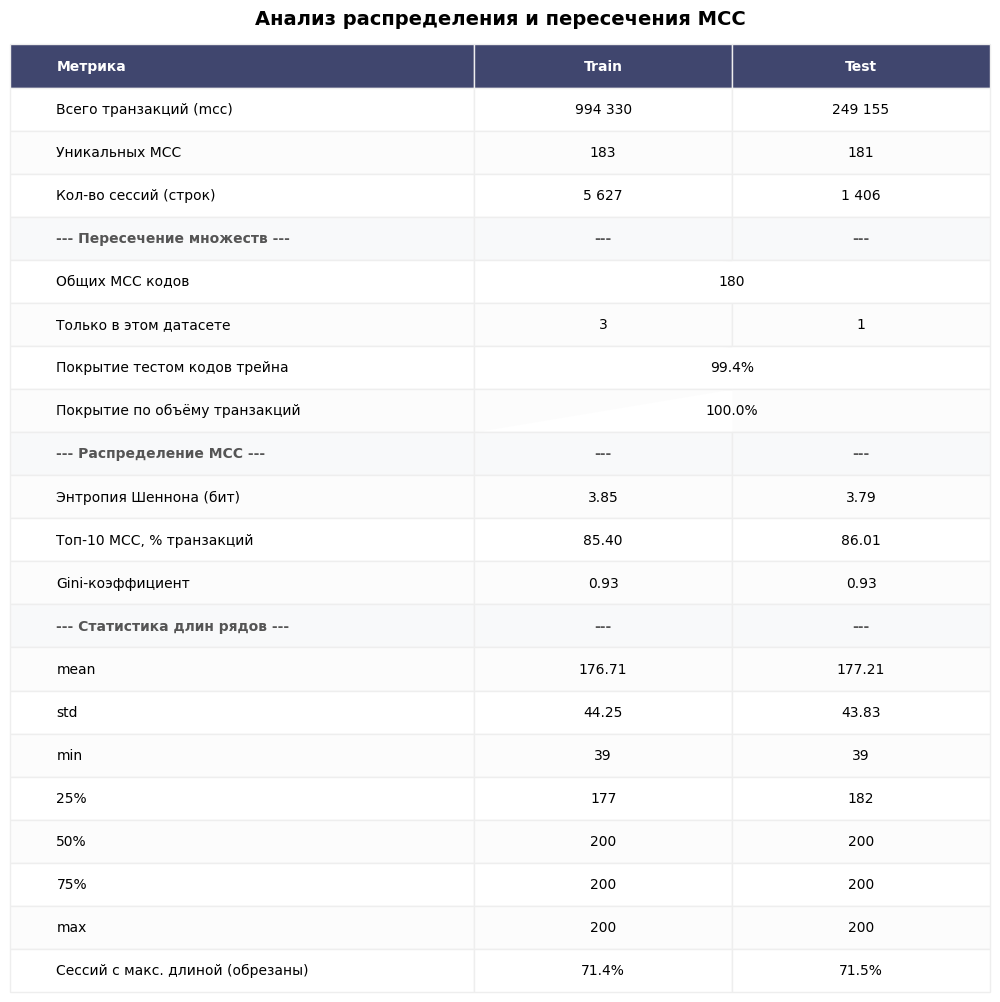

In [ ]:
plot_mcc_comprehensive_summary(train_df, test_df)

**Инсайты по распределению MCC кодов**

- **Стабильное разбиение (~80/20)**  
  Train содержит около 994 тыс. транзакций (5.6 тыс. сессий), Test — 249 тыс. (1.4 тыс. сессий).  
  Сдвига по числу объектов или длине сессий между выборками нет.

- **Почти 100% пересечение кодов**  
  Пространство MCC практически идентично (183 уникальных кода в Train, 181 в Test).  
  По объёму транзакций Test почти полностью покрывается кодами Train.

- **Сильная концентрация распределения**  
  - **Энтропия Шеннона ≈ 3.8 бит** при максимуме около 7.5 бит — распределение MCC далеко от равномерного.  
  - **Коэффициент Джини ≈ 0.93** — очень высокая неравномерность, несколько кодов доминируют, остальные — длинный хвост.  
  - **Топ‑10 MCC дают более 85% транзакций** — поведение почти полностью задаётся узким набором категорий. <br><br>

- **Жесткий лимит длины сессии — 200**  
  Медиана, 75‑й перцентиль и максимум в обеих выборках равны 200 транзакциям.

- **Более 71% сессий обрезаны**  
  Значительная часть последовательностей упирается в технический порог 200 и не помещается в окно целиком.


**Что это значит для модели**

- **Отсутствие сильного domain shift**  
  Модель почти не сталкивается с принципиально новыми MCC‑категориями в Test, а по объёму транзакций выборки очень похожи.  
  Это благоприятно для обобщающей способности и снижает риск «катастрофического» деградации на индустриальных данных.

- **Перекос в пользу топ‑MCC**  
  ТGini ≈ 0.93 и энтропия ≈ 3.8 бит показывают, что модель будет отлично учиться на топ‑10 кодах, но **качество на редких MCC будет основным источником ошибок**.  
  Бейзлайн на основе глобального Top‑K может быть очень сильным, а прирост от персонализации важнее, чем усложнение архитектуры.

- **Усечённый контекст из‑за лимита 200**  
  Более 71% сессий обрезаны, то есть модель видит не полную историю, а фрагмент последовательности.  
  Если задача чувствительна к дальнему контексту (например, редкие, но важные события в начале сессии), текущий лимит длины может существенно ограничивать качество.

Далее для более репрезентативного анализа распределения длин историй и частотности MCC-кодов мы объединили признаки "Data" из `train` и `test` выборок. Это позволяет собрать максимально полный словарь транзакций (item vocabulary) без утечки целевой переменной.

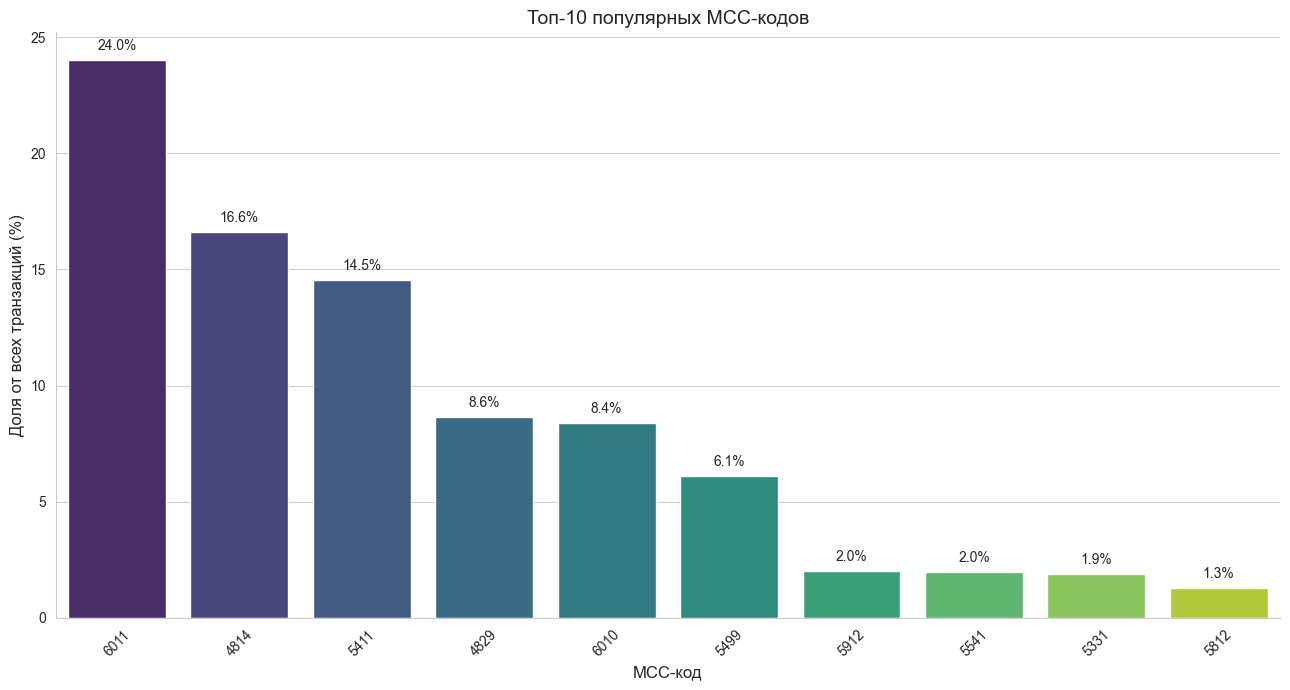

In [ ]:
plot_mcc_distribution(train_df, test_df)

**Инсайты по распределению MCC-кодов**

- **6011 — 24.0%**: снятие наличных. Это главный драйвер частоты и сильный базовый паттерн поведения.
- **4814 — 16.6%**: телекоммуникации. Тоже регулярная бытовая транзакция.
- **5411 — 14.5%**: супермаркеты. Самая частая потребительская категория.
- **Топ-3 кода дают более 55% всех транзакций**, поэтому распределение сильно перекошено.
- **С 4-го места начинается длинный хвост**: остальные MCC встречаются заметно реже, часто на уровне 1–8%.

**Что это значит для модели**

- **Глобальный Top-K baseline будет сильным**.
- **Персонализация важнее, чем сложность модели**.
- **Редкие MCC-коды** будут основным источником ошибок и хорошим полем для анализа качества.

В рамках EDA мы **не анализируем глобальное распределение Target**, чтобы избежать **Data Leakage**.

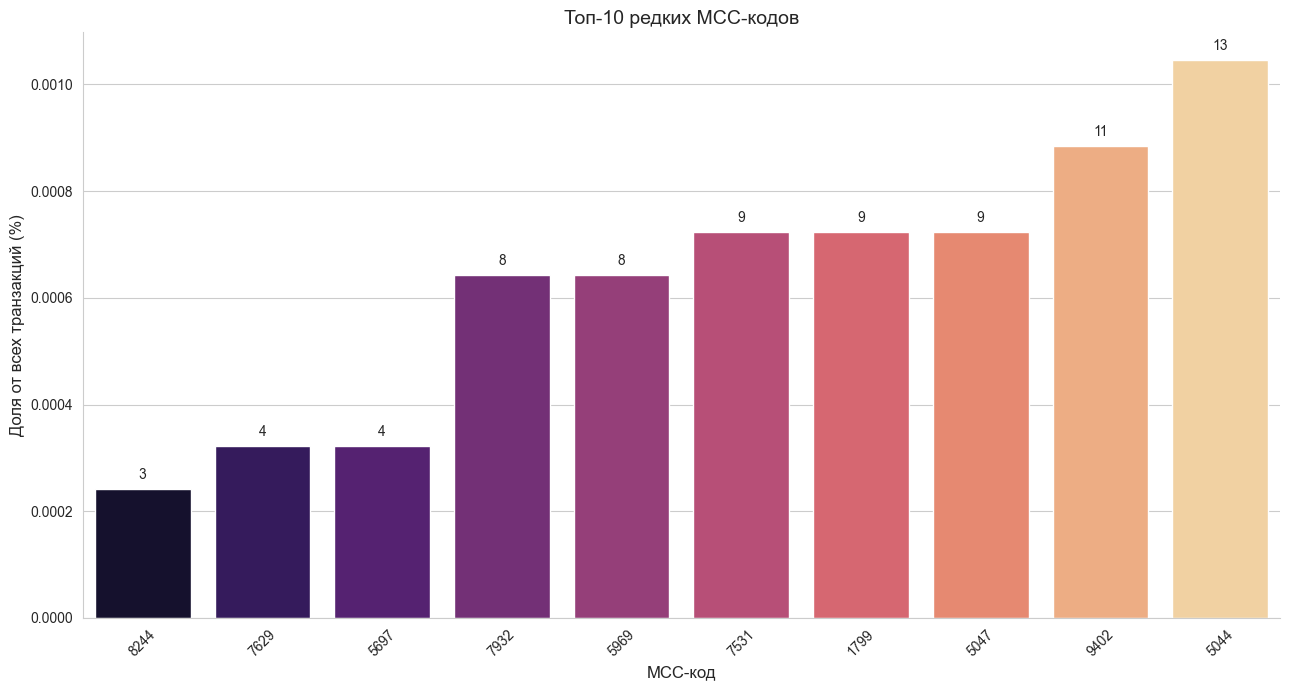

In [ ]:
plot_mcc_distribution(train_df, test_df, ascending=True)

После анализа распределения MCC‑кодов и длин сессий естественно перейти к изучению Target, чтобы понять, какое поведение ожидать от клиента в следующих слотах последовательности.

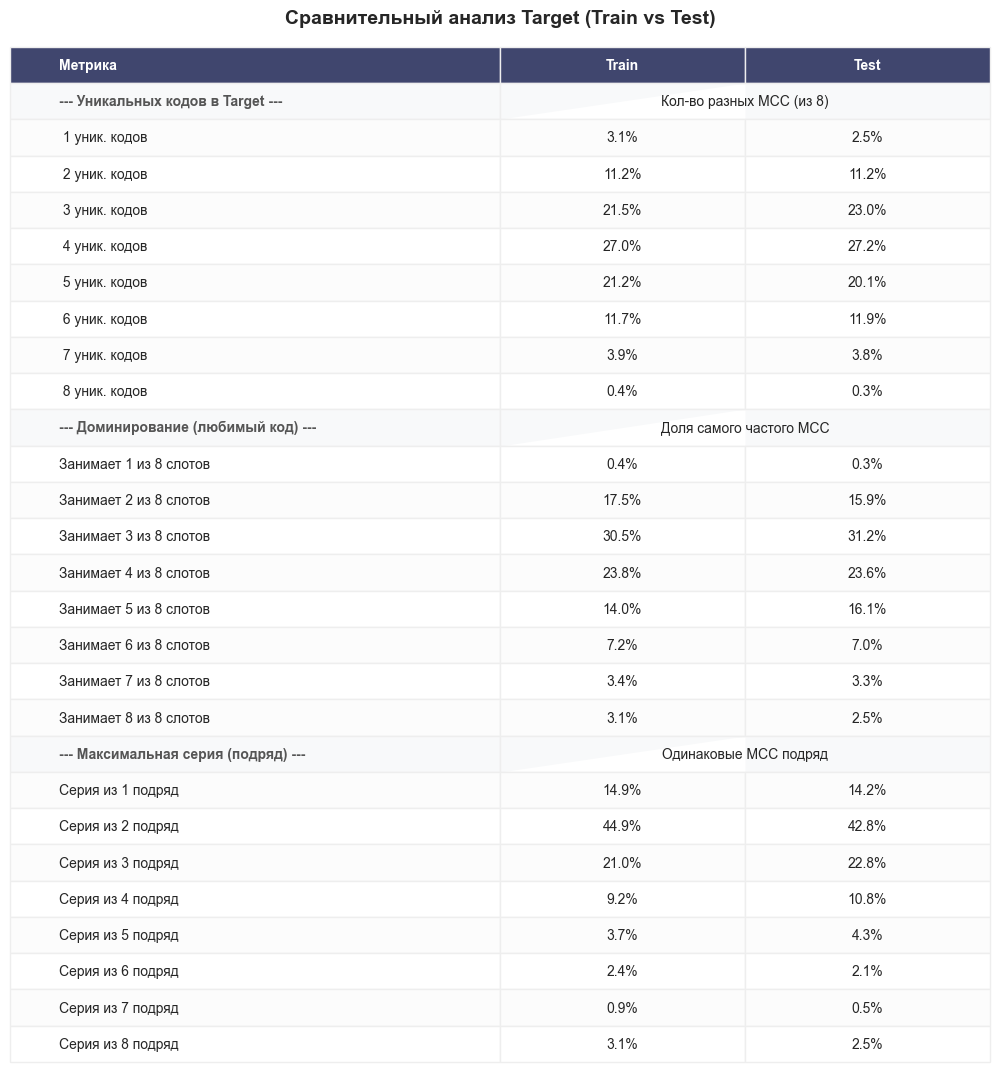

In [ ]:
plot_target_comprehensive_summary(train_df, test_df)

**Инсайты по структуре целевых последовательностей**

- **3–5 уникальных кодов из 8 — ~70% случаев**: пик разнообразия приходится на 4 уникальных MCC (27.0% в Train). Поведение клиентов вариативно, но в основном ограничено пулом привычных категорий.

- **Доминирующий код забирает 3–4 слота — 54.3% случаев**: почти всегда в целевом окне есть "любимая" якорная категория, на которую уходит около половины всех прогнозируемых транзакций.

- **Серии из 2 одинаковых транзакций подряд — 44.9%**: это абсолютный лидер среди сценариев повторяющихся покупок. Длинные "залипания" в одном MCC (от 5 транзакций подряд) происходят довольно редко.

- **Идеальное совпадение Train и Test*: распределения метрик в обучающей и тестовой выборках практически идентичны, отклонения составляют доли процента. Это говорит о высоком качестве сплита.

**Что это значит для модели**

- **Баланс разнообразия и приоритетов**. Модель должна формировать выдачу из 3–5 разных кодов, обязательно отдавая основной вес 1–2 "любимым" MCC конкретного пользователя.

- **Предсказание "дублей" — норма**. Поскольку парные серии одинаковых кодов встречаются в 45% случаев, алгоритм должен уметь предсказывать повторение только что совершенной транзакции.

- **Валидация будет надежной**. Отсутствие структурного сдвига (drift) между трейном и тестом гарантирует, что модель, обученная на этих паттернах, не просядет по качеству на отложенной выборке.

**Следующие шаги и ограничения**

Поскольку длинные серии из одного MCC встречаются нечасто, клиенты постоянно переключаются между разными категориями. Чтобы понять логику этой смены паттернов и углубить анализ, следующим этапом нужно посмотреть матрицу переходов (transition matrix) — какие MCC-коды чаще всего следуют друг за другом и какие транзакции выступают триггерами для смены категории. Вероятно, нам понадобится и группировка самых редких кодов.

In [ ]:
df_train_grouped = group_rare_mccs(train_df, threshold=0.95)

Уникальных MCC кодов: 183 → 33


In [ ]:
df_test_grouped = group_rare_mccs(test_df, threshold=0.95)

Уникальных MCC кодов: 181 → 31


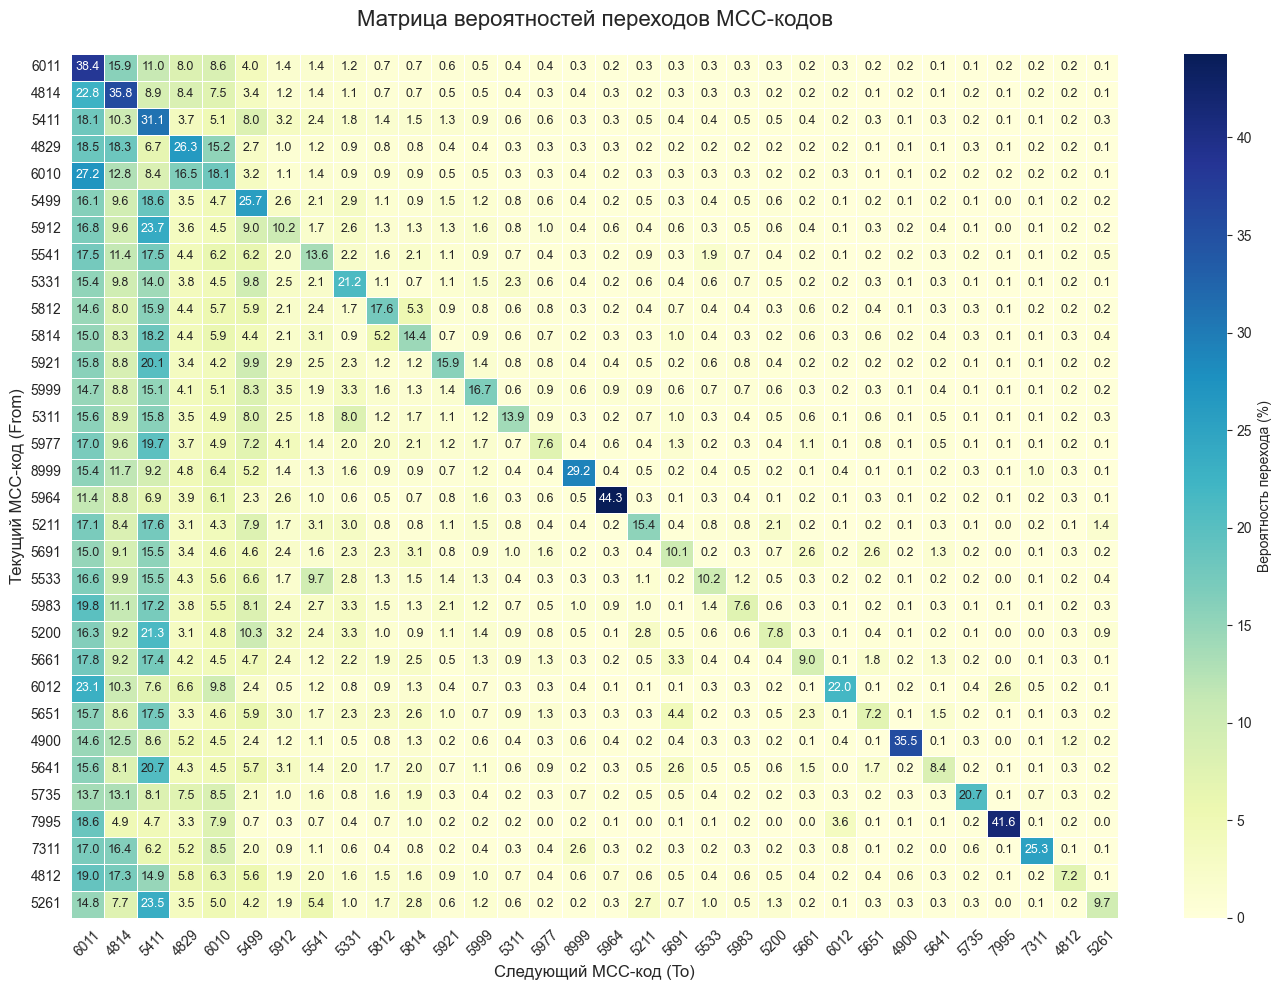

In [ ]:
plot_mcc_transition_matrix(
    df_train=train_df,
    df_test=test_df,
    top_n=32,
    compress_repeats=False
)

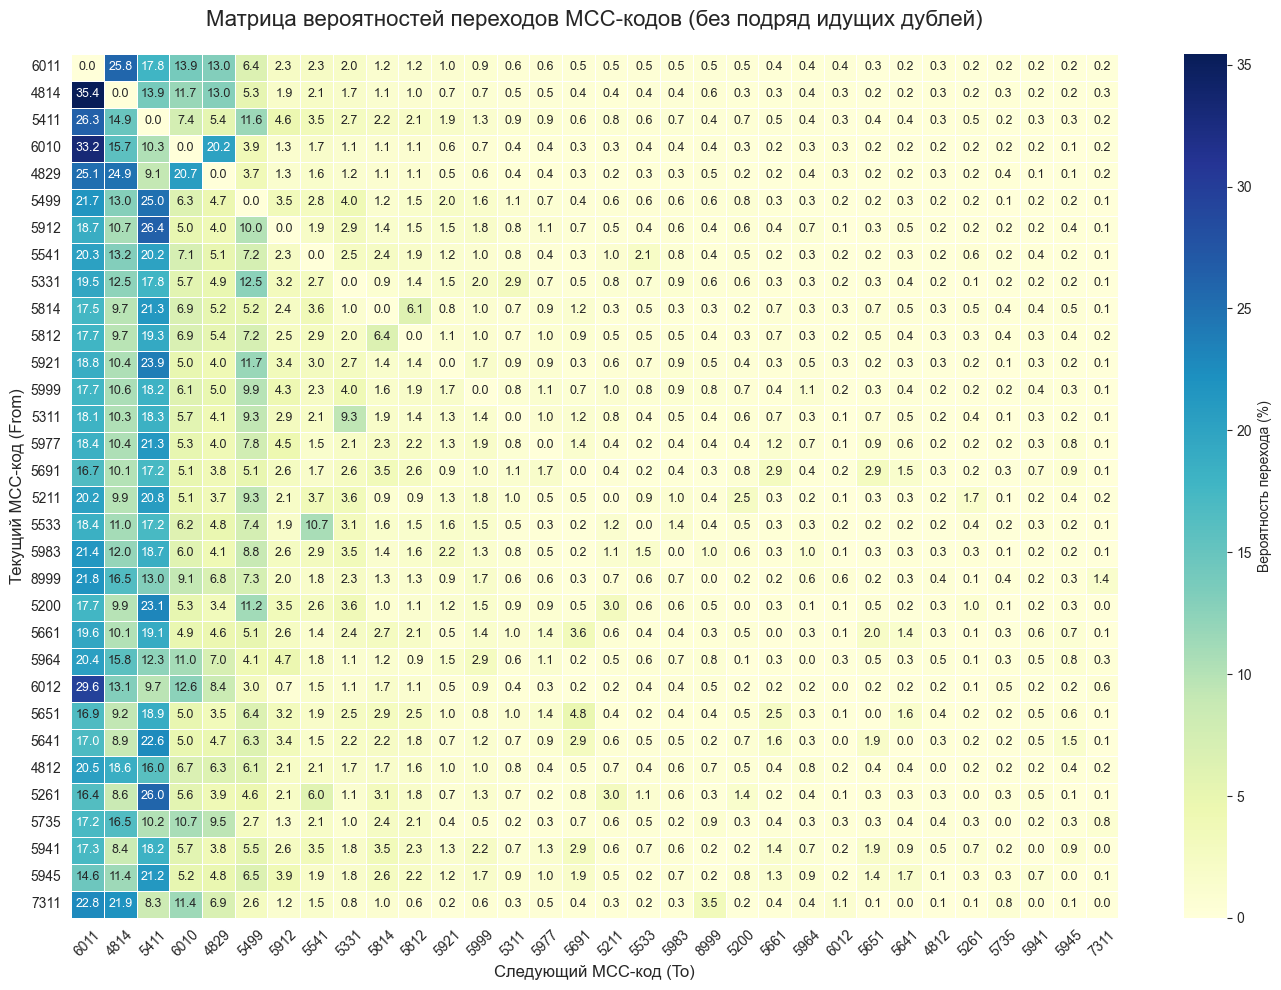

In [ ]:
plot_mcc_transition_matrix(
    df_train=train_df,
    df_test=test_df,
    top_n=32,
    compress_repeats=True
)

А теперь с учетом группировки редких mcc кодов:

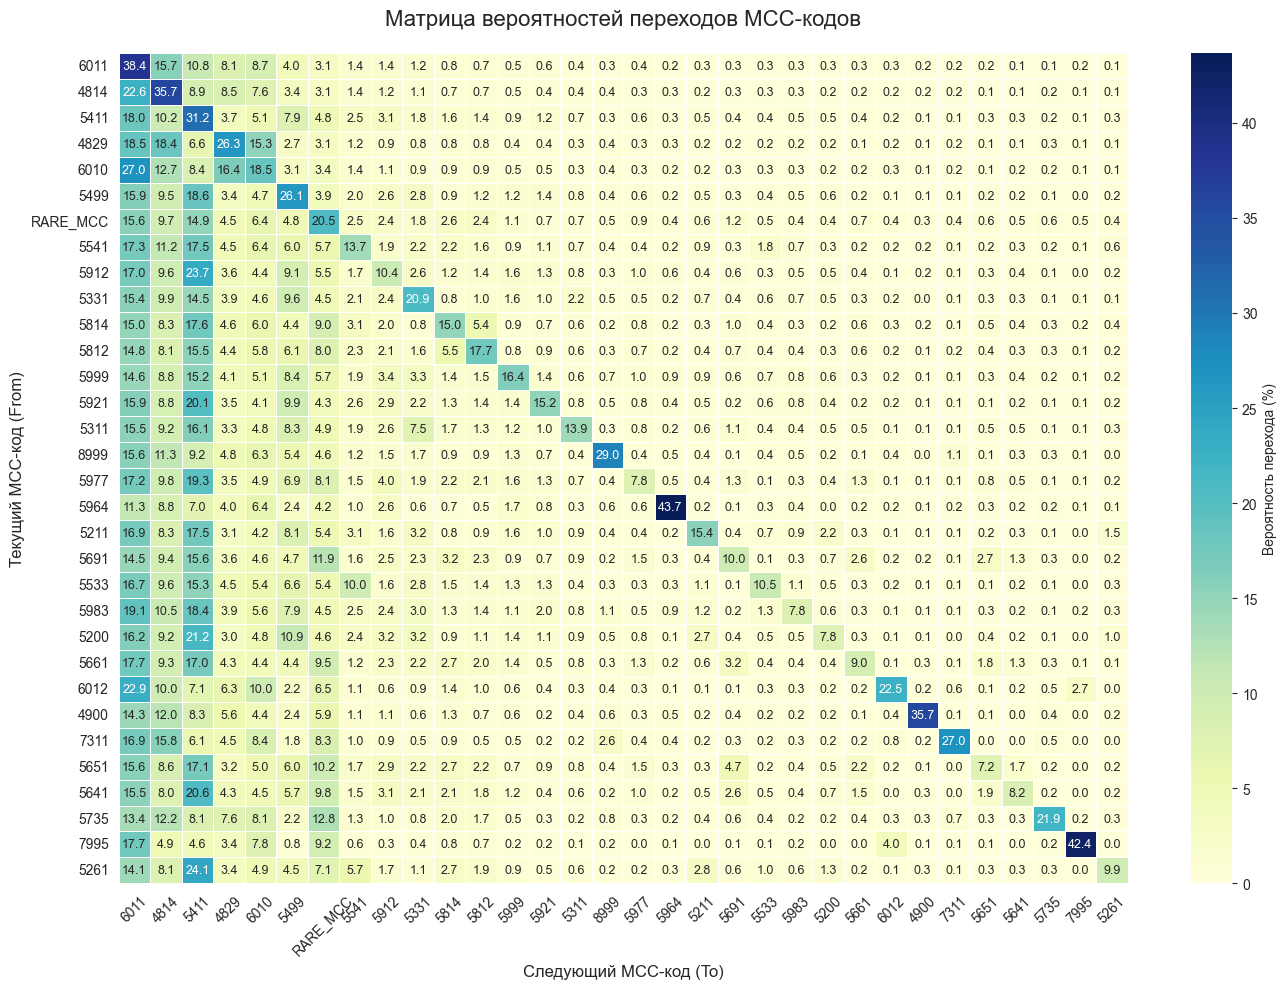

In [ ]:
plot_mcc_transition_matrix(
    df_train=df_train_grouped,
    df_test=df_train_grouped,
    top_n=32,
    compress_repeats=False
)

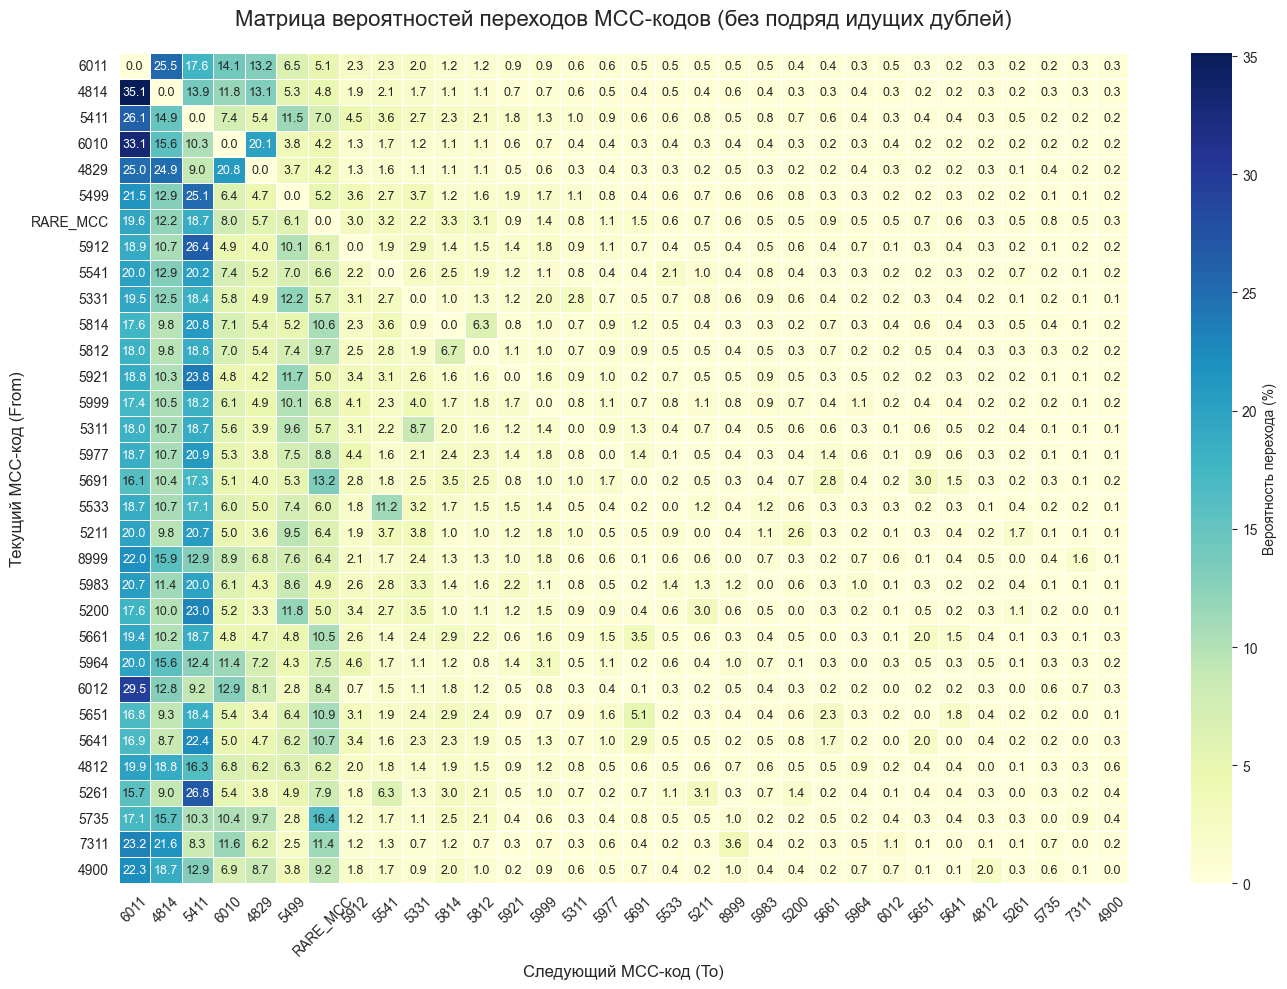

In [ ]:
plot_mcc_transition_matrix(
    df_train=df_train_grouped,
    df_test=df_train_grouped,
    top_n=32,
    compress_repeats=True
)

**Переход к кластерному анализу переходов между MCC**

Матрица фиксирует лишь марковские зависимости первого порядка — изолированные вероятности перехода $P(MCC_{t} | MCC_{t-1})$. В таком виде данные представляют собой зашумленную разреженную таблицу, где глобальные многошаговые паттерны и нелинейные связи теряются на фоне множества слабых транзакционных шумов.

Переход к сетевому анализу позволяет сместить фокус с попарных транзакций на выявление системной архитектуры поведения. Графовые метрики извлекают структурные признаки, которые напрямую повышают качество предиктивных моделей:

- **Кластеризация как выявление мета-состояний**: В отличие от матрицы, алгоритмы выделения сообществ (например, Louvain или Leiden) группируют MCC-коды в плотно связанные кластеры. Это позволяет моделировать поведение не просто как угадывание "следующего магазина", а как прогнозирование смены поведенческого контекста (например, переход из кластера "повседневная рутина" в "ремонт" или "путешествие"). Принадлежность к кластеру становится мощным предиктором будущих трат.
  
- **Выявление поведенческих хабов**: Метрики центральности (Degree, Betweenness Centrality) определяют узловые MCC-коды, выступающие "мостами" между разными сферами жизни клиента. Эти узлы служат ключевыми триггерами, после которых вероятность смены поведенческого паттерна максимальна.

**Архитектура сетевой модели**:
Анализ проводится на сжатых транзакционных траекториях (с удалением подряд идущих дубликатов $A \to A \to A$ для исключения ложных петель).

- **Узлы (Вершины)**: Уникальные MCC-коды. Размер узла пропорционален глобальной частотности транзакций.

- **Связи (Рёбра)**: Взвешенные направленные дуги. Толщина (вес) ребра отражает статистическую значимость перехода.

- **Оптимизация признакового пространства**: Агрегация "длинного хвоста" (нижние 5% частотности) в единый узел RARE_MCC. Это снижает размерность графа до главных высокоуровневых кластеров, отсекая шум и сохраняя значимую дисперсию данных.

/var/folders/1d/y_x173w12h10kj15r6w71z4w0000gn/T/ipykernel_3457/3443211540.py:44: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kolobrovskiy/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


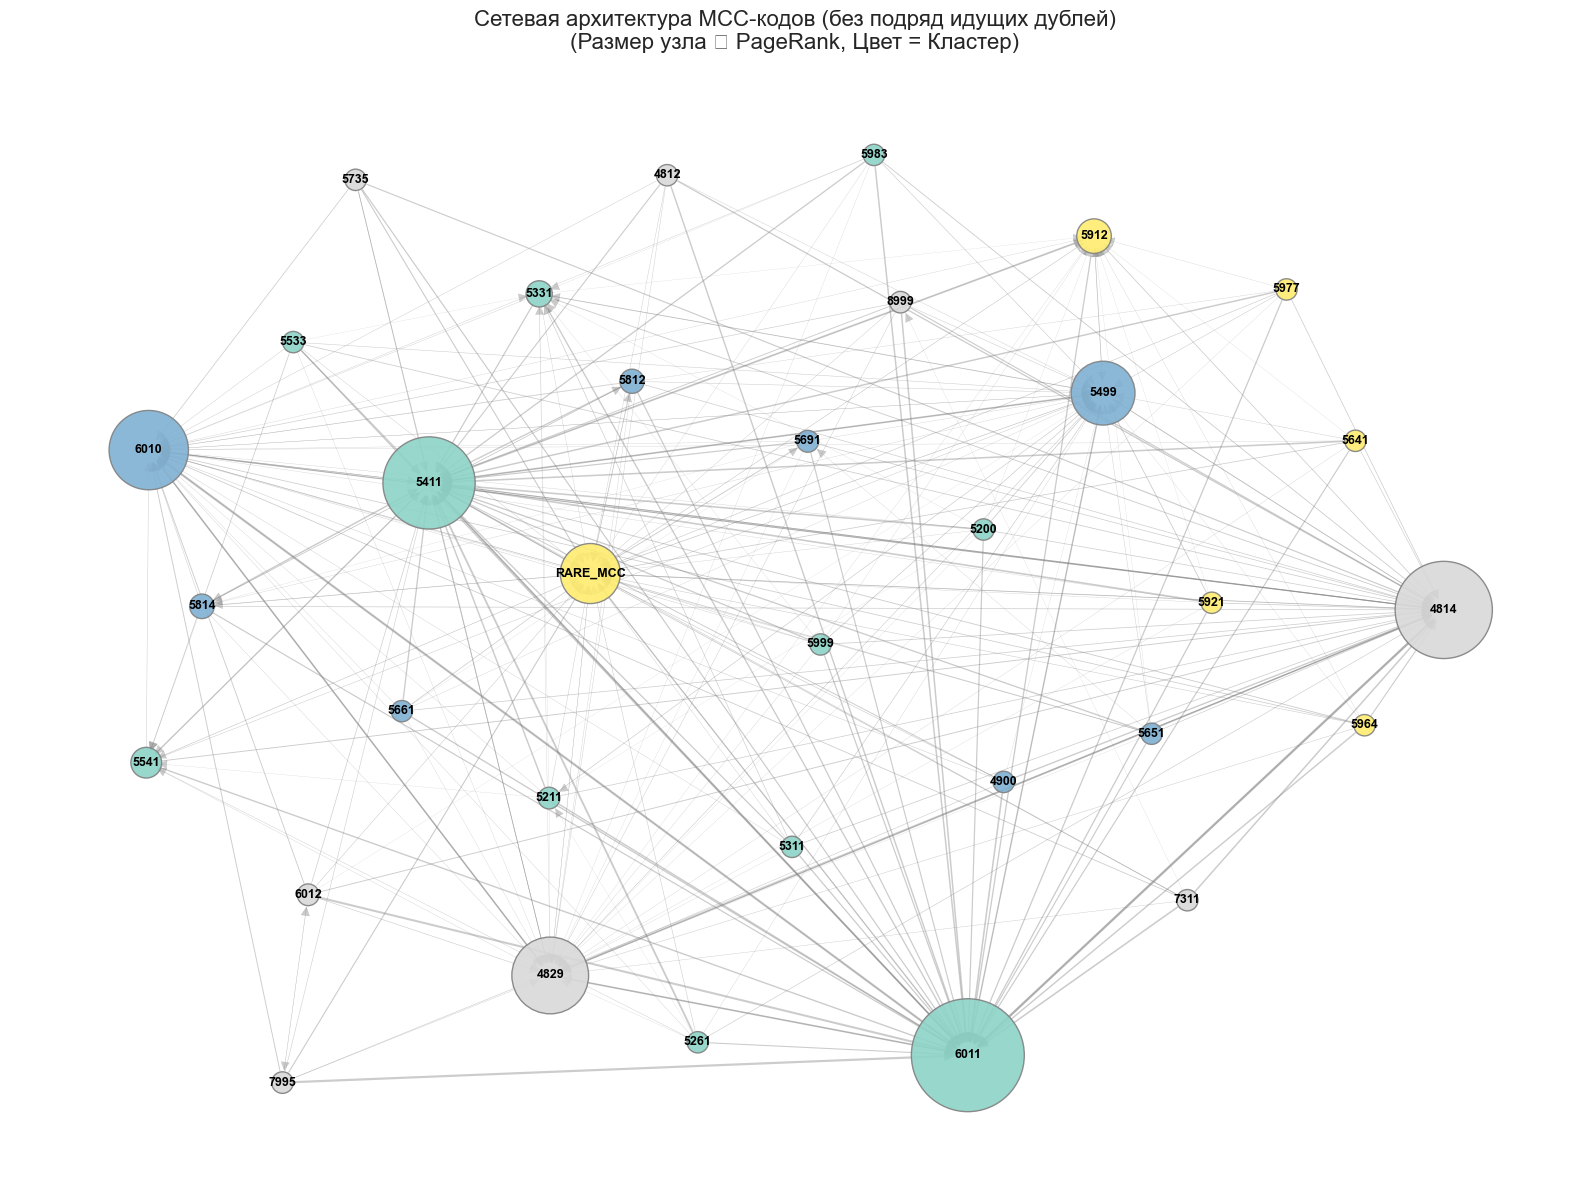

In [ ]:
full_features = get_mcc_network_features(
    df_train=df_train_grouped,
    df_test=df_test_grouped,
    col_name='Data',
    compress_repeats=True,
    min_edge_weight=0.01
)

plot_mcc_network(df_train_grouped, df_test_grouped)

**Инсайты по структуре сети MCC-кодов**

- **Сеть очень плотная и почти полностью связанная**: на графе нет выраженных изолированных компонент, а большинство кодов соединены множеством слабых связей. Это указывает на то, что переходы между категориями происходят часто и не ограничиваются узким набором пар.

- **Выделяются 3 основных кластера (зоны притяжения)**:  
  - кластер 0 — `4814`, `4829`, `5912`, `5812`, `5814`, `5541`, `8999`;  
  - кластер 1 — `5411`, `6010`, `5331`, `5533`, `5999`, `5983`, `5211`;  
  - кластер 2 — `6011`, `5499`, `5311`, `5691`, `5977`, `RARE_MCC`.
    
  Между кластерами наблюдается большое число связей, поэтому они не изолированы и формируют общую связанную структуру.

- **Абсолютный центр сети — `6011`**: максимальный `PageRank = 0.195454` при `InDegree = 1.00000` и минимальном `Betweenness = 0.001017`. Код выступает как глобальный «якорь», но не как посредник между разными зонами.

- **Второй уровень центральных MCC-кодов**:  
  `4814 (0.141721)`, `5411 (0.135847)`, `6010 (0.092517)`, `4829 (0.085523)`, `5499 (0.063531)` по PageRank.  
  Это структурные опоры сети, вокруг которых формируются основные траектории.

- **`5411` — ключевой якорный код повседневных сценариев**: сочетает высокий `PageRank`, максимальный `InDegree` и ненулевой `Betweenness`, что делает его устойчивой точкой входа и выхода между сценариями.

- **Главный брокер сети — `5541`**: максимальный `Betweenness = 0.175747` при сравнительно низком `PageRank`. Это типичный транзитный MCC, соединяющий разные кластеры поведения.

- **Существуют «скрытые посредники» с низким PageRank, но высокой посреднической ролью**:  
  `5533`, `5983`, `5999`, `8999`, `5691`, `5211`, `7311`.  
  Они редко доминируют количественно, но часто участвуют в смене паттернов.

- **Кластер 2 наиболее значим структурно**: именно в нём находится `6011`, а также `5499` и `RARE_MCC`, которые усиливают связность между ядром и периферией.

- **`RARE_MCC` — не шумовая категория**: `PageRank = 0.055577`, `Betweenness = 0.067789`. Редкие MCC-коды участвуют в переходах между сценариями и поддерживают целостность сети.

- **Коды с высоким `InDegree`, но низким `Betweenness`** (`4814`, `4829`, `6010`, `6011`) чаще выступают как конечные или целевые состояния, а не как транзитные узлы.

- **Коды с повышенным `OutDegree`** (`5691`, `5311`, `5661`, `5983`, `5651`, `5533`, `5999`) работают как точки расхождения траекторий и инициируют переключения между категориями.

- **Периферийные MCC-коды** (`4900`, `5735`, `7995`, `5964`) имеют минимальные значения PageRank и Betweenness и практически не влияют на глобальную топологию сети.

**Что это значит для интерпретации поведения**

- **Поведение пользователей структурировано вокруг ограниченного числа «любимых» MCC** (`6011`, `5411`, `4814`, `6010`, `4829`, `5499`), а не распределено равномерно по категориям.

- **Клиенты регулярно переключаются между сценариями**: высокая плотность сети и наличие сильных брокеров указывают на частые переходы между разными типами расходов.

- **Редкие MCC-коды критичны для моделирования последовательностей**: их роль в переходах делает опасным простое объединение или удаление без анализа.

### Baseline модели

#### Функции метрик

##### Positional Accuracy

In [6]:
def positional_accuracy(preds, targets):
    correct = (preds == targets).float()
    return correct.mean().item()

##### Positional MRR

In [5]:
# Правильная логика для MRR на конкретном шаге (i)
# logits: [Batch, Num_Classes], targets: [Batch]
def positional_mrr_correct(logits, targets):
    _, sorted_idx = torch.sort(logits, descending=True, dim=1)
    # Ищем индекс (ранг) правильного класса в отсортированном списке
    ranks = (sorted_idx == targets.view(-1, 1)).nonzero()[:, 1]
    return (1.0 / (ranks.float() + 1.0)).mean().item()


##### NDCG@8

In [4]:
import torch

def positional_mrr(logits_step, targets_step):
    # logits_step: [Batch, Num_Classes], targets_step: [Batch]
    # Находим индексы отсортированных логитов (от большего к меньшему)
    _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)

    # Ищем, на каком месте (ранге) находится правильный таргет
    # ranks будет тензором с индексами от 0 до Num_Classes-1
    ranks = (sorted_idx == targets_step.view(-1, 1)).nonzero()[:, 1]

    # Формула MRR: 1 / (rank + 1)
    rr = 1.0 / (ranks.float() + 1.0)
    return rr.mean().item()


def ndcg_k_positional(logits_step, targets_step, k=8):
    # logits_step: [Batch, Num_Classes], targets_step: [Batch]
    device = logits_step.device
    batch_size = logits_step.size(0)

    # Берем топ-К предсказаний из логитов
    _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)
    top_k_idx = sorted_idx[:, :k]

    # Проверяем, есть ли таргет в топ-К
    match_mask = (top_k_idx == targets_step.view(-1, 1))
    found_in_top_k = match_mask.any(dim=1)

    # Получаем ранг внутри этого топ-К (0, 1, ..., k-1)
    # Нам нужны только те, кто реально нашелся
    ranks_in_top_k = match_mask.nonzero()[:, 1]

    ndcg_scores = torch.zeros(batch_size, device=device)
    # Формула из твоего кода: 1 / log2(rank + 2)
    # Т.к. ранг 0 дает log2(2)=1, ранг 1 дает log2(3) и т.д.
    ndcg_scores[found_in_top_k] = 1.0 / torch.log2(ranks_in_top_k.float() + 2.0)

    return ndcg_scores.mean().item()


##### Recall@8

In [7]:
from collections import Counter

def recall_k_as_in_report(preds, targets):
    # preds: [N, 8], targets: [N, 8]
    batch_size = preds.size(0)
    num_steps = preds.size(1) # обычно 8

    batch_recalls = []
    for i in range(batch_size):
        # Логика "Двух мешков" (multisets)
        pred_bag = Counter(preds[i].tolist())
        target_bag = Counter(targets[i].tolist())

        # Пересечение (& выбирает минимальное кол-во вхождений)
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())

        # Делим на общее кол-во позиций (8)
        batch_recalls.append(matches / float(num_steps))

    return sum(batch_recalls) / batch_size


#### Подготовка данных

In [13]:
import pandas as pd
import numpy as np
import torch
from typing import List, Optional

def parse_sequence_columns(
    df: pd.DataFrame,
    columns: Optional[List[str]] = None,
    sep: str = ',',
    max_len: int = 8
) -> pd.DataFrame:
    if columns is None:
        columns = ['Data', 'Target']

    df_processed = df.copy()

    for col in columns:
        if col in df_processed.columns:
            def pad_or_trim(x):
                # Разбиваем строку и фильтруем пустые
                nums = [int(i) for i in str(x).split(sep) if i.strip() != '']
                # Приводим строго к длине max_len
                if len(nums) >= max_len:
                    return nums[:max_len]
                else:
                    return nums + [0] * (max_len - len(nums)) # Добиваем нулями

            df_processed[col] = df_processed[col].apply(pad_or_trim)

    return df_processed

# 1. Загрузка
test_df = pd.read_csv("df_test.csv", sep=';')
train_df = pd.read_csv("df_train.csv", sep=';')

# 2. Парсинг с приведением к длине 8
train_df = parse_sequence_columns(train_df, max_len=8)
test_df  = parse_sequence_columns(test_df, max_len=8)

# 3. Объединение
df = pd.concat([train_df, test_df]).reset_index(drop=True)

# 4. Преобразование (теперь ошибки не будет)
data_array = np.stack(df['Data'].values)
target_array = np.stack(df['Target'].values)

data_tensor = torch.tensor(data_array, dtype=torch.long, device='cuda')
targets = torch.tensor(target_array, dtype=torch.long, device='cuda')

print(f"Готово! Форма тензоров: {targets.shape}")






Готово! Форма тензоров: torch.Size([7033, 8])


#### Ход анализа

##### Следующий токен - это самый популярный элемент во всём датасете

Во время анализа данных мы пришли к тому, что почти четверть от всех используемых mcc-кодов составляет код 6011. Поэтому предположим, что все следующие 8 значений в прогнозируемом векторе будут равны 6011. Это даст нам начальный baseline

In [18]:
import torch
import numpy as np
from collections import Counter

# --- 1. ТВОИ ВЕРНЫЕ МЕТРИКИ (из первого отчета) ---

def run_metrics_as_in_report(f_preds, f_targets, f_logits):
    num_steps = 8

    # 2. РАСЧЕТ NON-POSITIONAL RECALL@8 (Логика "Двух мешков")
    batch_recalls = []
    for i in range(len(f_targets)):
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())
        batch_recalls.append(matches / float(num_steps))
    non_positional_recall = np.mean(batch_recalls)

    # 3. РАСЧЕТ POSITIONAL МЕТРИК И NDCG
    pos_acc, pos_mrr, step_ndcg = [], [], []

    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        logits_step = f_logits[:, i, :]

        # Accuracy
        pos_acc.append((y_pred == y_true).float().mean().item())

        # MRR
        _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)
        ranks = (sorted_idx == y_true.view(-1, 1)).nonzero()[:, 1]
        pos_mrr.append((1.0 / (ranks.float() + 1.0)).mean().item())

        # NDCG@8 (на конкретном шаге i)
        top8_idx = sorted_idx[:, :8]
        match_mask = (top8_idx == y_true.view(-1, 1))
        found_in_top8 = match_mask.any(dim=1)
        rank_in_top8 = match_mask.nonzero()[:, 1]

        ndcg_scores = torch.zeros(len(y_true))
        ndcg_scores[found_in_top8] = 1.0 / torch.log2(rank_in_top8.float() + 2.0)
        step_ndcg.append(ndcg_scores.mean().item())

    return {
        "Recall@8": non_positional_recall,
        "Accuracy": np.mean(pos_acc),
        "MRR": np.mean(pos_mrr),
        "NDCG": np.mean(step_ndcg)
    }

# --- 2. ПОДГОТОВКА ДАННЫХ ДЛЯ ТЕСТА ---

# Создаем фейковые логиты для константного предсказания
# Допустим, макс. id класса = 8000
num_classes = 10000
f_logits = torch.zeros((len(targets), 8, num_classes), device='cuda')
f_logits[:, :, 6011] = 10.0  # Делаем MCC 6011 самым вероятным везде

# Предсказания (argmax от логитов)
f_preds = torch.argmax(f_logits, dim=-1)

# --- 3. ЗАПУСК ---

results = run_metrics_as_in_report(f_preds.cpu(), targets.cpu(), f_logits.cpu())

print(f"{' ИТОГОВЫЙ ОТЧЕТ (КОНСТАНТА 6011) ':=^50}")
print(f"Non-Positional Recall@8: {results['Recall@8']:.4f}")
print(f"Mean NDCG@8:              {results['NDCG']:.4f}")
print(f"Mean Positional Accuracy: {results['Accuracy']:.4f}")
print(f"Mean Positional MRR:      {results['MRR']:.4f}")
print(f"{'='*50}")


======== ИТОГОВЫЙ ОТЧЕТ (КОНСТАНТА 6011) =========
Non-Positional Recall@8: 0.2586
Mean NDCG@8:              0.2586
Mean Positional Accuracy: 0.2586
Mean Positional MRR:      0.2589


##### Следующий токен - это mcc-код на услугу, которая была оказана пользователю последней

Ещё один момент, на который мы обратили внимание в анализе датасета: у пользователей существует явная тенденция повторять категорию покупки (на матрицах переходов есть отчётливая диагональ). Поэтому преполагаем, что вероятность того, что предсказанная последовательность будет содержать элементы, равные последнему mcc-коду на услугу, которая была оказана пользователю.

In [19]:
import torch
import numpy as np
from collections import Counter

# --- 1. ТВОИ ОРИГИНАЛЬНЫЕ МЕТРИКИ (из первого сообщения) ---
def get_original_metrics(f_preds, f_targets, f_logits):
    num_steps = 8

    # Non-Positional Recall@8 (Логика "Двух мешков")
    batch_recalls = []
    for i in range(len(f_targets)):
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())
        batch_recalls.append(matches / float(num_steps))
    non_positional_recall = np.mean(batch_recalls)

    # Positional Метрики (Accuracy, MRR, NDCG)
    pos_acc, pos_mrr, step_ndcg = [], [], []
    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        logits_step = f_logits[:, i, :]

        pos_acc.append((y_pred == y_true).float().mean().item())

        _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)
        ranks = (sorted_idx == y_true.view(-1, 1)).nonzero()[:, 1]
        pos_mrr.append((1.0 / (ranks.float() + 1.0)).mean().item())

        top8_idx = sorted_idx[:, :8]
        match_mask = (top8_idx == y_true.view(-1, 1))
        found_in_top8 = match_mask.any(dim=1)
        rank_in_top8 = match_mask.nonzero()[:, 1]
        ndcg_scores = torch.zeros(len(y_true))
        ndcg_scores[found_in_top8] = 1.0 / torch.log2(rank_in_top8.float() + 2.0)
        step_ndcg.append(ndcg_scores.mean().item())

    return {
        "Recall@8": non_positional_recall,
        "Accuracy": np.mean(pos_acc),
        "MRR": np.mean(pos_mrr),
        "NDCG": np.mean(step_ndcg)
    }

# --- 2. ПОДГОТОВКА ПРЕДСКАЗАНИЙ (Last MCC) ---
# Берем последний MCC из истории для каждой строки
last_mcc = df.Data.apply(lambda x: x[-1]).values
preds_array = np.array([ [val]*8 for val in last_mcc ])

# Чтобы MRR/NDCG работали, создаем матрицу логитов
# Находим максимальный ID MCC, чтобы задать размерность
max_mcc = max(df.Data.apply(max).max(), df.Target.apply(max).max()) + 1
f_logits = torch.zeros((len(preds_array), 8, max_mcc), device='cuda')

# Заполняем логиты: для предсказанного MCC ставим высокий балл
for i, val in enumerate(last_mcc):
    f_logits[i, :, val] = 10.0

f_preds = torch.tensor(preds_array, device='cuda')
f_targets = targets # Берем из предыдущих шагов [N, 8]

# --- 3. РАСЧЕТ И ВЫВОД ---
res = get_original_metrics(f_preds.cpu(), f_targets.cpu(), f_logits.cpu())

print('Прогноз: вектор из последнего MCC в истории пользователя')
print(f"{'='*50}")
print(f"Non-Positional Recall@8: {res['Recall@8']:.4f}")
print(f"Mean Positional Accuracy: {res['Accuracy']:.4f}")
print(f"Mean Positional MRR:      {res['MRR']:.4f}")
print(f"Mean NDCG@8:              {res['NDCG']:.4f}")
print(f"{'='*50}")


Прогноз: вектор из последнего MCC в истории пользователя
Non-Positional Recall@8: 0.2294
Mean Positional Accuracy: 0.2294
Mean Positional MRR:      0.2305
Mean NDCG@8:              0.2294


##### Марковская цепь n-го порядка

Идея марковской цепи n-го порядка заключается в том, что будущее состояние системы зависит не только от текущего момента, но и от фиксированной цепочки из n предыдущих событий

In [22]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

# --- 1. ОПРЕДЕЛЕНИЕ МОДЕЛИ ---
class MarkovModel():
    def __init__(self, train_data, n=1):
        self.data = train_data
        self.n = n
        self.lookup = {}
        self.fallback = None

    def fit(self):
        n = self.n
        counts = defaultdict(lambda: defaultdict(int))

        for seq in self.data:
            if len(seq) <= n:
                continue
            for i in range(len(seq) - n):
                context = tuple(seq[i:i + n])
                target = seq[i + n]
                counts[context][target] += 1

        global_counts = defaultdict(int)
        for context, targets in counts.items():
            best_target = max(targets, key=targets.get)
            self.lookup[context] = best_target
            for t, c in targets.items():
                global_counts[t] += c

        if global_counts:
            self.fallback = max(global_counts, key=global_counts.get)
        return self.lookup

    def predict(self, data_series):
        inputs = data_series.values
        n = self.n
        all_preds = np.empty((len(inputs), 8), dtype=int)
        lookup = self.lookup
        fallback = self.fallback

        for i, seq in enumerate(inputs):
            if len(seq) >= n:
                current = list(seq[-n:])
            else:
                current = [seq[-1]] * n

            row_preds = []
            for _ in range(8):
                key = tuple(current)
                next_val = lookup.get(key, fallback)
                row_preds.append(next_val)
                current.pop(0)
                current.append(next_val)
            all_preds[i] = row_preds
        return all_preds

# --- 2. ТВОИ ВЕРНЫЕ МЕТРИКИ (из первого отчета) ---
def get_original_report_metrics(f_preds, f_targets):
    num_steps = 8

    # Non-Positional Recall@8 (Логика "Двух мешков")
    batch_recalls = []
    for i in range(len(f_targets)):
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())
        batch_recalls.append(matches / float(num_steps))
    non_positional_recall = np.mean(batch_recalls)

    # Positional Метрики (Accuracy)
    pos_acc = []
    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        acc = (y_pred == y_true).float().mean().item()
        pos_acc.append(acc)

    mean_acc = np.mean(pos_acc)
    return {
        "Recall": non_positional_recall,
        "Accuracy": mean_acc,
        "MRR": mean_acc,
        "NDCG": mean_acc
    }

# --- 3. ПОДГОТОВКА ДАННЫХ И ЦИКЛ ОЦЕНКИ ---

# Убедимся, что таргеты в правильном формате
targets_np = np.array(df.Target.tolist())
f_targets = torch.tensor(targets_np, dtype=torch.long)

for n in range(1, 6):
    mark_model = MarkovModel(df.Data, n)
    mark_model.fit()

    # Предсказания
    preds_np = mark_model.predict(df.Data)
    f_preds = torch.tensor(preds_np, dtype=torch.long)

    # Расчет
    res = get_original_report_metrics(f_preds, f_targets)

    print('_______________________________________')
    print(f'{n} порядок марковской цепи')
    print()
    print(f'Positional Accuracy: {res["Accuracy"]:.4f}')
    print(f'Recall@8:            {res["Recall"]:.4f} (мешок)')
    print(f'MRR@8:               {res["MRR"]:.4f}')
    print(f'NDCG@8:              {res["NDCG"]:.4f}')


_______________________________________
1 порядок марковской цепи

Positional Accuracy: 0.2606
Recall@8:            0.2608 (мешок)
MRR@8:               0.2606
NDCG@8:              0.2606
_______________________________________
2 порядок марковской цепи

Positional Accuracy: 0.2720
Recall@8:            0.2768 (мешок)
MRR@8:               0.2720
NDCG@8:              0.2720
_______________________________________
3 порядок марковской цепи

Positional Accuracy: 0.2713
Recall@8:            0.2965 (мешок)
MRR@8:               0.2713
NDCG@8:              0.2713
_______________________________________
4 порядок марковской цепи

Positional Accuracy: 0.2675
Recall@8:            0.3275 (мешок)
MRR@8:               0.2675
NDCG@8:              0.2675
_______________________________________
5 порядок марковской цепи

Positional Accuracy: 0.2602
Recall@8:            0.3282 (мешок)
MRR@8:               0.2602
NDCG@8:              0.2602


Recall@8 демонстрирует самый стабильный и впечатляющий рост: с 0.2608 на 1-м порядке до 0.3282 на 5-м. Это значит, что чем больше истории мы учитываем, тем выше шанс, что реальное следующее действие пользователя попадет в наш список рекомендаций.

Positional Accuracy достигает пика на 2-м порядке (0.2720), после чего начинает плавно снижаться.

NDCG@8 также показывает максимум на 2-м порядке (0.2720).
Это сигнализирует, что после 2-го порядка модель начинает понемногу «переобучаться» под специфические длинные последовательности, которые встречаются реже, из-за чего общая точность по массиву данных начинает падать.

##### Марковская цепь n-го порядка с пороговым отсечением низкочастотных переходов

In [23]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

# --- 1. ОПРЕДЕЛЕНИЕ ТВОИХ ВЕРНЫХ МЕТРИК (из первого сообщения) ---
def get_original_report_metrics(f_preds, f_targets):
    num_steps = 8

    # Non-Positional Recall@8 (Логика "Двух мешков")
    batch_recalls = []
    for i in range(len(f_targets)):
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())
        batch_recalls.append(matches / float(num_steps))
    non_positional_recall = np.mean(batch_recalls)

    # Positional Метрики
    # Для моделей без логитов (hard prediction) Acc = MRR = NDCG
    pos_acc = []
    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        acc = (y_pred == y_true).float().mean().item()
        pos_acc.append(acc)

    mean_acc = np.mean(pos_acc)
    return {
        "Recall": non_positional_recall,
        "Accuracy": mean_acc,
        "MRR": mean_acc,
        "NDCG": mean_acc
    }

# --- 2. КЛАСС MARKOVMODEL (с min_count) ---
class MarkovModel():
    def __init__(self, train_data, n=1, min_count=2):
        self.data = train_data
        self.n = n
        self.min_count = min_count
        self.lookup = {}
        self.fallback = None

    def fit(self):
        n = self.n
        counts = defaultdict(lambda: defaultdict(int))
        for seq in self.data:
            if len(seq) <= n: continue
            for i in range(len(seq) - n):
                context = tuple(seq[i:i + n])
                target = seq[i + n]
                counts[context][target] += 1

        global_counts = defaultdict(int)
        for context, targets_counts in counts.items():
            best_target = max(targets_counts, key=targets_counts.get)
            best_count = targets_counts[best_target]
            if best_count >= self.min_count:
                self.lookup[context] = best_target
            for t, c in targets_counts.items():
                global_counts[t] += c

        if global_counts:
            self.fallback = max(global_counts, key=global_counts.get)
        return self.lookup

    def predict(self, data_list):
        inputs = data_list.values
        n = self.n
        all_preds = np.empty((len(inputs), 8), dtype=int)
        lookup = self.lookup
        fallback = self.fallback

        for i, seq in enumerate(inputs):
            if len(seq) >= n:
                current = list(seq[-n:])
            else:
                current = [seq[-1]] * n
            row_preds = []
            for _ in range(8):
                key = tuple(current)
                next_val = lookup.get(key, fallback)
                row_preds.append(next_val)
                current.pop(0)
                current.append(next_val)
            all_preds[i] = row_preds
        return all_preds

# --- 3. ЗАПУСК И ПРОВЕРКА ---

# Подготовка таргетов
targets_np = np.array(df.Target.tolist())
f_targets = torch.tensor(targets_np, dtype=torch.long)

for n in range(1, 6):
    for k in range(10, 30, 2):
        mark_model = MarkovModel(df.Data, n, k)
        mark_model.fit()

        preds_np = mark_model.predict(df.Data)
        f_preds = torch.tensor(preds_np, dtype=torch.long)

        # Считаем твои метрики
        res = get_original_report_metrics(f_preds, f_targets)

        print('_______________________________________')
        print(f'{n} порядок марковской цепи с игнорированием количества переходов < {k}')
        print()
        print(f'Positional Accuracy: {res["Accuracy"]:.4f}')
        print(f'Recall@8:            {res["Recall"]:.4f}')
        print(f'MRR@8:               {res["MRR"]:.4f}')
        print(f'NDCG@8:              {res["NDCG"]:.4f}')


_______________________________________
1 порядок марковской цепи с игнорированием количества переходов < 10

Positional Accuracy: 0.2611
Recall@8:            0.2611
MRR@8:               0.2611
NDCG@8:              0.2611
_______________________________________
1 порядок марковской цепи с игнорированием количества переходов < 12

Positional Accuracy: 0.2613
Recall@8:            0.2613
MRR@8:               0.2613
NDCG@8:              0.2613
_______________________________________
1 порядок марковской цепи с игнорированием количества переходов < 14

Positional Accuracy: 0.2620
Recall@8:            0.2620
MRR@8:               0.2620
NDCG@8:              0.2620
_______________________________________
1 порядок марковской цепи с игнорированием количества переходов < 16

Positional Accuracy: 0.2620
Recall@8:            0.2620
MRR@8:               0.2620
NDCG@8:              0.2620
_______________________________________
1 порядок марковской цепи с игнорированием количества переходов < 18

Po

In [25]:
results_list = []

# Собираем данные
for n in range(1, 6):
    for k in range(10, 30, 2):
        mark_model = MarkovModel(df.Data, n, k)
        mark_model.fit()

        preds_np = mark_model.predict(df.Data)
        f_preds = torch.tensor(preds_np, dtype=torch.long)

        res = get_original_report_metrics(f_preds, f_targets)

        results_list.append({
            'Order (n)': n,
            'Min_Count (k)': k,
            'Recall@8': res['Recall'],
            'Accuracy': res['Accuracy'],
            'MRR@8': res['MRR'],
            'NDCG@8': res['NDCG']
        })

results_df = pd.DataFrame(results_list)

# --- ФОРМИРУЕМ ОТЧЕТ ПО ВСЕМ МЕТРИКАМ ---
print(f"{' ЛУЧШИЕ ПАРАМЕТРЫ ПО ВСЕМ МЕТРИКАМ ':=^60}")

# Функция для красивого вывода строки
def print_best(metric_name, df):
    best_row = df.loc[df[metric_name].idxmax()]
    print(f"{metric_name:15} | Значение: {best_row[metric_name]:.4f} | Параметры: n={int(best_row['Order (n)'])} k={int(best_row['Min_Count (k)'])}")

print_best('Accuracy', results_df)
print_best('Recall@8', results_df)
print_best('MRR@8', results_df)
print_best('NDCG@8', results_df)

print("="*60)
print("\nПолная таблица результатов (отсортирована по порядку n и порогу k):")
display(results_df.style.highlight_max(axis=0, color='lightgreen', subset=['Recall@8', 'Accuracy', 'MRR@8', 'NDCG@8']))


============ ЛУЧШИЕ ПАРАМЕТРЫ ПО ВСЕМ МЕТРИКАМ =============
Accuracy        | Значение: 0.2791 | Параметры: n=3 k=12
Recall@8        | Значение: 0.2863 | Параметры: n=4 k=14
MRR@8           | Значение: 0.2791 | Параметры: n=3 k=12
NDCG@8          | Значение: 0.2791 | Параметры: n=3 k=12

Полная таблица результатов (отсортирована по порядку n и порогу k):


,Order (n),Min_Count (k),Recall@8,Accuracy,MRR@8,NDCG@8
0,1,10,0.261144,0.261144,0.261144,0.261144
1,1,12,0.261304,0.261304,0.261304,0.261304
2,1,14,0.262033,0.262033,0.262033,0.262033
3,1,16,0.261961,0.261961,0.261961,0.261961
4,1,18,0.262104,0.262104,0.262104,0.262104
5,1,20,0.262335,0.262335,0.262335,0.262335
6,1,22,0.262335,0.262335,0.262335,0.262335
7,1,24,0.262335,0.262335,0.262335,0.262335
8,1,26,0.262121,0.262121,0.262121,0.262121
9,1,28,0.262121,0.262121,0.262121,0.262121


Видно что отсечение частотных переходов иногда улучшает качество марковской цепи но не сильно

In [ ]:
%reset # очищает пр-во локальных имён после этого надо запустить 1 ю ячейку

### Catboost

Выбрали потому что это одна из лучших моделей для табличных данных. Адаптирована под категориальные переменные.

Также потому, что поведение клиента — это цепочка зависимых событий, а деревья решений идеально ловят условные паттерны

### Функции

#### Парсинг строк

In [ ]:
import pandas as pd
from typing import List, Optional

def parse_sequence_columns(
    df: pd.DataFrame,
    columns: Optional[List[str]] = None,
    sep: str = ','
) -> pd.DataFrame:
    """
    Преобразует строковые представления последовательностей в списки элементов.

    Функция создает копию датафрейма и разделяет строки в указанных колонках
    по заданному разделителю, превращая их в списки (list). Исходный
    датафрейм не модифицируется (pure function).

    Args:
        df (pd.DataFrame): Исходный датафрейм.
        columns (List[str], optional): Список колонок для преобразования.
            По умолчанию ['Data', 'Target'].
        sep (str): Символ-разделитель. По умолчанию ','.

    Returns:
        pd.DataFrame: Новый датафрейм со столбцами типа list.
    """
    if columns is None:
        columns = ['Data', 'Target']

    df_processed = df.copy()

    for col in columns:
        if col in df_processed.columns:
            # Преобразуем только строковые значения, пропуская NaN
            df_processed[col] = df_processed[col].astype(str).str.split(sep)

    return df_processed

def parse_sequence(val) -> List[str]:
    if isinstance(val, list):
        return [str(v).strip() for v in val if str(v).strip()]
    return [v.strip() for v in str(val).split(',') if v.strip()]

#### Агрегация редких mcc кодов

In [ ]:
class RareMCCGrouper:
    def __init__(self, threshold: float = 0.95):
        self.threshold = threshold
        self.rare_codes: set = set()
        self.unk_token  = '<RARE>'

    def _iter_codes(self, series: pd.Series):
        """Универсально разбирает и строки и списки."""
        for val in series:
            if isinstance(val, list):
                yield from val
            else:
                yield from [c.strip() for c in str(val).split(',') if c.strip()]

    def fit(self, df: pd.DataFrame, col: str = 'Data') -> 'RareMCCGrouper':
        all_codes = pd.Series(list(self._iter_codes(df[col])))
        counts    = all_codes.value_counts(normalize=True).cumsum()
        self.rare_codes = set(counts[counts > self.threshold].index)
        print(f"[RareMCCGrouper] Редких кодов: {len(self.rare_codes)} "
              f"из {all_codes.nunique()} уникальных")
        return self

    def transform(self, df: pd.DataFrame, col: str = 'Data') -> pd.DataFrame:
        df = df.copy()

        def _replace(val):
            if isinstance(val, list):
                codes = val
            else:
                codes = [c.strip() for c in str(val).split(',') if c.strip()]
            replaced = [self.unk_token if c in self.rare_codes else c for c in codes]
            # возвращаем в том же формате что и на входе
            return replaced if isinstance(val, list) else ','.join(replaced)

        df[col] = df[col].apply(_replace)
        return df

    def fit_transform(self, df: pd.DataFrame, col: str = 'Data') -> pd.DataFrame:
        return self.fit(df, col).transform(df, col)

#### Получение сетевых характеристик

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import community
from typing import Optional, List, Any

def _compress_consecutive_repeats(seq: List[Any]) -> List[Any]:
    """
    Схлопывает подряд идущие одинаковые значения:
    [A, A, V, V, V, B] -> [A, V, B]
    """
    if not isinstance(seq, (list, tuple)) or len(seq) == 0:
        return seq

    compressed = [seq[0]]
    for value in seq[1:]:
        if value != compressed[-1]:
            compressed.append(value)

    return compressed

def _build_transition_edgelist(
    df: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = True
) -> pd.DataFrame:
    """
    Извлекает пары переходов и формирует список ребер (Edge List)
    с весами (вероятностями переходов).
    """
    transitions = []

    # Итерируемся только по переданному датафрейму
    for seq in df[col_name].dropna():
        if not isinstance(seq, (list, tuple)):
            continue

        seq_prepared = _compress_consecutive_repeats(seq) if compress_repeats else seq

        if len(seq_prepared) > 1:
            transitions.extend(zip(seq_prepared[:-1], seq_prepared[1:]))

    df_trans = pd.DataFrame(transitions, columns=['From', 'To'])

    # Считаем абсолютные частоты переходов
    edge_counts = df_trans.groupby(['From', 'To']).size().reset_index(name='Count')

    # Считаем сумму исходящих переходов для каждого узла
    out_counts = edge_counts.groupby('From')['Count'].transform('sum')

    # Вес ребра = вероятность перехода P(To | From)
    edge_counts['Weight'] = edge_counts['Count'] / out_counts

    return edge_counts

def get_mcc_network_features(
    df: pd.DataFrame,
    col_name: str = 'Data',
    compress_repeats: bool = True,
    min_edge_weight: float = 0.01
) -> pd.DataFrame:
    """
    Строит направленный граф переходов и вычисляет сетевые метрики для каждого MCC-кода.
    Возвращает DataFrame с фичами для ML-модели.

    :param min_edge_weight: Порог отсечения слабых связей для уменьшения шума (например, < 1%).
    """
    edges_df = _build_transition_edgelist(
        df=df,
        col_name=col_name,
        compress_repeats=compress_repeats
    )

    # Очищаем от случайного шума (редких переходов)
    edges_df = edges_df[edges_df['Weight'] >= min_edge_weight]

    # Создаем направленный граф
    G = nx.from_pandas_edgelist(
        edges_df, source='From', target='To', edge_attr='Weight', create_using=nx.DiGraph()
    )

    # Вычисляем сетевые метрики
    pagerank = nx.pagerank(G, weight='Weight')
    betweenness = nx.betweenness_centrality(G)
    in_degree = nx.in_degree_centrality(G)
    out_degree = nx.out_degree_centrality(G)

    # Выделение сообществ (кластеров) алгоритмом Greedy Modularity
    # Работает стабильнее на ненаправленных графах
    G_undirected = G.to_undirected()
    communities = community.greedy_modularity_communities(G_undirected)

    community_mapping = {}
    for cluster_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_mapping[node] = cluster_id

    # Собираем фичи
    features_list = []
    for node in G.nodes():
        features_list.append({
            'MCC': node,
            'PageRank': pagerank.get(node, 0.0),
            'Betweenness': betweenness.get(node, 0.0),
            'InDegree': in_degree.get(node, 0.0),
            'OutDegree': out_degree.get(node, 0.0),
            'Cluster_ID': community_mapping.get(node, -1)
        })

    df_features = pd.DataFrame(features_list).set_index('MCC')
    return df_features

#### SequenceFeatureExtractor - извлекает признаки для каждой строки

In [ ]:
from collections import Counter
from itertools import groupby
from typing import List, Dict, Any, Tuple
import numpy as np

class SequenceFeatureExtractor:
    """
    Единый центр (Single Source of Truth) для генерации признаков.
    Этот класс инкапсулирует всю логику извлечения фичей из истории MCC-кодов,
    а также автоматически определяет, какие фичи являются числовыми, а какие — категориальными.
    """

    def __init__(self, num_lags=15, num_comp_lags=5, num_tops=5, num_rares=5, local_window_size=0):
        """
        Инициализирует настройки экстрактора. Изменяя эти параметры, можно легко
        увеличивать или уменьшать количество генерируемых фичей без переписывания кода.
        """
        self.num_lags = num_lags                 # Количество сырых лагов (предыдущих покупок)
        self.num_comp_lags = num_comp_lags       # Количество сжатых лагов (логических переходов)
        self.num_tops = num_tops                 # Топ-N самых частых MCC кодов клиента
        self.num_rares = num_rares               # Топ-N самых редких MCC кодов клиента
        self.local_window_size = local_window_size # Размер окна для оценки "текущих" интересов

        # Внутренние списки для автоматической регистрации фичей
        self._cat_features_list = []
        self._num_features_list = []
        self._is_registered = False

    def get_cat_features(self) -> List[str]:
        """Возвращает список всех строковых (категориальных) признаков для CatBoost."""
        if not self._is_registered:
            self._auto_register_features()
        return self._cat_features_list

    def get_num_features(self) -> List[str]:
        """Возвращает список всех числовых признаков."""
        if not self._is_registered:
            self._auto_register_features()
        return self._num_features_list

    def _auto_register_features(self):
        """
        ВНУТРЕННИЙ МЕТОД: Автоматическая интроспекция.
        Пропускает тестовую последовательность через оркестратор (transform_single).
        Анализирует типы возвращаемых значений: строки записывает в категориальные,
        числа (float) — в числовые. Это избавляет от необходимости вести списки вручную.
        """
        dummy_features = self.transform_single(["6011", "5411", "6011"])

        self._cat_features_list = []
        self._num_features_list = []

        for col_name, value in dummy_features.items():
            if isinstance(value, str):
                self._cat_features_list.append(col_name)
            else:
                self._num_features_list.append(col_name)

        self._is_registered = True

    def _compress_history(self, history: List[str]) -> Tuple[List[str], List[int]]:
        """
        ВНУТРЕННИЙ МЕТОД: Run-Length Encoding (RLE) сжатие.
        Превращает цепочку [A, A, A, B, B] в два массива:
        - comp_history: [A, B] (уникальные семантические переходы)
        - streak_counts: [3, 2] (длины серий подряд идущих транзакций)
        Решает проблему дробления платежей.
        """
        if not history:
            return [], []
        comp_data = [(k, sum(1 for _ in g)) for k, g in groupby(history)]
        return [item[0] for item in comp_data], [item[1] for item in comp_data]

    def _extract_lags(self, history: List[str], comp_history: List[str]) -> Dict[str, str]:
        """
        ЭКСТРАКТОР 1: Локальный контекст.
        Извлекает сырые лаги (что человек делал буквально только что) и
        сжатые лаги (какие логические этапы он прошел до этого).
        """
        feats = {}
        # Заполняем сырые лаги
        for i in range(1, self.num_lags + 1):
            feats[f'lag_{i}'] = str(history[-i]) if len(history) >= i else 'None'

        # Заполняем сжатые лаги
        for i in range(1, self.num_comp_lags + 1):
            feats[f'comp_lag_{i}'] = comp_history[-i] if len(comp_history) >= i else 'None'
        return feats

    def _extract_global_aggregations(self, comp_history: List[str]) -> Dict[str, str]:
        """
        ЭКСТРАКТОР 2: Глобальный профиль клиента.
        Ищет любимые магазины (топы) и уникальные триггеры (редкие коды).
        ВАЖНО: Считается по сжатой истории, чтобы 100 переводов (6011) подряд
        не выбили из топа реальные любимые места.
        """
        feats = {}
        comp_counts = Counter(comp_history)
        most_common = comp_counts.most_common(self.num_tops)
        rarest = comp_counts.most_common()[:-self.num_rares-1:-1]

        # Заполняем глобальные топы
        for i in range(self.num_tops):
            feats[f'comp_top_{i+1}_mcc'] = most_common[i][0] if len(most_common) > i else 'None'

        # Заполняем редкие (сигнальные) коды
        for i in range(self.num_rares):
            feats[f'comp_rare_{i+1}_mcc'] = rarest[i][0] if len(rarest) > i else 'None'

        return feats

    def _extract_local_aggregations(self, history: List[str]) -> Dict[str, Any]:
        """
        ЭКСТРАКТОР 3: Локальный (текущий) профиль.
        Анализирует только последние транзакции (например, 15 штук).
        Если клиент внезапно начал делать ремонт, строительный магазин выйдет в
        local_top, даже если глобально его там нет.
        """
        local_window = history[-self.local_window_size:]
        local_counts = Counter(local_window)
        local_top = local_counts.most_common(2)

        return {
            'local_top_1': local_top[0][0] if len(local_top) > 0 else 'None',
            'local_top_2': local_top[1][0] if len(local_top) > 1 else 'None',
            'local_unique_ratio': float(len(local_counts) / len(local_window)) if local_window else 0.0
        }

    def _extract_streaks_and_markov(self, history: List[str], comp_history: List[str], streak_counts: List[int]) -> Dict[str, Any]:
        """
        ЭКСТРАКТОР 4: Аналитика серий и Марковские цепи.
        Вычисляет склонность клиента повторять текущий код (Streak Breaker)
        и определяет, какой код исторически чаще всего следует за текущим.
        """
        current_mcc = history[-1]

        # Анализ истории дублей текущего MCC-кода (без учета текущей незавершенной серии)
        historical_streaks = [c for mcc, c in zip(comp_history[:-1], streak_counts[:-1]) if mcc == current_mcc]

        feats = {
            'current_streak_len': float(streak_counts[-1]), # Сколько раз код УЖЕ повторился
            'mean_streak_for_mcc': float(np.mean(historical_streaks)) if historical_streaks else 1.0,
            'max_streak_for_mcc': float(np.max(historical_streaks)) if historical_streaks else 1.0
        }

        # Марковский переход: какой код идет ПОСЛЕ текущего (по логической сжатой истории)
        next_codes = [comp_history[i+1] for i in range(len(comp_history) - 1) if comp_history[i] == current_mcc]
        feats['usual_next_mcc'] = Counter(next_codes).most_common(1)[0][0] if next_codes else 'None'

        return feats

    def transform_single(self, history: List[str]) -> Dict[str, Any]:
        """
        ГЛАВНЫЙ ОРКЕСТРАТОР: Собирает все признаки воедино.
        Именно эту функцию вызывает код при формировании датасета или инференсе.
        """
        features = {'history_len': float(len(history))}

        if not history:
            # Возвращаем дефолтные значения, если история пуста
            comp_hist, streaks = [], []
        else:
            # Сжимаем историю один раз и передаем во все функции, чтобы не дублировать вычисления
            comp_hist, streaks = self._compress_history(history)

        # 1. Добавляем лаги
        features.update(self._extract_lags(history, comp_hist))
        # 2. Добавляем глобальные топы
        features.update(self._extract_global_aggregations(comp_hist))
        # 3. Добавляем локальные топы
        features.update(self._extract_local_aggregations(history))

        # 4. Добавляем серии и марковские фичи
        if history:
            features.update(self._extract_streaks_and_markov(history, comp_hist, streaks))
        else:
            # Заглушки, если история пуста
            features.update({
                'current_streak_len': 0.0, 'mean_streak_for_mcc': 1.0,
                'max_streak_for_mcc': 1.0, 'usual_next_mcc': 'None'
            })


        return features

#### Создаем авторегрессивным датафрейм

In [ ]:
import pandas as pd

def build_autoregressive_dataset(
    df: pd.DataFrame,
    extractor,
    network_features
) -> pd.DataFrame:
    """
    Разворачивает сырой DataFrame в авторегрессионный датасет.
    Добавляет сетевые характеристики MCC-кода из lag_1.

    :param network_features: DF, где индекс — это MCC код (str),
                             а столбцы — его сетевые характеристики.
    """

    data_lists = df['Data'].values
    target_lists = df['Target'].values
    client_ids = df['Id'].values

    all_rows = []

    # 1. Основной цикл сборки признаков
    for client_id, history_seq, target_seq in zip(client_ids, data_lists, target_lists):
        current_history = list(history_seq) # копия

        for i, target_mcc in enumerate(target_seq):
            step_num = i + 1

            # Извлекаем признаки (включая lag_1)
            features = extractor.transform_single(current_history)

            step_data = {
                'Id': client_id,
                'step_number': step_num,
                **features,
                'target_mcc': target_mcc
            }
            all_rows.append(step_data)

            # Teacher Forcing: добавляем таргет в историю
            current_history.append(target_mcc)

    # 2. Создаем основной DataFrame
    result_df = pd.DataFrame(all_rows)

    # 3. Приклеиваем сетевые характеристики
    if not network_features.empty:

        # Подготовка network_features:
        # Убеждаемся, что MCC — это индекс и он имеет тип str (как и лаги в экстракторе)
        net_df = network_features.copy()
        if 'mcc' in net_df.columns:
            net_df['mcc'] = net_df['mcc'].astype(str)
            net_df.set_index('mcc', inplace=True)
        else:
            net_df.index = net_df.index.astype(str)

        # Добавляем префикс к сетевым столбцам, чтобы не запутаться
        net_df.columns = [f'net_{col}' for col in net_df.columns]

        # Делаем LEFT JOIN: ключ lag_1 из основного DF сопоставляем с индексом net_df
        result_df = result_df.merge(
            net_df,
            left_on='lag_1',
            right_index=True,
            how='left'
        )

    return result_df

#### Класс спецификаций для модели

In [ ]:
from dataclasses import dataclass, field, asdict

@dataclass
class AblationSpec:
    """
    Полное описание одного эксперимента аблации.
    Меняем параметры экстрактора → получаем разные наборы фич.
    """
    name: str

 # ── Параметры экстрактора ─────────────────────────────────
    num_lags:          int = 10
    num_comp_lags:     int = 200
    num_tops:          int = 32
    num_rares:         int = 3
    local_window_size: int = 40

    # ── Параметры модели ──────────────────────────────────────
    iterations:    int   = 2_000
    depth:         int   = 6
    learning_rate: float = 0.05

    # Регуляризация (из твоих старых параметров)
    l2_leaf_reg:       float = 10.0   # L2 по листьям — чем больше, тем меньше переобучение
    max_ctr_complexity: int  = 1      # сложность комбинаций cat-фич: 1 = без комбинаций

    # Железо
    task_type:   str = 'GPU'
    random_seed: int = 14

    # Исключения колонок поверх параметров экстрактора
    drop_feature_groups: List[str] = field(default_factory=list)
    # Возможные значения: 'lags', 'comp_lags', 'tops', 'rares',
    #                     'local', 'streaks', 'network', 'prev_targets'

    def __post_init__(self):
        # Валидация
        assert self.num_lags >= 0
        assert self.num_comp_lags >= 0
        assert self.num_tops >= 0

def get_drop_columns(
    spec: AblationSpec,
    all_columns: List[str],
) -> List[str]:
    """
    По spec.drop_feature_groups возвращает список колонок для исключения.
    Работает с реальными именами колонок датафрейма.
    """
    to_drop = []

    for group in spec.drop_feature_groups:
        if group == 'lags':
            to_drop += [c for c in all_columns if c.startswith('lag_')]
        elif group == 'comp_lags':
            to_drop += [c for c in all_columns if c.startswith('comp_lag_')]
        elif group == 'tops':
            to_drop += [c for c in all_columns if c.startswith('comp_top_')]
        elif group == 'rares':
            to_drop += [c for c in all_columns if c.startswith('comp_rare_')]
        elif group == 'local':
            to_drop += [c for c in all_columns
                        if c in ('local_top_1', 'local_top_2', 'local_unique_ratio')]
        elif group == 'streaks':
            to_drop += [c for c in all_columns
                        if c in ('current_streak_len', 'mean_streak_for_mcc',
                                 'max_streak_for_mcc', 'usual_next_mcc')]
        elif group == 'network':
            to_drop += [c for c in all_columns
                        if c.startswith('net_')]
        elif group == 'prev_targets':
            to_drop += [c for c in all_columns
                        if c.startswith('prev_target_')
                        or c in ('prev_mean', 'prev_std', 'prev_last', 'prev_delta')]

    return list(set(to_drop))  # дедупликация

#### Авторегрессионное предсказание

In [ ]:
def autoregressive_predict(
    model,
    val_df,
    extractor,
    network_features,
    cat_cols: list,
    n_steps=8,
) -> dict:
    """
    Инференс, который возвращает словарь с предсказаниями и логитами
    для корректного расчета NDCG и MRR.
    """
    net_df = network_features.copy()
    if 'mcc' in net_df.columns:
        net_df['mcc'] = net_df['mcc'].astype(str)
        net_df.set_index('mcc', inplace=True)
    else:
        net_df.index = net_df.index.astype(str)
    net_df.columns = [f'net_{col}' for col in net_df.columns]

    train_cols = model.feature_names_
    cat_cols_set = set(cat_cols)

    all_predicted = []
    all_logits = []

    for _, row in val_df.iterrows():
        # Очистка истории
        raw = row['Data']
        if isinstance(raw, list):
            history = [str(m).strip() for m in raw if str(m).strip()]
        else:
            history = [m.strip() for m in str(raw).split(',') if m.strip()]

        step_preds = []
        step_logits = []

        for step in range(1, n_steps + 1):
            features = extractor.transform_single(history)
            features['step_number'] = step

            # Сетевые фичи
            lag_1 = str(features.get('lag_1', ''))
            if lag_1 in net_df.index:
                for net_col, net_val in net_df.loc[lag_1].items():
                    features[net_col] = net_val
            else:
                for net_col in net_df.columns:
                    features[net_col] = None

            # Каст категорий
            for col in cat_cols_set:
                if col in features:
                    val = features[col]
                    features[col] = 'None' if (val is None or pd.isna(val)) else str(val)

            feat_df = pd.DataFrame([features]).reindex(columns=train_cols).fillna('None')

            # Получаем вероятности
            probs = model.predict_proba(feat_df).flatten()
            step_logits.append(probs)

            # Выбираем лучший класс для продолжения
            pred_idx = np.argmax(probs)
            pred_mcc = str(model.classes_[pred_idx])

            step_preds.append(pred_mcc)
            history.append(pred_mcc)

        all_predicted.append(step_preds)
        all_logits.append(step_logits)

    return {
        "preds": all_predicted,
        "logits": np.array(all_logits),
        "classes": model.classes_
    }


#### Оценка качества прогноза

In [ ]:
import numpy as np
import pandas as pd
from typing import List, Dict

# ══════════════════════════════════════════════════════════════════════════
#  Вспомогательные функции (приватные — префикс _)
# ══════════════════════════════════════════════════════════════════════════

def _compute_hit_rate(pred_seq: List[str], true_seq: List[str]) -> float:
    """
    Hit Rate: доля позиций, где модель угадала хотя бы один MCC
    из множества истинных (по позиции ±0).

    Пример: pred=['A','B','C'], true=['A','X','C'] → 2/3 = 0.667
    """
    n = min(len(pred_seq), len(true_seq))
    if n == 0:
        return 0.0
    hits = sum(p == t for p, t in zip(pred_seq[:n], true_seq[:n]))
    return hits / n


def _compute_recall_at_k(pred_seq: List[str], true_seq: List[str]) -> float:
    """
    Recall@K: доля уникальных истинных MCC, которые модель
    предсказала хотя бы на одной позиции (вне зависимости от позиции).

    Пример: pred=['A','B','C'], true=['A','D','C'] → {A,C} нашли из {A,D,C} → 2/3
    """
    if not true_seq:
        return 0.0
    true_set = set(true_seq)
    pred_set = set(pred_seq)
    found = true_set & pred_set
    return len(found) / len(true_set)

def _compute_ndcg_at_k(pred_seq: List[str], true_seq: List[str]) -> float:
    k = min(len(pred_seq), len(true_seq))
    if k == 0:
        return 0.0

    true_set = set(true_seq)

    # Реальный DCG
    dcg = sum(
        1.0 / np.log2(i + 2)
        for i, p in enumerate(pred_seq[:k])
        if p in true_set
    )

    # IDCG: максимум — все K позиций попали (нормируем на K, не на unique)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(k))

    return dcg / idcg if idcg > 0 else 0.0

def _compute_positional_mrr(pred_seq: List[str], true_seq: List[str]) -> float:
    """
    Positional MRR (Mean Reciprocal Rank) — адаптация для последовательностей.

    Для каждой позиции i: если pred[i] совпал с true[i], добавляем 1/(i+1).
    Нормируем на длину последовательности.

    Смысл: высокий MRR → модель угадывает точно И рано.
    """
    n = min(len(pred_seq), len(true_seq))
    if n == 0:
        return 0.0
    score = sum(
        1.0 / (i + 1)
        for i, (p, t) in enumerate(zip(pred_seq[:n], true_seq[:n]))
        if p == t
    )
    return score / n


def _compute_per_step_accuracy(
    all_preds: List[List[str]],
    all_true:  List[List[str]],
    n_steps:   int
) -> Dict[int, float]:
    """
    Per-step Accuracy: точность на каждом шаге предсказания (от 1 до n_steps).

    Нужна для анализа деградации модели — как точность падает
    по мере удаления от истории (накопление ошибок).

    Возвращает словарь {1: 0.42, 2: 0.38, ..., 8: 0.28}.
    """
    step_hits   = {s: 0 for s in range(1, n_steps + 1)}
    step_counts = {s: 0 for s in range(1, n_steps + 1)}

    for pred_seq, true_seq in zip(all_preds, all_true):
        for step in range(1, n_steps + 1):
            idx = step - 1
            if idx < len(pred_seq) and idx < len(true_seq):
                step_counts[step] += 1
                if pred_seq[idx] == true_seq[idx]:
                    step_hits[step] += 1

    return {
        step: (step_hits[step] / step_counts[step] if step_counts[step] > 0 else 0.0)
        for step in range(1, n_steps + 1)
    }


def _compute_coverage(
    all_preds: List[List[str]],
    all_true:  List[List[str]]
) -> float:
    """
    Coverage: доля уникальных MCC из истинных, которые модель вообще
    предсказала хоть раз по всей валидационной выборке.

    Метрика разнообразия — модель не должна предсказывать только
    топ-3 самых частых MCC.
    """
    all_true_flat = {mcc for seq in all_true for mcc in seq}
    all_pred_flat = {mcc for seq in all_preds for mcc in seq}
    if not all_true_flat:
        return 0.0
    return len(all_true_flat & all_pred_flat) / len(all_true_flat)


# ══════════════════════════════════════════════════════════════════════════
#  Оркестратор: считает все метрики разом
# ══════════════════════════════════════════════════════════════════════════

from collections import Counter

def evaluate_model_properly(predict_output, true_sequences):
    preds = predict_output['preds']
    logits = predict_output['logits']
    classes = predict_output['classes']

    n_samples = len(preds)
    n_steps = 8

    pos_acc, pos_mrr, step_ndcg = [], [], []
    class_to_idx = {str(name): i for i, name in enumerate(classes)}

    for s in range(n_steps):
        step_hits, step_mrr_sum, step_ndcg_sum = 0, 0, 0
        for i in range(n_samples):
            true_mcc = str(true_sequences[i][s])

            # Accuracy на конкретном шаге s
            if preds[i][s] == true_mcc:
                step_hits += 1

            # Ранговые метрики через логиты
            if true_mcc in class_to_idx:
                target_idx = class_to_idx[true_mcc]
                probs_step = logits[i, s, :]
                sorted_indices = np.argsort(-probs_step)
                rank = np.where(sorted_indices == target_idx)[0][0]

                step_mrr_sum += 1.0 / (rank + 1.0)
                if rank < 8:
                    step_ndcg_sum += 1.0 / np.log2(rank + 2.0)

        pos_acc.append(step_hits / n_samples)
        pos_mrr.append(step_mrr_sum / n_samples)
        step_ndcg.append(step_ndcg_sum / n_samples)

    return {
        "Mean_NDCG@8":  np.mean(step_ndcg),
        "Mean_Pos_Acc": np.mean(pos_acc),
        "Mean_Pos_MRR": np.mean(pos_mrr),
        "Step_Accuracy": pos_acc
    }


### Ход исследования

#### Импорт

In [ ]:
import pandas as pd

train_path = 'df_train.csv'
test_path = 'df_test.csv'

train_df = pd.read_csv(train_path, delimiter=';')
test_df = pd.read_csv(test_path, delimiter=';')

# Применяем парсинг строк в списки MCC-кодов
train_df = parse_sequence_columns(train_df)
test_df  = parse_sequence_columns(test_df)

#### Формируем локальный тренировочный датафрейм

In [ ]:
from sklearn.model_selection import train_test_split

# ── 1. Разбивка ───────────────────────────────────────────────
train_ids, val_ids = train_test_split(
    train_df['Id'].unique(), test_size=0.2, random_state=14
)
df_loc_train = train_df[train_df['Id'].isin(train_ids)].copy()
df_loc_val   = train_df[train_df['Id'].isin(val_ids)].copy()

# ── 2. Группировка: fit ТОЛЬКО на трейне ──────────────────────
grouper = RareMCCGrouper(threshold=0.95)
grouper.fit(df_loc_train)            # учится на трейне

df_loc_train = grouper.transform(df_loc_train)
df_loc_val   = grouper.transform(df_loc_val)   # те же правила!
# На проде: grouper.transform(test_df)          ← абсолютно то же

# ── 3. Дальше как обычно ──────────────────────────────────────
network_features = get_mcc_network_features(df_loc_train)

[RareMCCGrouper] Редких кодов: 153 из 183 уникальных


#### Определяем варианты наших будущих спецификаций

In [ ]:
specs: List[AblationSpec] = [

    # ── Baseline (твои текущие настройки) ────────────────────────────
    AblationSpec(
        name             = 'baseline',
        num_lags         = 10,
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 3,
        local_window_size = 40,
    ),

    # ── Аблация: убираем num_lags (твоя гипотеза: вредный) ───────────
    AblationSpec(
        name             = 'no_lags',
        num_lags         = 1,       # ← выключаем (lag_1 - текущий)
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 3,
        local_window_size = 40,
    ),

    # ── Аблация: убираем num_rares (твоя гипотеза: незначимый) ───────
    AblationSpec(
        name             = 'no_rares',
        num_lags         = 10,
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 0,       # ← выключаем
        local_window_size = 40,
    ),

    # ── Аблация: оба "незначимых" убраны ─────────────────────────────
    AblationSpec(
        name             = 'no_lags_no_rares',
        num_lags         = 1,
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 0,
        local_window_size = 40,
    ),

    # ── Подбор num_comp_lags ──────────────────────────────────────────
    AblationSpec(
        name             = 'comp_lags_50',
        num_lags         = 1,
        num_comp_lags    = 50,      # ← 50 вместо 200
        num_tops         = 32,
        num_rares        = 0,
        local_window_size = 40,
    ),
    AblationSpec(
        name             = 'comp_lags_100',
        num_lags         = 1,
        num_comp_lags    = 100,
        num_tops         = 32,
        num_rares        = 0,
        local_window_size = 40,
    ),

    # ── Подбор num_tops ───────────────────────────────────────────────
    AblationSpec(
        name             = 'tops_10',
        num_lags         = 1,
        num_comp_lags    = 200,
        num_tops         = 10,      # ← 10 вместо 32
        num_rares        = 0,
        local_window_size = 40,
    ),
    AblationSpec(
        name             = 'tops_20',
        num_lags         = 1,
        num_comp_lags    = 200,
        num_tops         = 20,
        num_rares        = 0,
        local_window_size = 40,
    ),

    # ── Подбор local_window_size ──────────────────────────────────────
    AblationSpec(
        name             = 'window_10',
        num_lags         = 1,
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 0,
        local_window_size = 10,
    ),
    AblationSpec(
        name             = 'window_20',
        num_lags         = 1,
        num_comp_lags    = 200,
        num_tops         = 32,
        num_rares        = 0,
        local_window_size = 20,
    ),

    # ── Аблация блоков фич ────────────────────────────────────────────
    AblationSpec(
        name                 = 'no_network',
        num_lags             = 1,
        num_comp_lags        = 200,
        num_tops             = 32,
        num_rares            = 0,
        local_window_size    = 40,
        drop_feature_groups  = ['network'],   # убираем PageRank и тд
    ),
    AblationSpec(
        name                 = 'no_streaks',
        num_lags             = 1,
        num_comp_lags        = 200,
        num_tops             = 32,
        num_rares            = 0,
        local_window_size    = 40,
        drop_feature_groups  = ['streaks'],   # убираем серии/марков
    ),
    AblationSpec(
        name                 = 'no_prev_targets',
        num_lags             = 1,
        num_comp_lags        = 200,
        num_tops             = 32,
        num_rares            = 0,
        local_window_size    = 40,
        drop_feature_groups  = ['prev_targets'],  # без авторегрессии
    ),

    # ── "Лучший кандидат" по итогам первых прогонов ──────────────────
    # (заполнить вручную после анализа результатов)
    # AblationSpec(name='best_candidate', ...),
]

#### Под каждую спецификацию создаем авторегрессивный датафрейм

In [ ]:
spec_datasets: dict[str, dict] = {}

for spec in specs:

    extractor = SequenceFeatureExtractor(
        num_lags          = spec.num_lags,
        num_comp_lags     = spec.num_comp_lags,
        num_tops          = spec.num_tops,
        num_rares         = spec.num_rares,
        local_window_size = spec.local_window_size,
    )

    train_ds = build_autoregressive_dataset(df_loc_train, extractor, network_features)
    val_ds   = build_autoregressive_dataset(df_loc_val,   extractor, network_features)

    drop_cols = get_drop_columns(spec, train_ds.columns.tolist())
    service   = ['Id', 'target_mcc']

    X_train = train_ds.drop(columns=service + drop_cols, errors='ignore')
    y_train = train_ds['target_mcc']

    X_val   = val_ds.drop(columns=service + drop_cols, errors='ignore')
    y_val   = val_ds['target_mcc']

    # Фильтрация unseen для eval_set — считаем здесь, используем в блоке 3
    known    = set(y_train.unique())
    val_mask = y_val.isin(known)

    cat_cols = extractor.get_cat_features()
    cats     = [c for c in cat_cols if c in X_train.columns]

    spec_datasets[spec.name] = {
        'X_train'   : X_train,
        'y_train'   : y_train,
        'X_val_es'  : X_val[val_mask],   # eval_set — без unseen классов
        'y_val_es'  : y_val[val_mask],
        'cats'      : cats,
        'extractor' : extractor,
    }

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


#### Обучаем модели под каждую спецификацию

In [ ]:
from catboost import CatBoostClassifier
import os, json, pickle, dataclasses

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

spec_models = {}

for spec in specs:
    ds = spec_datasets[spec.name]

    model = CatBoostClassifier(
        iterations            = spec.iterations,
        depth                 = spec.depth,
        learning_rate         = spec.learning_rate,
        l2_leaf_reg           = spec.l2_leaf_reg,
        max_ctr_complexity    = spec.max_ctr_complexity,
        loss_function         = 'MultiClass',
        eval_metric           = 'Accuracy',
        cat_features          = ds['cats'],
        early_stopping_rounds = 50,
        task_type             = 'GPU',           # ← из спеки
        random_seed           = spec.random_seed,
        verbose               = 100,
    )
    model.fit(
        ds['X_train'], ds['y_train'],
        eval_set       = (ds['X_val_es'], ds['y_val_es']),
        use_best_model = True,
    )

    spec_models[spec.name] = model

    # ── Сохранение сразу после обучения ──────────────────────
    safe_name = spec.name.replace(' ', '_').lower()

    model.save_model(f'{MODELS_DIR}/{safe_name}.cbm')

    with open(f'{MODELS_DIR}/{safe_name}_spec.json', 'w') as f:
        json.dump(dataclasses.asdict(spec), f, indent=2, ensure_ascii=False)

    with open(f'{MODELS_DIR}/{safe_name}_extractor.pkl', 'wb') as f:
        pickle.dump(ds['extractor'], f)

    print(f"  ✅ {spec.name} → best_iter={model.best_iteration_}  сохранено в {MODELS_DIR}/{safe_name}.*")

0:	learn: 0.3291768	test: 0.3200044	best: 0.3200044 (0)	total: 1.13s	remaining: 37m 33s
100:	learn: 0.3886359	test: 0.3770965	best: 0.3770965 (100)	total: 1m 22s	remaining: 25m 58s
200:	learn: 0.4014108	test: 0.3793180	best: 0.3794291 (198)	total: 2m 52s	remaining: 25m 42s
bestTest = 0.3796512274
bestIteration = 207
Shrink model to first 208 iterations.
  ✅ baseline → best_iter=207  сохранено в models/baseline.*
0:	learn: 0.3291768	test: 0.3200044	best: 0.3200044 (0)	total: 785ms	remaining: 26m 9s
100:	learn: 0.3893857	test: 0.3765412	best: 0.3765412 (100)	total: 1m 22s	remaining: 25m 44s
200:	learn: 0.4019107	test: 0.3757636	best: 0.3773187 (164)	total: 2m 49s	remaining: 25m 20s
bestTest = 0.3773186716
bestIteration = 164
Shrink model to first 165 iterations.
  ✅ no_lags → best_iter=164  сохранено в models/no_lags.*
0:	learn: 0.3291768	test: 0.3200044	best: 0.3200044 (0)	total: 771ms	remaining: 25m 40s
100:	learn: 0.3886359	test: 0.3770965	best: 0.3770965 (100)	total: 1m 22s	remaining

###Есть вариант с загрузкой чекпоинта(если не нужно грузить то не запускаем)

In [ ]:
!pip install catboost
import shutil
import joblib
import pickle
import dataclasses
from catboost import CatBoostClassifier
from catboost import CatBoostClassifier

# 1. Распаковка
!unzip -o mcc_full_checkpoint.zip -d restored_models/

# 2. Загрузка мета-данных
meta = joblib.load('restored_models/checkpoint_meta.joblib')
network_features = meta['network_features']

# 3. Восстановление словарей моделей и данных
spec_models = {}
spec_datasets = {}

for spec_name, info in meta['spec_info'].items():
    safe_name = spec_name.replace(' ', '_').lower()

    # Загружаем модель
    model = CatBoostClassifier()
    model.load_model(f'restored_models/{safe_name}.cbm')
    spec_models[spec_name] = model

    # Загружаем экстрактор
    with open(f'restored_models/{safe_name}_extractor.pkl', 'rb') as f:
        extractor = pickle.load(f)

    # Восстанавливаем структуру для инференса
    spec_datasets[spec_name] = {
        'extractor': extractor,
        'cats': info['cats']
    }

print("🚀 Все модели и настройки восстановлены! Можно запускать spec_predictions.")


Archive:  mcc_full_checkpoint.zip
  inflating: restored_models/no_network_spec.json  
  inflating: restored_models/comp_lags_50_extractor.pkl  
  inflating: restored_models/tops_20_extractor.pkl  
  inflating: restored_models/checkpoint_meta.joblib  
  inflating: restored_models/no_prev_targets.cbm  
  inflating: restored_models/window_20.cbm  
  inflating: restored_models/comp_lags_50_spec.json  
  inflating: restored_models/comp_lags_100_spec.json  
  inflating: restored_models/tops_20_spec.json  
  inflating: restored_models/no_network_extractor.pkl  
  inflating: restored_models/no_streaks.cbm  
  inflating: restored_models/no_streaks_extractor.pkl  
  inflating: restored_models/no_prev_targets_extractor.pkl  
  inflating: restored_models/window_20_extractor.pkl  
  inflating: restored_models/no_lags_no_rares.cbm  
  inflating: restored_models/no_lags_no_rares_extractor.pkl  
  inflating: restored_models/no_lags.cbm  
  inflating: restored_models/baseline.cbm  
  inflating: restore

#### Оцениваем эффективность каждой модели по выделенным нами метрикам

In [ ]:
spec_predictions: dict[str, dict] = {}

for spec in specs:
    print(f"🔮 Запуск инференса для эксперимента: {spec.name}")

    # Извлекаем компоненты, подготовленные на этапе формирования датасетов
    current_model = spec_models[spec.name]
    current_ds = spec_datasets[spec.name]

    spec_predictions[spec.name] = autoregressive_predict(
        model            = current_model,
        val_df           = df_loc_val, # Используем исходный DF с последовательностями
        extractor        = current_ds['extractor'],
        network_features = network_features,
        cat_cols         = current_ds['cats'],
        n_steps          = 8
    )


🔮 Запуск инференса для эксперимента: baseline
🔮 Запуск инференса для эксперимента: no_lags
🔮 Запуск инференса для эксперимента: no_rares
🔮 Запуск инференса для эксперимента: no_lags_no_rares
🔮 Запуск инференса для эксперимента: comp_lags_50
🔮 Запуск инференса для эксперимента: comp_lags_100
🔮 Запуск инференса для эксперимента: tops_10
🔮 Запуск инференса для эксперимента: tops_20
🔮 Запуск инференса для эксперимента: window_10
🔮 Запуск инференса для эксперимента: window_20
🔮 Запуск инференса для эксперимента: no_network
🔮 Запуск инференса для эксперимента: no_streaks
🔮 Запуск инференса для эксперимента: no_prev_targets


Функция которая сохраняет чекпоинт на PC(работает в гугл коллаб)

In [ ]:
import joblib
import shutil
import os
from google.colab import files


checkpoint_meta = {
    'network_features': network_features,
    'spec_info': {
        spec.name: {
            'cats': spec_datasets[spec.name]['cats'],
            'spec_dict': dataclasses.asdict(spec)
        } for spec in specs
    }
}


meta_path = os.path.join(MODELS_DIR, 'checkpoint_meta.joblib')
joblib.dump(checkpoint_meta, meta_path)

checkpoint_name = 'mcc_full_checkpoint'
shutil.make_archive(checkpoint_name, 'zip', MODELS_DIR)

print(f"✅ Чекпоинт {checkpoint_name}.zip сформирован!")

# 3. Скачиваем файл на компьютер
files.download(f'{checkpoint_name}.zip')


✅ Чекпоинт mcc_full_checkpoint.zip сформирован!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Оценка качества предсказаний

In [ ]:
all_results = []

for spec in specs:
    predict_output = spec_predictions[spec.name]
    metrics = evaluate_model_properly(predict_output, all_true)

    # Собираем данные в плоский словарь для одной строки таблицы
    row = {
        'Experiment': spec.name,
        'NDCG@8':     round(metrics['Mean_NDCG@8'], 4),
        'Mean_Acc':   round(metrics['Mean_Pos_Acc'], 4),
        'MRR':        round(metrics['Mean_Pos_MRR'], 4)
    }

    # Разворачиваем список Step_Accuracy в колонки Step_1, Step_2...
    for i, step_acc in enumerate(metrics['Step_Accuracy']):
        row[f'S{i+1}_Acc'] = round(step_acc, 4)

    all_results.append(row)

# Создаем DF и выводим его
results_df = pd.DataFrame(all_results).sort_values('NDCG@8', ascending=False)

# Сбрасываем индекс для красоты и выводим
display(results_df.reset_index(drop=True))


,Experiment,NDCG@8,Mean_Acc,MRR,S1_Acc,S2_Acc,S3_Acc,S4_Acc,S5_Acc,S6_Acc,S7_Acc,S8_Acc
0,no_network,0.6025,0.3545,0.5322,0.3668,0.3428,0.3659,0.3712,0.3615,0.3446,0.3410,0.3419
1,no_rares,0.6013,0.3531,0.5316,0.3703,0.3561,0.3606,0.3517,0.3472,0.3472,0.3570,0.3348
2,baseline,0.6013,0.3531,0.5316,0.3703,0.3561,0.3606,0.3517,0.3472,0.3472,0.3570,0.3348
3,no_streaks,0.6010,0.3474,0.5291,0.3490,0.3401,0.3606,0.3552,0.3490,0.3455,0.3464,0.3330
4,tops_10,0.6009,0.3500,0.5300,0.3686,0.3517,0.3615,0.3508,0.3490,0.3419,0.3455,0.3313
5,tops_20,0.6009,0.3500,0.5300,0.3686,0.3517,0.3615,0.3508,0.3490,0.3419,0.3455,0.3313
6,comp_lags_100,0.6008,0.3527,0.5308,0.3650,0.3570,0.3615,0.3535,0.3561,0.3428,0.3526,0.3330
7,comp_lags_50,0.6004,0.3542,0.5307,0.3677,0.3579,0.3659,0.3552,0.3597,0.3428,0.3526,0.3321
8,no_lags,0.5999,0.3518,0.5296,0.3650,0.3535,0.3606,0.3561,0.3552,0.3446,0.3481,0.3313
9,no_lags_no_rares,0.5999,0.3518,0.5296,0.3650,0.3535,0.3606,0.3561,0.3552,0.3446,0.3481,0.3313


#### Обучаем на всем трейне и предсказываем тест

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Блок 6: Финальное обучение на train+val → предсказание теста
# ══════════════════════════════════════════════════════════════════════════

from catboost import CatBoostClassifier, Pool
import pickle, json, dataclasses

# ── 1. Выбираем лучшую спецификацию ───────────────────────────────────────
# По результатам аблации: no_network лучший по NDCG@8
BEST_SPEC_NAME = 'no_network'
best_spec = next(s for s in specs if s.name == BEST_SPEC_NAME)
print(f"✅ Лучшая спецификация: '{best_spec.name}'")
print(f"   num_lags={best_spec.num_lags}, num_comp_lags={best_spec.num_comp_lags}")
print(f"   num_tops={best_spec.num_tops}, local_window_size={best_spec.local_window_size}")
print(f"   drop_feature_groups={best_spec.drop_feature_groups}")

# ── 2. Пересчитываем граф на полных данных ─────────────────────────────────
# Граф строился только по df_loc_train — теперь учитываем всех клиентов
# Но для no_network граф не нужен — передаём пустой DataFrame
network_features_full = pd.DataFrame()   # для no_network
# Если хочешь baseline с сетью:
# network_features_full = get_mcc_network_features(train_df)

print(f"✅ Граф: {'пустой (no_network)' if network_features_full.empty else 'построен'}")

# ── 4. Создаём экстрактор и строим финальный датасет ──────────────────────
final_extractor = SequenceFeatureExtractor(
    num_lags=best_spec.num_lags,
    num_comp_lags=best_spec.num_comp_lags,
    num_tops=best_spec.num_tops,
    num_rares=best_spec.num_rares,
    local_window_size=best_spec.local_window_size,
)

# Авторегрессивный датасет из ВСЕГО трейна (train+val)
train_ds_full = build_autoregressive_dataset(
    train_df, final_extractor, network_features_full
)
print(f"✅ Финальный датасет: {len(train_ds_full)} строк "
      f"× {len(train_ds_full.columns)} колонок")

✅ Лучшая спецификация: 'no_network'
   num_lags=1, num_comp_lags=200
   num_tops=32, local_window_size=40
   drop_feature_groups=['network']
✅ Граф: пустой (no_network)
✅ Финальный датасет: 45016 строк × 244 колонок


In [ ]:
# ── 5. Готовим X, y, cat_features ─────────────────────────────────────────
SERVICE_COLS = ['Id', 'target_mcc']

# Дропаем группы признаков согласно лучшей спецификации
drop_cols = get_drop_columns(best_spec, train_ds_full.columns.tolist())
print(f"   Дропаем {len(drop_cols)} колонок: {drop_cols[:5]}...")

X_final = train_ds_full.drop(columns=SERVICE_COLS + drop_cols, errors='ignore')
y_final = train_ds_full['target_mcc']

# Cat-фичи — только те, что остались после дропа
cat_cols_all = final_extractor.get_cat_features()
cat_cols_final = [c for c in cat_cols_all if c in X_final.columns]

print(f"✅ X_final: {X_final.shape}")
print(f"   Категориальных признаков: {len(cat_cols_final)}")
print(f"   Классов: {y_final.nunique()}")

   Дропаем 0 колонок: []...
✅ X_final: (45016, 242)
   Категориальных признаков: 236
   Классов: 156


In [ ]:
# ── 6. Финальное обучение (без early stopping — нет eval set) ──────────────

final_model = CatBoostClassifier(
    iterations=300,
    depth=best_spec.depth,             # 6
    learning_rate=best_spec.learning_rate,   # 0.05
    l2_leaf_reg=best_spec.l2_leaf_reg,       # 10.0
    max_ctr_complexity=best_spec.max_ctr_complexity,  # 1
    loss_function='MultiClass',
    eval_metric='Accuracy',
    cat_features=cat_cols_final,
    task_type='GPU',
    random_seed=best_spec.random_seed, # 14
    verbose=100,
)

final_model.fit(X_final, y_final)

print(f"\n✅ Финальная модель обучена: {final_model.tree_count_} деревьев")

0:	learn: 0.2616847	total: 924ms	remaining: 4m 36s
100:	learn: 0.3743114	total: 1m 24s	remaining: 2m 46s
200:	learn: 0.3881731	total: 2m 59s	remaining: 1m 28s
299:	learn: 0.3971699	total: 4m 34s	remaining: 0us

✅ Финальная модель обучена: 300 деревьев


In [ ]:
def evaluate_model_properly(predict_output, true_sequences):
    preds = predict_output['preds']
    logits = predict_output['logits']
    classes = predict_output['classes']

    n_samples = len(preds)
    n_steps = 8

    # Списки для хранения пошаговых метрик (для графиков)
    pos_acc, pos_mrr, step_ndcg = [], [], []
    class_to_idx = {str(name): i for i, name in enumerate(classes)}

    for s in range(n_steps):
        step_hits, step_mrr_sum, step_ndcg_sum = 0, 0, 0

        for i in range(n_samples):
            true_mcc = str(true_sequences[i][s])

            # 1. Accuracy
            if preds[i][s] == true_mcc:
                step_hits += 1

            # 2. Ранговые метрики (MRR и NDCG)
            if true_mcc in class_to_idx:
                target_idx = class_to_idx[true_mcc]
                probs_step = logits[i, s, :]

                # Находим ранг истинного класса (индекс в отсортированном массиве)
                # Чем меньше ранг, тем выше уверенность модели в правильном ответе
                sorted_indices = np.argsort(-probs_step)
                rank = np.where(sorted_indices == target_idx)[0][0]

                step_mrr_sum += 1.0 / (rank + 1.0)
                # NDCG@8 для текущего шага
                if rank < 8:
                    step_ndcg_sum += 1.0 / np.log2(rank + 2.0)

        pos_acc.append(step_hits / n_samples)
        pos_mrr.append(step_mrr_sum / n_samples)
        step_ndcg.append(step_ndcg_sum / n_samples)

    # 3. Non-Positional Recall@8 (Метод мешков)
    batch_recalls = []
    for i in range(n_samples):
        p_bag = Counter(preds[i])
        t_bag = Counter(true_sequences[i][:n_steps])
        intersection = p_bag & t_bag
        batch_recalls.append(sum(intersection.values()) / float(n_steps))

    return {
        "Recall@8_Bag": np.mean(batch_recalls),
        "Mean_NDCG@8":  np.mean(step_ndcg),
        "Mean_Pos_Acc": np.mean(pos_acc),
        "Mean_Pos_MRR": np.mean(pos_mrr),
        "Step_Acc_List": pos_acc,
        "Step_MRR_List": pos_mrr
    }


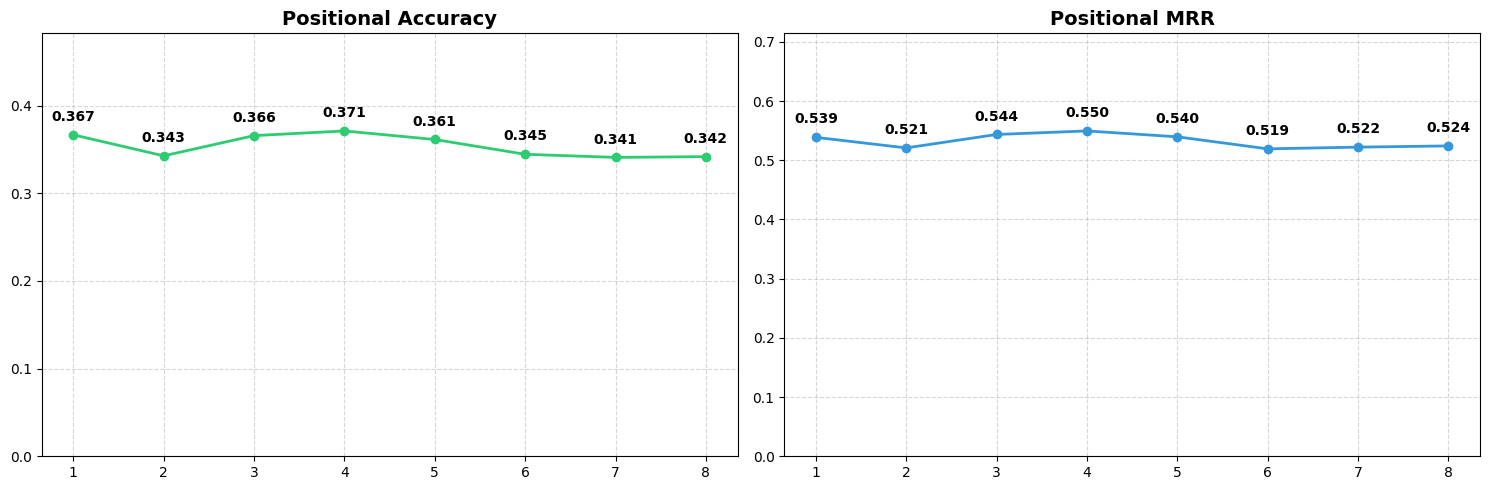


================= ИТОГОВЫЙ ОТЧЕТ =================
Non-Positional Recall@8: 0.3708
Mean NDCG@8:              0.6025
Mean Positional Accuracy: 0.3545
Mean Positional MRR:      0.5322


In [ ]:
import matplotlib.pyplot as plt

def run_visual_report(metrics):
    steps = np.arange(1, 9)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Настройки для двух графиков
    plot_configs = [
        (metrics['Step_Acc_List'], 'Positional Accuracy', '#2ecc71'),
        (metrics['Step_MRR_List'], 'Positional MRR', '#3498db')
    ]

    for i, (data, title, color) in enumerate(plot_configs):
        ax[i].plot(steps, data, marker='o', color=color, lw=2, label=title)
        ax[i].set_title(title, fontsize=14, fontweight='bold')
        ax[i].set_xticks(steps)
        ax[i].set_ylim(0, max(data) * 1.3 if max(data) > 0 else 1.0)
        ax[i].grid(ls='--', alpha=0.5)
        for x, y in zip(steps, data):
            ax[i].annotate(f'{y:.3f}', (x, y), textcoords="offset points",
                           xytext=(0,10), ha='center', weight='bold')

    plt.tight_layout()
    plt.show()

    # Итоговый текстовый отчет
    print(f"\n{' ИТОГОВЫЙ ОТЧЕТ ':=^50}")
    print(f"Non-Positional Recall@8: {metrics['Recall@8_Bag']:.4f}")
    print(f"Mean NDCG@8:              {metrics['Mean_NDCG@8']:.4f}")
    print(f"Mean Positional Accuracy: {metrics['Mean_Pos_Acc']:.4f}")
    print(f"Mean Positional MRR:      {metrics['Mean_Pos_MRR']:.4f}")
    print(f"{'='*50}")


results = evaluate_model_properly(spec_predictions['no_network'], all_true)
# 2. Рисуем и печатаем
run_visual_report(results)


In [ ]:
# Истинные последовательности должны быть в том же формате, что и предсказания
# (список списков строк)
all_true_val = [
    [str(v).strip() for v in seq if str(v).strip()]
    if isinstance(seq, list)
    else [v.strip() for v in str(seq).split(',') if v.strip()]
    for seq in test_df['Target']
]

# Считаем метрики
val_metrics = evaluate_predictions(
    all_preds=test_predictions,
    all_true=all_true_val,
    n_steps=8,
)

val_metrics

### Tail-Focused Embedding Architecture

Развивая идеи сетевых моделей мы решили попробовать спроектировать МСС коды в векторное пр-во с помощью их описаний и предобученного эмбеддера от VK https://github.com/avidale/encodechka (по результатам этого бенчмарка модель лучшая по критерию SLS и что немаловажно она небольшая и её легко развернуть в коллаб)

Для работы этой модели дополнительно нужен файл mcc_codes.csv отсюда https://mcc-codes.ru/code (сайт из спецификации)

In [ ]:
%reset # очищает пр-во локальных имён после этого надо запустить 1 ю ячейку

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


### Считываем данные

In [ ]:
df_codes = pd.read_csv("mcc_codes.csv")
df_train = pd.read_csv("df_train.csv", sep = ";")
df_test = pd.read_csv("df_test.csv", sep = ";")

def parse_mcc_list(x):
    if isinstance(x, str) and len(x.strip()) > 0:
        return [int(i) for i in x.split(',')]
    return []

# Парсим списки
df_train['Data'] = df_train['Data'].apply(parse_mcc_list)
df_train['Target'] = df_train['Target'].apply(parse_mcc_list)
df_test['Data'] = df_test['Data'].apply(parse_mcc_list)
df_test['Target'] = df_test['Target'].apply(parse_mcc_list)

###Блок фильтрации и замены редких MCC на "Blank" (95% порог)

In [ ]:

# 1. Собираем все MCC из колонки Data (трейн), чтобы посчитать их частоту
all_mccs = [mcc for sublist in df_train['Data'] for mcc in sublist]
mcc_counts = Counter(all_mccs)
total_count = len(all_mccs)

# 2. Сортируем MCC по убыванию частоты и считаем кумулятивный процент
sorted_mccs = mcc_counts.most_common()
top_mccs = set()
cumulative_sum = 0

print("Анализ частоты классов:")
for mcc, count in sorted_mccs:
    cumulative_sum += count
    top_mccs.add(mcc)
    if cumulative_sum / total_count >= 0.95:
        break

print(f"Всего уникальных MCC: {len(mcc_counts)}")
print(f"Оставляем топ-классов: {len(top_mccs)} (они покрывают 95% данных)")

# 3. Функция для замены редких MCC на "Blank" (используем -1 как заглушку)
BLANK_TOKEN = -1

def filter_rare_mccs(mcc_list, allowed_set):
    return [mcc if mcc in allowed_set else BLANK_TOKEN for mcc in mcc_list]

"""
Применяем фильтрацию к Data и Target в трейне и тесте
Важно: allowed_set берем ТОЛЬКО из трейна, чтобы избежать утечки данных

Не фильтруем дату так как модель учится работать не с конкретными кодами а с их векторными представлениями
(у похожих по смыслу классов например оно может быть схожее и несмотря на то, что один из классов встречается редко,
он все равно будет давать полезную информацию)
"""
df_train["Target_for_windws_fixed"] = df_train['Target'].apply(lambda x: list(x))
df_train['Target'] = df_train['Target'].apply(lambda x: filter_rare_mccs(x, top_mccs))



print(f"Замена завершена. Теперь в данных {len(top_mccs)} реальных классов и 1 общий 'Blank' (-1).")
# -----------------------------------------------------------


Анализ частоты классов:
Всего уникальных MCC: 183
Оставляем топ-классов: 32 (они покрывают 95% данных)
Замена завершена. Теперь в данных 32 реальных классов и 1 общий 'Blank' (-1).


### Получаем словарь для сосоставления эмбеддингов и MCC, препроцессинг

In [ ]:
import gc
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer

vkm_model = SentenceTransformer('deepvk/USER-bge-m3')

# 2. Список спец-токенов
special_mccs = ["PAD", "MASK", "BLANK"]
all_unique_mcc = special_mccs + sorted([str(m) for m in df_codes['MCC'].unique()])

descriptions = []
for mcc in all_unique_mcc:
    if mcc == "PAD":
        text = "0"
    elif mcc == "MASK":
        text = "замаскированная категория транзакции неизвестная операция"
    elif mcc == "BLANK":
        text = "прочие операции редкая категория транзакции"
    else:
        row_mask = df_codes['MCC'].astype(str) == mcc
        if row_mask.any():
            row = df_codes[row_mask].iloc[0]

            name = str(row.get('Название', '')).strip()
            desc = str(row.get('Описание', '')).strip()

            name = "" if name.lower() == 'nan' else name
            desc = "" if desc.lower() == 'nan' else desc

            # СТРАТЕГИЯ: Скипаем название, если есть описание
            # Если описания нет — берем название. Если и его нет — тех. текст.
            # Так как названия зачастую не очень информативны и иногда содержат лишние слова берем более информативное описание
            if desc and len(desc) > 5: # Если описание содержательное
                text = desc
            elif name:
                text = name
            else:
                text = f"категория транзакции {mcc}"
        else:
            text = f"неизвестный код {mcc}"

    descriptions.append(text)

with torch.no_grad():
    raw_embeddings = vkm_model.encode(
        descriptions,
        convert_to_tensor=True,
        show_progress_bar=True
    )

    vk_embeddings = raw_embeddings.clone()

    # Зануляем PAD - токен паддинга
    vk_embeddings[0] = 0.0

num_embeddings, embedding_dim = vk_embeddings.shape
mcc_embedding_layer = nn.Embedding.from_pretrained(
    vk_embeddings,
    freeze=True,     # Замораживаем, чтобы не переобучить на 3800 примерах
    padding_idx=0
)

mcc2idx = {mcc: i for i, mcc in enumerate(all_unique_mcc)}

# Очистка
del vkm_model, raw_embeddings
gc.collect()
torch.cuda.empty_cache()

print(f"Слой готов. PAD занулен: {torch.all(mcc_embedding_layer.weight[0] == 0).item()}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Слой готов. PAD занулен: True


In [ ]:
def preprocess_sequences(series, mapping):
    # Превращаем в индексы, неизвестные MCC мапим на BLANK (индекс 2)
    return [[mapping.get(str(mcc), 2) for mcc in seq] for seq in series]

df_train["idx_for_norm_sl"] = preprocess_sequences(df_train["Target_for_windws_fixed"], mcc2idx)
df_train['idx_data'] = preprocess_sequences(df_train['Data'], mcc2idx)
df_train['idx_target'] = preprocess_sequences(df_train['Target'], mcc2idx)



### Датасеты

Датасет который паддит все пос-ти до max_len и паддит токены с вероятностью mask_prob.
     Решено было от него отказаться и оставить только для валидации и теста из за того,
    что датасет со скользящими окнами показывал более высокую эффективность. Это скорее всего произошло из -за возможности серьёзно увеличить обучающую выборку и по видимому не сильной значимости начальных токенов.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MCCDataset(Dataset):
    """
    sequences - пос-ть данных
    targets - пос-ть таргетов
    mapping - словарь с сопоставлением индексов и кодов
    max_len - ожидаемае длинна к которой будут приведены все пос-ти в дата
    mask_prob - вероятность маскирования в дата
    targets_quant - переменная которая позволяет сократить длину таргета при необходимости
    """
    def __init__(self, sequences, targets, mapping, max_len=200, mask_prob=0.15, targets_quant = 8):
        self.sequences = sequences
        self.targets = targets
        self.mask_idx = mapping["MASK"]
        self.pad_idx = mapping["PAD"]
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.targets_quant = targets_quant

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = list(self.sequences[idx])

        # 2. Обрезаем или дополняем до max_len
        if len(seq) > self.max_len:
            seq = seq[-self.max_len:]
        else:
            seq = [self.pad_idx] * (self.max_len - len(seq)) + seq

        # 3. Рандомное маскирование (аугментация)
        # Маскируем только реальные данные, не трогаем PAD
        masked_seq = []
        for s in seq:
            if s != self.pad_idx and random.random() < self.mask_prob:
                masked_seq.append(self.mask_idx)
            else:
                masked_seq.append(s)


        target = self.targets[idx][:self.targets_quant]


        return torch.tensor(masked_seq), torch.tensor(target)

Датасет который клеит к разным пос-тям длинной window_size конечный таргеть юзера. Нужен чтобы обучить модель строить обобщённый прогноз для юзера.

In [ ]:
import torch
import random
from torch.utils.data import Dataset

import torch
from torch.utils.data import Dataset
import random

class MCCSlidingWindowDataset(Dataset):
    def __init__(self, sequences, targets, mapping, window_size=50, mask_prob = 0.15, target_len=8, step=5):
        """
        sequences - пос-ть данных
        targets - пос-ть таргетов
        mapping - словарь с сопоставлением индексов и кодов
        max_len - ожидаемае длинна к которой будут приведены все пос-ти в дата
        mask_prob - вероятность маскирования в дата
        targets_len - переменная которая позволяет сократить длину таргета при необходимости
        step - шаг через который мы берем следующие window_size элементов в таргет
        """
        self.pad_idx = mapping["PAD"]
        self.mask_idx = mapping["MASK"]
        self.window_size = window_size
        self.target_len = target_len
        self.mask_prob = mask_prob
        self.samples = []

        for i in range(len(sequences)):
            seq = list(sequences[i])
            targ = list(targets[i])

            # Нам нужно, чтобы таргета хватало на 8 месяцев
            if len(targ) < target_len:
                continue

            # Идем скользящим окном по истории
            # end_idx — это точка раздела между X и Y
            for end_idx in range(len(seq), 0, -step):
                # Берем X до этой точки
                curr_x = seq[:end_idx]
                curr_y = targ[:target_len]

                if len(curr_y) < target_len:
                    continue


                if len(curr_x) > window_size:
                    curr_x = curr_x[-window_size:]
                else:
                    curr_x = [self.pad_idx] * (window_size - len(curr_x)) + curr_x

                self.samples.append({'x': curr_x, 'y': curr_y})

                # Для коротких последовательностей берем только одно (последнее) окно
                if len(seq) <= window_size:
                    break

        print(f"Dataset initialized: {len(self.samples)} windows generated.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        x = torch.tensor(sample['x'], dtype=torch.long)
        y = torch.tensor(sample['y'], dtype=torch.long)

        # Рандомное маскирование (только для тренировки)
        if self.mask_prob > 0:
            mask = (torch.rand(x.shape) < self.mask_prob) & (x != self.pad_idx)
            x[mask] = self.mask_idx

        return x, y

Обычный sliding window

In [ ]:
class MCCRollingWindowDataset(Dataset):
    def __init__(self, sequences, targets, mapping, top_mccs, window_size=50, target_len=8, step=5, mask_prob=0.15):
        """
        sequences - пос-ть данных
        targets - пос-ть таргетов
        mapping - словарь с сопоставлением индексов и кодов
        max_len - ожидаемае длинна к которой будут приведены все пос-ти в дата
        mask_prob - вероятность маскирования в дата
        targets_len - переменная которая позволяет сократить длину таргета при необходимости
        step - шаг через который мы берем следующие window_size элементов в таргет
        top_mccs - список разрешенных MCC для фильтрации Y
        """
        self.pad_idx = mapping["PAD"]
        self.mask_idx = mapping["MASK"]
        self.blank_idx = mapping["BLANK"]

        # Перегоняем человекочитаемый ТОП в индексы, которые понимает модель
        self.allowed_indices = {mapping[str(mcc)] for mcc in top_mccs if str(mcc) in mapping}
        self.allowed_indices.add(self.blank_idx)

        self.window_size = window_size
        self.target_len = target_len
        self.mask_prob = mask_prob
        self.samples = []

        for i in range(len(sequences)):
            seq = list(sequences[i])    # История (уже в индексах)
            targ = list(targets[i])     # Будущее (уже в индексах)

            # Склеиваем в одну ленту времени для нарезки окон
            full_seq = seq + targ

            # Идем скользящим окном по всей длине
            for end_idx in range(len(full_seq) - target_len, 0, -step):

                # 1. X (История): Берем "сырые" индексы.
                # Модель учится на всем опыте клиента, даже редком.
                curr_x = full_seq[:end_idx]

                # 2. Y (Таргет): Жесткая фильтрация.
                # Все, чего нет в ТОПе, превращаем в BLANK.
                raw_y = full_seq[end_idx : end_idx + target_len]
                curr_y = [idx if idx in self.allowed_indices else self.blank_idx for idx in raw_y]

                if len(curr_y) < target_len:
                    continue

                # 3. Паддинг истории до фиксированного размера
                if len(curr_x) > window_size:
                    curr_x = curr_x[-window_size:]
                else:
                    curr_x = [self.pad_idx] * (window_size - len(curr_x)) + curr_x

                self.samples.append({'x': curr_x, 'y': curr_y})

                # Если история короткая, берем одно окно и идем к следующему юзеру
                if len(full_seq) <= window_size + target_len:
                    break

        print(f"Dataset ready: {len(self.samples)} windows.")
        print(f"Target classes: {len(self.allowed_indices)} (including BLANK)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        x = torch.tensor(s['x'], dtype=torch.long)
        y = torch.tensor(s['y'], dtype=torch.long)

        # Рандомная маска для обучения (делает модель умнее)
        if self.mask_prob > 0:
            mask = (torch.rand(x.shape) < self.mask_prob) & (x != self.pad_idx)
            x[mask] = self.mask_idx

        return x, y

### Модель

Проектируем эмбеддинги ВК на более низкую размерность прогоняем через пару линейных слоёв (потому что более сложные модели переобучаютя). Добавляем дропауты чтобы опять же не переобучалось модель. А потом делаем классификатор - голову для каждого из маментов времени (предсказание на +1, +2.....+8)

In [ ]:
import torch
import torch.nn as nn

class MCC_MultiBranch_Final(nn.Module):
    def __init__(self, emb_layer, num_classes, reduced_dim=128, tail_len=15, tail_dropout=0.2, target_len=8):
        super().__init__()
        self.embedding = emb_layer
        self.num_classes = num_classes
        self.reduced_dim = reduced_dim
        self.tail_len = tail_len
        self.target_len = target_len
        self.tail_dropout = nn.Dropout1d(tail_dropout)

        # 1. Проекция
        self.projection = nn.Linear(emb_layer.embedding_dim, reduced_dim)

        # 2. Блок лагов (Хвост) — выход 64
        self.last_n_projector = nn.Sequential(
            nn.Linear(self.tail_len * reduced_dim, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(128, 64)
        )

        # 3. Восемь независимых классификаторов вместо одного большого
        # Каждый берет 64 признака и выдает num_classes логитов
        self.heads = nn.ModuleList([
            nn.Linear(64, num_classes) for _ in range(target_len)
        ])

    def forward(self, x):
        batch_size, seq_len = x.shape

        # Эмбеддинги и проекция [B, T, 128]
        x_proj = self.projection(self.embedding(x))

        # Обработка хвоста
        if seq_len < self.tail_len:
            pad = torch.zeros(batch_size, self.tail_len - seq_len, self.reduced_dim, device=x.device)
            tail = torch.cat([pad, x_proj], dim=1)
        else:
            tail = x_proj[:, -self.tail_len:, :]

        tail = self.tail_dropout(tail)

        # Сплющиваем в вектор [B, 64]
        tail_flat = tail.reshape(batch_size, -1)
        features = self.last_n_projector(tail_flat)

        # ОПРОС ГОЛОВ:
        # Каждая голова i предсказывает свой месяц i
        all_logits = [head(features) for head in self.heads]

        # Склеиваем обратно в [B, 8, num_classes]
        logits = torch.stack(all_logits, dim=1)

        return logits


### Коллейт

In [ ]:
# 3. Collate Function (простая сборка в тензоры)
def mcc_collate_fn(batch):
    inputs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    return inputs, targets

###Создаём датасеты и прочие вспомогательные фичи

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


train_idx, val_idx = train_test_split(
    df_train.index,
    test_size=0.2,
    random_state=42
)



train_dataset = MCCRollingWindowDataset(
    sequences=df_train.loc[train_idx, 'idx_data'].values,
    targets=df_train.loc[train_idx, "idx_for_norm_sl"].values,
    mapping=mcc2idx,
    top_mccs=top_mccs,
    window_size=50,
    target_len=8,
    step=8,
    mask_prob=0.15
)

val_dataset = MCCDataset(
    sequences=df_train.loc[val_idx, 'idx_data'].values,
    targets=df_train.loc[val_idx, 'idx_target'].values,
    mapping=mcc2idx,
    max_len=200,
    mask_prob=0.0,
    targets_quant=8
)


train_loader = DataLoader(
    train_dataset,
    batch_size = 128,
    shuffle=True,
    collate_fn=mcc_collate_fn,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=mcc_collate_fn
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Dataset ready: 99475 windows.
Target classes: 33 (including BLANK)
Train batches: 777, Val batches: 18


Подсчёт метрик для валидации МРР Акк 1,5 и т.д чтоб понять что мы идём в правильном направлении

In [ ]:
def calculate_metrics(logits, targets, k=5):
    """
    logits: [batch, 8, num_classes] или [batch, num_classes]
    targets: [batch, 8] или [batch]
    """
    if logits.dim() == 3:
        logits = logits.reshape(-1, logits.size(-1))
        targets = targets.reshape(-1)

    mask = (targets != 0)
    if not mask.any(): return 0, 0, 0, set()

    logits = logits[mask]
    targets = targets[mask]

    _, top_k_indices = logits.topk(k, dim=1)
    correct_k = top_k_indices.eq(targets.view(-1, 1).expand_as(top_k_indices))

    acc1 = correct_k[:, 0].float().mean().item()
    acc5 = correct_k.any(dim=1).float().mean().item()
    target_logits = logits.gather(1, targets.view(-1, 1)) # [N, 1]

    ranks = (logits > target_logits).sum(dim=1)

    mrr = (1.0 / (ranks.float() + 1.0)).mean().item()

    preds = top_k_indices[:, 0].cpu().numpy()
    return acc1, acc5, mrr, set(preds)


Подсчёт метрик на валидации чтоб понять когда остановиться

In [ ]:
def validate(model, val_loader, criterion, device, num_active_classes):
    model.eval()
    val_loss = 0
    step_losses = {i: 0.0 for i in range(8)}

    total_acc1 = 0
    total_acc5 = 0
    total_mrr = 0
    total_count = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)


            for i in range(8):
                step_l = criterion(outputs[:, i, :], targets[:, i])
                step_losses[i] += step_l.item()


            loss = criterion(outputs.transpose(1, 2), targets)
            val_loss += loss.item()


            acc1, acc5, mrr, _ = calculate_metrics(outputs, targets)

            current_batch_size = inputs.size(0)
            total_acc1 += acc1 * current_batch_size
            total_acc5 += acc5 * current_batch_size
            total_mrr += mrr * current_batch_size
            total_count += current_batch_size

    num_batches = len(val_loader)


    results = {
        "loss": val_loss / num_batches,
        "acc1": (total_acc1 / total_count) * 100,
        "acc5": (total_acc5 / total_count) * 100,
        "mrr": total_mrr / total_count,
    }

    # Добавляем 8 индивидуальных лоссов
    for i in range(8):
        results[f"val_loss_step_{i}"] = step_losses[i] / num_batches

    return results


Приятный визуально цикл обучения

In [ ]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_acc1 = 0
    total_count = 0

    # Обертка tqdm для визуализации процесса
    pbar = tqdm(loader, desc="Training", leave=False)

    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()


        outputs = model(inputs)


        loss = criterion(outputs.transpose(1, 2), targets)

        loss.backward()
        optimizer.step()


        acc1, _, _, _ = calculate_metrics(outputs, targets)


        current_batch_size = inputs.size(0)
        total_loss += loss.item()
        total_acc1 += acc1 * current_batch_size
        total_count += current_batch_size


        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{(total_acc1 / total_count) * 100:.2f}%"
        })

    return total_loss / len(loader), (total_acc1 / total_count) * 100


Весовые коффициенты можно без них - будет лучше аккюраси, но модель не изучит несколько редких классов, с ними модель их изучит , но accuracy1 существенно просядет, мрр почти не изменится.

###Обучение с логгированием

Настройка параметров модели

Есть 2 модели - с датасетом MCCRollingWindowDataset(предсказывающая точно следующие токены) и с MCCSlidingWindowDataset(предсказывающая самые частые пос-ти из 8 для каждого юзера - классифицирующая его по стилю жизни)

Для MCCSlidingWindowDataset(https://www.comet.com/mmmm-fare/mcc-multi-branch)

При уменьшении количества параметров в проекциивкшных эмбеддингов для (reduced_dim) мрр падает на 0.02, что для обобщения нужно достаточно много(128) векторов и соответственно сильный дропаут - 0.5. При увеличении модель просто очень быстро переобучается. weight decay влияет тольеко на распределение точности по шагам. В процессе абеляционных исследований модель была сильно ужата так как выяснилось что основной обобщающий слой негативно влияет на качество. Как видно на графиках модель начинает упираться в плато(лосс на трейне и вале стабилизировался).

Для MCCRollingWindowDataset(https://www.comet.com/mmmm-fare/mcc-multi-branch-sliding-norm)

Уже используется ужатая модель так как эта модель эволюция предыдущей. Так как отличия в архитектуре минимальны достаточно быстро подобралось болшее число гиперпараметров. Основное давшее прорыв по качеству изменение  - уменьшение размерности проекции эмбеддингов до 64 и их дропаута, что позволило модели улавливать больше контекста и немного поднять MRR и сильно acc1

In [ ]:

num_classes = len(mcc2idx)
all_targets_flatten = [mcc for seq in df_train['idx_target'] for mcc in seq]
counts = np.bincount(all_targets_flatten, minlength=num_classes)

# 2. Рассчитываем веса (Smoothing через log)
#weights = 1.0 / np.log2(counts + 2.0) более сбалансированный вриант
weights = 1.0 / counts + 2.0 #менее сбалансированный, но получше общее качество

# 3. ОБНУЛЯЕМ веса для классов с нулевой частотой
# Если MCC ни разу не встретился, его вес в лоссе должен быть 0
weights[counts == 0] = 0.0

# 4. Явно обнуляем служебные токены (на всякий случай)
weights[mcc2idx['PAD']] = 0.0
if 'MASK' in mcc2idx:
    weights[mcc2idx['MASK']] = 0.0

# 5. Нормализация (необязательно, но полезно для стабильности LR)
# Чтобы средний вес был в районе 1.0
weights = weights / (weights[weights > 0].mean() + 1e-9)

class_weights = torch.FloatTensor(weights).to(device)



/tmp/ipykernel_773/2342773901.py:7: RuntimeWarning: divide by zero encountered in divide
  weights = 1.0 / counts + 2.0 #менее сбалансированный, но получше общее качество


Параметры обучения

In [ ]:
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=0,
    label_smoothing = 0.1 #для стабилизации обучения
)

model = MCC_MultiBranch_Final(
    emb_layer=mcc_embedding_layer,
    num_classes=len(mcc2idx),
    reduced_dim=64,
    tail_len = 50,
    tail_dropout = 0.2
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
num_active_classes = len(top_mccs)


#scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)




In [ ]:
!pip install comet_ml
from comet_ml import Experiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.8 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
num_epochs = 100 #100 эпох должно хватить, после
best_mrr = 0
num_active_classes = len(top_mccs)

from comet_ml import Experiment
import torch

# Инициализация Comet
experiment = Experiment(
    api_key="-",
    project_name="mcc-multi-branch_sliding_norm",
    workspace="mmmm-fare"
) #ключ я не дам) Параметры надо внести свои
# все параметры
config = {
    "reduced_dim": model.reduced_dim, # Размерность проекции эмбеддингов, случайно залогированно 2 раза
    "max_len": 200, #Ограничение по длинне истории
    "tail_len": model.tail_len, # сколько последних кодов видит модель
    "batch_size": train_loader.batch_size,
    "lr_start": optimizer.param_groups[0]['lr'],
    # Достаем weight_decay из первой группы параметров
    "weight_decay": optimizer.param_groups[0].get('weight_decay', 0),
    "optimizer_name": type(optimizer).__name__,
    "comp_emb_dim": model.reduced_dim, # Размерность проекции эмбеддингов
    "lags_dropout": model.tail_dropout, # Дропаут эмбеддингов
    "decreased" : "YES", #до аббеляционных исследований модель была CNN с UNET архитектурой пароаметр обозначает что чать CNN отсутствует
    "dataset_type" : "Sliding_window_sliding_target", # Тип датасета
    "8_head": "True"
}
experiment.log_parameters(config)


best_mrr = 0

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']

    # 1. Training
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    # 2. Validation (теперь возвращает 8 отдельных лоссов)
    v = validate(model, val_loader, criterion, device, num_active_classes)

    # 3. Scheduler
    scheduler.step(v['loss'])

    # 4. Логирование в Comet
    # Передаем весь словарь v, в нем уже лежат val_loss_step_0...7
    metrics_to_log = {
        "train_loss": train_loss,
        "train_acc": train_acc,
        "lr": current_lr,
        **v # Распаковываем все метрики из валидации
    }
    experiment.log_metrics(metrics_to_log, step=epoch)

    # Печать в консоль
    print(f"\n--- Эпоха {epoch+1:03d} | LR: {current_lr:.2e} ---")
    print(f"  [TRAIN] Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"  [VAL]   Loss: {v['loss']:.4f} | MRR: {v['mrr']:.4f}")
    # Выведем для примера лосс первого и последнего шага
    print(f"  [STEPS] Loss Step 0: {v['val_loss_step_0']:.4f} | Step 7: {v['val_loss_step_7']:.4f}")

    # 5. Сохранение лучшей модели
    if v['mrr'] > best_mrr:
        best_mrr = v['mrr']
        experiment.log_metric("best_val_mrr", best_mrr, step=epoch)

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_mrr': best_mrr,
            'mcc2idx': mcc2idx
        }
        torch.save(checkpoint, "best_mcc_model_checkpoint.pth")
        print(f"  ✨ Full Checkpoint Saved! MRR: {best_mrr:.4f}")

    # Защита от слишком маленького LR
    if current_lr < 1e-8:
        print("Learning rate too low. Stopping.")
        break

experiment.end()


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/mmmm-fare/mcc-multi-branch-sliding-norm/c17844ad8c6a4977a559f23629911bd5

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Training:   0%|          | 0/777 [00:00<?, ?it/s]


--- Эпоха 001 | LR: 1.00e-03 ---
  [TRAIN] Loss: 2.2038 | Acc: 28.20%
  [VAL]   Loss: 1.9222 | MRR: 0.5341
  [STEPS] Loss Step 0: 1.8936 | Step 7: 1.9171
  ✨ Full Checkpoint Saved! MRR: 0.5341


Training:   0%|          | 0/777 [00:00<?, ?it/s]

KeyboardInterrupt: 

Загрузка чекпоинта(рекомендуется вместо обучения модели) - есть 3 варианта модель которая описанна здесь(best_mcc_model_checkpoint_new_dset.pth) , модель взвешенная (best_mcc_model_checkpoint_weighted.pth), модель обобщающая показывающая очень качественную кластеризацию (best_mcc_model_checkpoint_final_lags)- для её обучения нужно изменить reduced_dim на 128 и tail_dropout на 0.5 остальные модели обучатся с текущими параметрами(кроме лосса) - в будущем её выходы можно пришить к 1 или 2 модели.



Грузить чекпоинт даже после обучения надо(т.к в цикле обучения сохраняется лучшая модель)

In [ ]:
checkpoint = torch.load("best_mcc_model_checkpoint.pth" , weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch'] + 1
best_mrr = checkpoint['best_mrr']

###Оценка модели

In [ ]:
# 1. Используем df_test для данных и таргета
df_test['idx_data'] = preprocess_sequences(df_test['Data'], mcc2idx)
df_test['idx_target'] = preprocess_sequences(df_test['Target'], mcc2idx)

# 2. Создаем Dataset (исправляем tset -> test и df_train -> df_test)
test_dataset = MCCDataset(
    sequences=df_test['idx_data'].values,
    targets=df_test['idx_target'].values,
    mapping=mcc2idx,
    max_len=200,
    mask_prob=0.0, # Для теста маскирование не нужно
    targets_quant=8
)

# 3. Создаем Loader (именно для test_dataset)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=mcc_collate_fn
)


In [ ]:
# Подготовим маппинг для отчетов (только твои TOP_MCC + BLANK)
relevant_mccs = [str(m) for m in top_mccs] + ["BLANK"]
idx2mcc_filtered = {mcc2idx[m]: m for m in relevant_mccs if m in mcc2idx}
target_indices = sorted(list(idx2mcc_filtered.keys()))


In [ ]:
import torch
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import classification_report

def run_final_eval(model, loader, device):
    model.eval()
    all_preds, all_targets, all_logits = [], [], []

    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Inference"):
            inputs = inputs.to(device)
            logits = model(inputs) # [B, 8, num_classes]
            preds = torch.argmax(logits, dim=-1) # [B, 8]

            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
            all_logits.append(logits.cpu())

    return torch.cat(all_preds, dim=0), torch.cat(all_targets, dim=0), torch.cat(all_logits, dim=0)

def show_step_analysis(f_preds, f_targets, f_logits, idx2mcc_dict, indices, step_idx):
    y_true = f_targets[:, step_idx].numpy()
    y_pred = f_preds[:, step_idx].numpy()

    # Расчет метрик
    acc = (y_pred == y_true).mean() * 100

    # MRR (Mean Reciprocal Rank)
    step_logits = f_logits[:, step_idx, :]
    _, sorted_indices = torch.sort(step_logits, descending=True, dim=1)
    ranks = (sorted_indices == torch.from_numpy(y_true).view(-1, 1)).nonzero()[:, 1]
    mrr = (1.0 / (ranks.float() + 1.0)).mean().item()

    print(f"\n" + "="*70)
    print(f"АНАЛИЗ ПРОГНОЗА НА МЕСЯЦ №{step_idx + 1}")
    print(f"Accuracy: {acc:.2f}% | MRR: {mrr:.4f}")
    print("-" * 70)

    # Формируем таблицу
    target_names = [str(idx2mcc_dict.get(i, i)) for i in indices]
    report = classification_report(
        y_true, y_pred,
        labels=indices,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    df = pd.DataFrame(report).transpose()
    # Сортируем по количеству примеров в тесте (support)
    stats = df.loc[target_names].sort_values(by='support', ascending=False)
    print(stats[['precision', 'recall', 'f1-score', 'support']].head(32))


In [ ]:
if 'idx_data' not in df_test.columns:
    df_test['idx_data'] = preprocess_sequences(df_test['Data'], mcc2idx)
    df_test['idx_target'] = preprocess_sequences(df_test['Target'], mcc2idx)

test_dataset = MCCDataset(
    sequences=df_test['idx_data'].values,
    targets=df_test['idx_target'].values,
    mapping=mcc2idx,
    max_len=200,
    mask_prob=0.0
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=mcc_collate_fn)


preds, targets, logits = run_final_eval(model, test_loader, device)


counts = Counter(targets.flatten().tolist())
if 0 in counts: del counts[0] # Убираем PAD
target_indices = [idx for idx, count in counts.most_common(32)]
idx2mcc_filtered = {idx: mcc for mcc, idx in mcc2idx.items()}

for i in range(8):
  show_step_analysis(preds, targets, logits, idx2mcc_filtered, target_indices, step_idx=i)




Inference:   0%|          | 0/22 [00:00<?, ?it/s]


АНАЛИЗ ПРОГНОЗА НА МЕСЯЦ №1
Accuracy: 39.47% | MRR: 0.5669
----------------------------------------------------------------------
      precision    recall  f1-score  support
6011   0.415205  0.608571  0.493627    350.0
4814   0.430233  0.414179  0.422053    268.0
5411   0.321809  0.601990  0.419411    201.0
4829   0.402439  0.275000  0.326733    120.0
6010   0.555556  0.180723  0.272727     83.0
5499   0.423077  0.314286  0.360656     70.0
5541   0.416667  0.119048  0.185185     42.0
5912   0.000000  0.000000  0.000000     36.0
5331   0.588235  0.370370  0.454545     27.0
5999   0.500000  0.250000  0.333333     20.0
5921   0.500000  0.350000  0.411765     20.0
5814   0.333333  0.052632  0.090909     19.0
5812   0.500000  0.176471  0.260870     17.0
5311   1.000000  0.200000  0.333333     10.0
5977   0.000000  0.000000  0.000000      8.0
5661   0.000000  0.000000  0.000000      8.0
5964   0.555556  0.714286  0.625000      7.0
5200   0.000000  0.000000  0.000000      7.0
8999   0.00000

In [ ]:
def show_fun_examples(model, loader, idx2mcc, n_examples=5):
    model.eval()
    device = next(model.parameters()).device

    # Берем один батч из лоадера
    inputs, targets = next(iter(loader))
    inputs_sub = inputs[:n_examples].to(device)
    targets_sub = targets[:n_examples]

    # Генерируем прогноз на 8 месяцев ОДНИМ проходом
    with torch.no_grad():
        logits = model(inputs_sub) # [B, 8, num_classes]
        preds = torch.argmax(logits, dim=-1).cpu() # [B, 8]

    print(f"{'№':<3} | {'Последние 10 трат из истории пользователя':<60}")
    print("-" * 115)

    for i in range(n_examples):
        # Очищаем историю от PAD и MASK для красивого вывода
        hist = [idx2mcc[idx.item()] for idx in inputs_sub[i]
                if idx.item() not in [mcc2idx.get('PAD', 0), mcc2idx.get('MASK', 1)]]

        # Берем последние 10 для контекста
        hist_str = ", ".join([str(c) for c in hist[-10:]])

        # Формируем строки таргета и прогноза
        target_str = " | ".join([f"{str(idx2mcc[idx.item()]):<5}" for idx in targets_sub[i]])
        pred_str   = " | ".join([f"{str(idx2mcc[idx.item()]):<5}" for idx in preds[i]])

        print(f"{i+1:<3} | {hist_str}")
        print(f"{'':<3} | РЕАЛ:  {target_str}")
        print(f"{'':<3} | ПРЕД:  {pred_str}")

        # Считаем попадания для этого юзера
        hits = (preds[i] == targets_sub[i]).sum().item()
        print(f"{'':<3} | Точных попаданий: {hits} из 8")
        print("-" * 115)

# 1. Создаем маппинг Индекс -> MCC (если еще нет)
idx2mcc_all = {v: k for k, v in mcc2idx.items()}

# 2. Запускаем просмотр
show_fun_examples(model, test_loader, idx2mcc_all, n_examples=20)


№   | Последние 10 трат из истории пользователя                   
-------------------------------------------------------------------------------------------------------------------
1   | 4814, 4814, 4814, 5499, 5541, 6011, 6011, 6011, 4814, 5499
    | РЕАЛ:  4814  | 5399  | 5399  | 5499  | 5331  | 5921  | 4814  | 6011 
    | ПРЕД:  4814  | 4814  | 4814  | 4814  | 4814  | 4814  | 4814  | 4814 
    | Точных попаданий: 2 из 8
-------------------------------------------------------------------------------------------------------------------
2   | 4829, 6011, 6536, 4814, 6010, 6011, 5942, 5947, 6011, 6011
    | РЕАЛ:  6011  | 4829  | 6010  | 6011  | 4814  | 6011  | 4829  | 6010 
    | ПРЕД:  6011  | 6011  | 6011  | 6011  | 6011  | 6011  | 6011  | 6011 
    | Точных попаданий: 3 из 8
-------------------------------------------------------------------------------------------------------------------
3   | 5813, 4814, 5331, 6010, 4814, 6011, 4829, 4814, 5499, 5499
    | РЕАЛ:  4829  | 4829  |

###Удобная интерактивная кластеризация

Группы эмбеддингов тут выделяются в профили людей(например богач) или времяпрепровождения( например отпуск). Соответственно кластеры строятся вокруг определённых паттернов трат. Дабл клик на точке чтоб посмотреть только определённый кластер.

In [ ]:
import pandas as pd
import numpy as np
import torch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# --- 1. Сбор активных MCC из всех данных ---
print("Собираем активные MCC...")
active_mccs = set()
for seq in df_train['Data']: active_mccs.update(map(str, seq))
for seq in df_train['Target']: active_mccs.update(map(str, seq))
for seq in df_test['Data']: active_mccs.update(map(str, seq))
active_mccs.update(["PAD", "MASK", "BLANK"])

indices_to_plot = []
mcc_labels = []
for mcc_code in active_mccs:
    if mcc_code in mcc2idx:
        indices_to_plot.append(mcc2idx[mcc_code])
        mcc_labels.append(mcc_code)

# --- 2. Извлечение эмбеддингов из модели (До и После) ---
model.eval()
with torch.no_grad():
    target_indices = torch.tensor(indices_to_plot).to(device)
    raw_embs = model.embedding(target_indices).cpu().numpy()
    projected_embs = model.projection(torch.tensor(raw_embs).to(device)).cpu().numpy()

# --- 3. Кластеризация и t-SNE ---
# Кластеризуем на основе ОБУЧЕННЫХ данных, чтобы увидеть новые группы
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
clusters_train = kmeans.fit_predict(projected_embs)

# На всякий случай кластеризуем исходные, чтобы сохранить логику "родных цветов" для левой части
kmeans_raw = KMeans(n_clusters=n_clusters, random_state=42, n_init=30)
clusters_raw = kmeans_raw.fit_predict(raw_embs)

tsne_settings = dict(n_components=2, perplexity=min(60, len(mcc_labels)-1), random_state=42, init='pca', learning_rate='auto')
print("Запуск t-SNE")
coords_raw = TSNE(**tsne_settings).fit_transform(raw_embs)
coords_train = TSNE(**tsne_settings).fit_transform(projected_embs)

# --- 4. Подготовка описаний из df_codes ---
descriptions = []
for mcc in mcc_labels:
    if mcc in ["PAD", "MASK", "BLANK"]:
        descriptions.append(f"Служебный токен: {mcc}")
    else:
        row = df_codes[df_codes['MCC'].astype(str) == mcc]
        name = str(row.iloc[0].get('Название', 'Без названия')) if not row.empty else "Нет в справочнике"
        descriptions.append(f"MCC {mcc}: {name}")

# --- 5. Создание общего DataFrame ---
df_compare = pd.DataFrame({
    'x_raw': coords_raw[:, 0], 'y_raw': coords_raw[:, 1],
    'x_train': coords_train[:, 0], 'y_train': coords_train[:, 1],
    'mcc': mcc_labels,
    'description': descriptions,
    'cluster_train': [f"Group {c}" for c in clusters_train],
    'cluster_raw': [f"Cluster {c}" for c in clusters_raw]
})

# --- 6. Отрисовка финального графика ---
palette_raw = px.colors.qualitative.Safe
palette_train = px.colors.qualitative.Alphabet

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("ДО (Текстовая семантика BGE-M3)", "ПОСЛЕ "),
    horizontal_spacing=0.07
)

unique_train_clusters = sorted(df_compare['cluster_train'].unique(), key=lambda x: int(x.split()[-1]))

for i, train_group in enumerate(unique_train_clusters):
    c_train_data = df_compare[df_compare['cluster_train'] == train_group]
    color_train = palette_train[i % len(palette_train)]

    # ПРАВАЯ ЧАСТЬ (Обученная проекция)
    fig.add_trace(
        go.Scatter(
            x=c_train_data['x_train'], y=c_train_data['y_train'],
            mode='markers+text', name=train_group,
            text=c_train_data['mcc'], hovertext=c_train_data['description'],
            marker=dict(color=color_train, size=11, opacity=0.8, line=dict(width=1, color='white')),
            textfont=dict(size=8), legendgroup=train_group, showlegend=True
        ), row=1, col=2
    )

    # ЛЕВЯЯ ЧАСТЬ (Синхронная отрисовка тех же точек)
    sub_raw_groups = c_train_data['cluster_raw'].unique()
    for raw_group in sub_raw_groups:
        sub_data = c_train_data[c_train_data['cluster_raw'] == raw_group]
        raw_cluster_num = int(raw_group.split()[-1])
        color_raw = palette_raw[raw_cluster_num % len(palette_raw)]

        fig.add_trace(
            go.Scatter(
                x=sub_data['x_raw'], y=sub_data['y_raw'],
                mode='markers+text', text=sub_data['mcc'],
                hovertext=sub_data['description'],
                marker=dict(color=color_raw, size=8, opacity=0.6),
                textfont=dict(size=7), legendgroup=train_group,
                showlegend=False, hoverinfo='text'
            ), row=1, col=1
        )

fig.update_layout(
    height=850, width=1550, template="plotly_white",
    title_text="Анализ трансформации MCC: Слева - исходная семантика, Справа - выученные зависимости",
    legend=dict(title="Группы обучения (ПОСЛЕ)", itemsizing="constant")
)
fig.update_traces(textposition='top center')

fig.show()


Собираем активные MCC...
Запуск t-SNE


Inference:   0%|          | 0/22 [00:00<?, ?it/s]

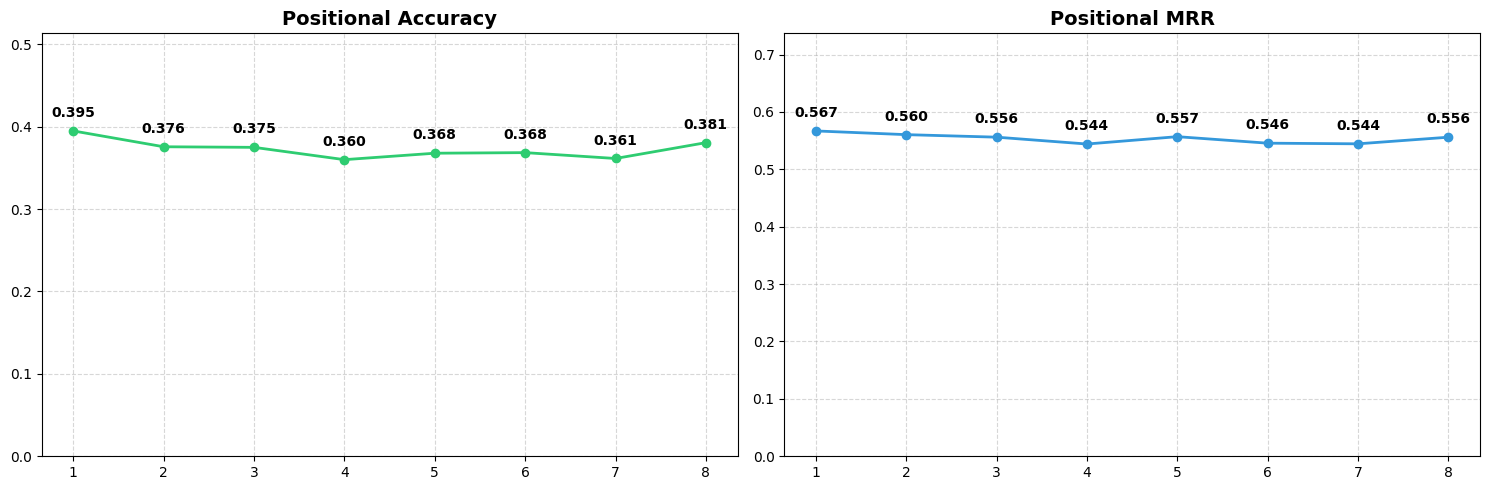


================= ИТОГОВЫЙ ОТЧЕТ =================
Non-Positional Recall@8: 0.4061
Mean NDCG@8:              0.6275
Mean Positional Accuracy: 0.3729
Mean Positional MRR:      0.5538
💡 Комментарий: Recall@8 0.4061 (мешок предсказаний vs мешок целей).


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

def run_full_evaluation(model, loader, device):
    model.eval()
    all_preds, all_targets, all_logits = [], [], []

    # 1. Инференс
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Inference"):
            inputs = inputs.to(device)
            logits = model(inputs) # [B, 8, num_classes]
            preds = torch.argmax(logits, dim=-1) # [B, 8]

            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
            all_logits.append(logits.cpu())

    f_preds = torch.cat(all_preds, dim=0)   # [N, 8]
    f_targets = torch.cat(all_targets, dim=0) # [N, 8]
    f_logits = torch.cat(all_logits, dim=0)   # [N, 8, num_classes]

    num_steps = 8

    # --- 2. РАСЧЕТ NON-POSITIONAL RECALL@8 (Логика "Двух мешков") ---
    batch_recalls = []
    for i in range(len(f_targets)):
        # Создаем "мешки" (multisets) из предсказаний и таргетов
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())

        # Пересечение мешков (& выбирает минимальное кол-во вхождений для каждого элемента)
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())

        batch_recalls.append(matches / float(num_steps))

    non_positional_recall = np.mean(batch_recalls)

    # --- 3. РАСЧЕТ POSITIONAL МЕТРИК И NDCG ---
    pos_acc, pos_mrr, step_ndcg = [], [], []

    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        logits_step = f_logits[:, i, :]

        # Accuracy & MRR
        pos_acc.append((y_pred == y_true).float().mean().item())

        _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)
        ranks = (sorted_idx == y_true.view(-1, 1)).nonzero()[:, 1]
        pos_mrr.append((1.0 / (ranks.float() + 1.0)).mean().item())

        # NDCG@8 (на конкретном шаге i)
        top8_idx = sorted_idx[:, :8]
        match_mask = (top8_idx == y_true.view(-1, 1))
        found_in_top8 = match_mask.any(dim=1)
        rank_in_top8 = match_mask.nonzero()[:, 1]

        ndcg_scores = torch.zeros(len(y_true))
        ndcg_scores[found_in_top8] = 1.0 / torch.log2(rank_in_top8.float() + 2.0)
        step_ndcg.append(ndcg_scores.mean().item())

    # --- 4. ВИЗУАЛИЗАЦИЯ ---
    steps = np.arange(1, 9)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    for i, (data, title, color) in enumerate(zip([pos_acc, pos_mrr],
                                               ['Positional Accuracy', 'Positional MRR'],
                                               ['#2ecc71', '#3498db'])):
        ax[i].plot(steps, data, marker='o', color=color, lw=2, label=title)
        ax[i].set_title(title, fontsize=14, fontweight='bold')
        ax[i].set_xticks(steps)
        ax[i].set_ylim(0, max(data) * 1.3)
        ax[i].grid(ls='--', alpha=0.5)
        for x, y in zip(steps, data):
            ax[i].annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', weight='bold')

    plt.tight_layout()
    plt.show()

    # --- 5. ИТОГОВЫЙ ВЫВОД ---
    print(f"\n{' ИТОГОВЫЙ ОТЧЕТ ':=^50}")
    print(f"Non-Positional Recall@8: {non_positional_recall:.4f}")
    print(f"Mean NDCG@8:              {np.mean(step_ndcg):.4f}")
    print(f"Mean Positional Accuracy: {np.mean(pos_acc):.4f}")
    print(f"Mean Positional MRR:      {np.mean(pos_mrr):.4f}")
    print(f"{'='*50}")
    print(f"💡 Комментарий: Recall@8 {non_positional_recall:.4f} (мешок предсказаний vs мешок целей).")

# Запуск
run_full_evaluation(model, test_loader, device)


In [ ]:
%reset # очищает пр-во локальных имён после этого надо запустить 1 ю ячейку

### LSTM

#### Шаг 1. Данные, словарь MCC, `MCCDataset`, класс `Seq2SeqLSTM`

- **Что делает ячейка:** читает CSV, отбрасывает строки без таргета, оставляет только строки с **ровно 8** кодами в `Target`, строит словарь MCC по train, паддинг истории до `MAX_LEN` (не больше 200), разбиение train / val 80/20.
- **Результат:** `train_df`, `val_df`, `token2idx`, `vocab_size`; готовы классы датасета и **`Seq2SeqLSTM`**. Обученных весов ещё нет.
- **Дальше:** запустите ячейку **«Шаг 2»** (обучение).


In [ ]:
# LSTM — загрузка данных, словарь, датасет, класс Seq2SeqLSTM
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_train_path = os.path.join(".", "df_train.csv")
_test_path = os.path.join(".", "df_test.csv")
train_raw = pd.read_csv(_train_path, sep=";")
test_raw = pd.read_csv(_test_path, sep=";")

print("Train shape:", train_raw.shape, "Test shape:", test_raw.shape)

train_raw = train_raw.dropna(subset=["Data", "Target"]).copy()
train_raw["data_seq"] = train_raw["Data"].apply(
    lambda x: [int(v.strip()) for v in str(x).split(",") if v.strip()]
)
train_raw["target_seq"] = train_raw["Target"].apply(
    lambda x: [int(v.strip()) for v in str(x).split(",") if v.strip()]
)
train_raw = train_raw[train_raw["target_seq"].map(len) == 8].reset_index(drop=True)

lens = train_raw["data_seq"].map(len)
print("Длина истории (квантили):", lens.quantile([0.5, 0.9, 0.95, 1.0]).to_dict())
print("Строк после фильтра:", len(train_raw))

all_tokens = sorted(
    {x for seq in train_raw["data_seq"] for x in seq}
    | {x for seq in train_raw["target_seq"] for x in seq}
)
PAD_TOKEN, SOS_TOKEN = 0, 1
token2idx = {"PAD": PAD_TOKEN, "<SOS>": SOS_TOKEN}
for i, t in enumerate(all_tokens, start=2):
    token2idx[t] = i
vocab_size = len(token2idx)

MAX_LEN = min(200, int(train_raw["data_seq"].map(len).max()))
print("MAX_LEN =", MAX_LEN, "vocab_size =", vocab_size)

train_raw["data_enc"] = train_raw["data_seq"].apply(lambda s: [token2idx[x] for x in s])
train_raw["target_enc"] = train_raw["target_seq"].apply(lambda s: [token2idx[x] for x in s])
train_raw["data_pad"] = train_raw["data_enc"].apply(
    lambda s: ([PAD_TOKEN] * (MAX_LEN - len(s)) + s) if len(s) < MAX_LEN else s[-MAX_LEN:]
)
train_raw["target_pad"] = train_raw["target_enc"].apply(lambda s: s[:8])

train_df, val_df = train_test_split(
    train_raw, test_size=0.2, random_state=SEED, shuffle=True
)
print("Train:", len(train_df), "Val:", len(val_df))


def metrics_from_preds(pred_idx: np.ndarray, y_idx: np.ndarray):
    exact = (pred_idx == y_idx).all(axis=1).mean()
    per_pos = (pred_idx == y_idx).mean(axis=0)
    micro = (pred_idx == y_idx).mean()
    return {"exact_acc": float(exact), "per_position": per_pos, "micro_acc": float(micro)}


y_val_idx = np.stack(val_df["target_enc"].tolist())


class MCCDataset(Dataset):
    def __init__(self, df):
        self.X = torch.tensor(np.stack(df["data_pad"].tolist()), dtype=torch.long)
        self.Y = torch.tensor(np.stack(df["target_pad"].tolist()), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]


class Seq2SeqLSTM(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=256, out_len=8):
        super().__init__()
        self.out_len = out_len
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=PAD_TOKEN)
        self.enc = nn.LSTM(emb, hid, batch_first=True)
        self.dec = nn.LSTM(emb, hid, batch_first=True)
        self.fc = nn.Linear(hid, vocab_size)
        self.map_h = nn.Linear(hid, hid)
        self.map_c = nn.Linear(hid, hid)

    def forward(self, x, y=None, teacher_force=0.5, mask_special=True):
        b = x.size(0)
        ex = self.emb(x)
        _, (h, c) = self.enc(ex)
        h = self.map_h(h)
        c = self.map_c(c)
        inp = torch.full((b, 1), SOS_TOKEN, dtype=torch.long, device=x.device)
        outs = []
        for t in range(self.out_len):
            d = self.emb(inp)
            o, (h, c) = self.dec(d, (h, c))
            logits = self.fc(o[:, 0, :])
            if mask_special:
                logits[:, PAD_TOKEN] = float("-inf")
                logits[:, SOS_TOKEN] = float("-inf")
            outs.append(logits.unsqueeze(1))
            if y is not None and random.random() < teacher_force:
                inp = y[:, t].unsqueeze(1)
            else:
                inp = logits.argmax(dim=1, keepdim=True)
        return torch.cat(outs, dim=1)

Train shape: (5627, 3) Test shape: (1406, 3)
Длина истории (квантили): {0.5: 200.0, 0.9: 200.0, 0.95: 200.0, 1.0: 200.0}
Строк после фильтра: 5627
MAX_LEN = 200 vocab_size = 185
Train: 4501 Val: 1126


#### Шаг 2. Обучение `model_lstm`

- **Что делает ячейка:** создаёт `DataLoader`, цикл эпох с teacher forcing, сохраняет лучшее состояние в **`best_state_lstm`**, загружает его в **`model_lstm`**, печатает метрики на val.
- **Результат:** обученная **`model_lstm`**; словарь истории обучения `hist_lstm` (при необходимости можно строить кривые loss).
- **Дальше:** ячейка **«Шаг 3»** — нужен файл **`model/best_mcc_model_checkpoint_new_dset.pth`**


In [ ]:
# LSTM — обучение Seq2Seq (teacher forcing)
BATCH = 64
EPOCHS = 30

train_dl = DataLoader(
    MCCDataset(train_df), batch_size=BATCH, shuffle=True, drop_last=True
)
val_dl = DataLoader(MCCDataset(val_df), batch_size=BATCH, shuffle=False)

model_lstm = Seq2SeqLSTM(vocab_size).to(device)
opt = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

hist_lstm = {"train_loss": [], "val_loss": [], "val_exact": []}
best_metric_lstm = (-1.0, float("inf"))
best_state_lstm = None
best_epoch_lstm = -1

for epoch in tqdm(range(1, EPOCHS + 1), desc="LSTM epochs"):
    model_lstm.train()
    tr_loss = 0.0
    for bx, by in tqdm(train_dl, desc=f"LSTM train e{epoch}", leave=False):
        bx, by = bx.to(device), by.to(device)
        opt.zero_grad()
        pred = model_lstm(bx, y=by, teacher_force=0.5)
        loss = crit(pred.view(-1, vocab_size), by.view(-1))
        loss.backward()
        opt.step()
        tr_loss += loss.item() * bx.size(0)
    tr_loss /= len(train_dl.dataset)

    model_lstm.eval()
    va_loss = 0.0
    all_p, all_y = [], []
    with torch.no_grad():
        for bx, by in tqdm(val_dl, desc=f"LSTM val e{epoch}", leave=False):
            bx, by = bx.to(device), by.to(device)
            pred = model_lstm(bx, y=None, teacher_force=0.0)
            va_loss += crit(pred.view(-1, vocab_size), by.view(-1)).item() * bx.size(0)
            all_p.append(pred.argmax(dim=2).cpu())
            all_y.append(by.cpu())
    va_loss /= len(val_dl.dataset)
    all_p = torch.cat(all_p)
    all_y = torch.cat(all_y)
    seq_acc = (all_p == all_y).all(dim=1).float().mean().item()
    hist_lstm["train_loss"].append(tr_loss)
    hist_lstm["val_loss"].append(va_loss)
    hist_lstm["val_exact"].append(seq_acc)
    print(
        f"LSTM epoch {epoch:02d}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  exact_acc={seq_acc:.4f}"
    )
    if (seq_acc > best_metric_lstm[0]) or (
        seq_acc == best_metric_lstm[0] and va_loss < best_metric_lstm[1]
    ):
        best_metric_lstm = (seq_acc, va_loss)
        best_epoch_lstm = epoch
        best_state_lstm = {
            k: v.detach().cpu().clone() for k, v in model_lstm.state_dict().items()
        }

model_lstm.load_state_dict(best_state_lstm)
model_lstm.to(device)
model_lstm.eval()
all_p = []
with torch.no_grad():
    for bx, by in tqdm(val_dl, desc="LSTM final val", leave=False):
        bx, by = bx.to(device), by.to(device)
        pred = model_lstm(bx, y=None, teacher_force=0.0)
        all_p.append(pred.argmax(dim=2).cpu())
all_p = torch.cat(all_p)
lstm_val_idx = all_p.numpy()
res_lstm = metrics_from_preds(lstm_val_idx, y_val_idx)
print(
    f"LSTM: лучшая эпоха по val = {best_epoch_lstm} "
    f"(exact={best_metric_lstm[0]:.4f}, val_loss={best_metric_lstm[1]:.4f})"
)
print("LSTM val:", res_lstm)



LSTM epochs:   0%|          | 0/30 [00:00<?, ?it/s]

LSTM train e1:   0%|          | 0/70 [00:00<?, ?it/s]

LSTM val e1:   0%|          | 0/18 [00:00<?, ?it/s]

LSTM epoch 01  train_loss=2.7193  val_loss=2.4015  exact_acc=0.0293


LSTM train e2:   0%|          | 0/70 [00:00<?, ?it/s]

...

LSTM train e30:   0%|          | 0/70 [00:00<?, ?it/s]

LSTM val e30:   0%|          | 0/18 [00:00<?, ?it/s]

LSTM epoch 30  train_loss=1.5874  val_loss=2.4164  exact_acc=0.0258


LSTM final val:   0%|          | 0/18 [00:00<?, ?it/s]

LSTM: лучшая эпоха по val = 12 (exact=0.0329, val_loss=2.2182)
LSTM val: {'exact_acc': 0.03285968028419183, 'per_position': array([0.38454707, 0.37566607, 0.35790409, 0.36412078, 0.35257549,
       0.34369449, 0.34369449, 0.35879218]), 'micro_acc': 0.36012433392539966}


#### Шаг 3. Оценка на test и чекпоинт Tail+8Heads

- **Что делает ячейка:** считает логиты LSTM на `df_test`, загружает веса команды с диска, считает те же метрики, что и **`run_full_evaluation`**; сохраняет **`checkpoints/best_lstm_state_dict.pt`** и дубликат весов tail в `checkpoints/`.
- **Результат:** `cmp`, `res_lstm_rank`, `res_tail_new_dset`, тензоры `logits_lstm`, `logits_tail` и таргеты для графиков.
- **Путь к модели команды:** переменная **`_CKPT_TAIL`** в коде (по умолчанию `model/best_mcc_model_checkpoint_new_dset.pth`). При другом расположении файла измените путь.
- **Дальше:** ячейка **«Шаг 4»** (таблица и рисунки), GPU не нужна.


In [ ]:
BATCH = 64
EPOCHS = 30
# LSTM — метрики как в run_full_evaluation, test, чекпоинт new_dset, сводная таблица
def _run_full_eval_from_logits(logits: torch.Tensor, targets: torch.Tensor):
    """Та же логика метрик, что в блоке run_full_evaluation выше по ноутбуку."""
    assert logits.dim() == 3 and targets.dim() == 2
    assert logits.size(0) == targets.size(0) and logits.size(1) == targets.size(1) == 8

    f_targets = targets.detach().cpu()
    f_logits = logits.detach().cpu()
    f_preds = torch.argmax(f_logits, dim=-1)
    num_steps = 8

    batch_recalls = []
    for i in range(len(f_targets)):
        pred_bag = Counter(f_preds[i].tolist())
        target_bag = Counter(f_targets[i].tolist())
        intersection = pred_bag & target_bag
        matches = sum(intersection.values())
        batch_recalls.append(matches / float(num_steps))
    recall8 = float(np.mean(batch_recalls))

    pos_acc, pos_mrr, step_ndcg = [], [], []
    for i in range(num_steps):
        y_true = f_targets[:, i]
        y_pred = f_preds[:, i]
        logits_step = f_logits[:, i, :]

        pos_acc.append((y_pred == y_true).float().mean().item())

        _, sorted_idx = torch.sort(logits_step, descending=True, dim=1)
        ranks = (sorted_idx == y_true.view(-1, 1)).nonzero()[:, 1]
        pos_mrr.append((1.0 / (ranks.float() + 1.0)).mean().item())

        top8_idx = sorted_idx[:, :8]
        match_mask = top8_idx == y_true.view(-1, 1)
        found_in_top8 = match_mask.any(dim=1)
        rank_in_top8 = match_mask.nonzero()[:, 1]

        ndcg_scores = torch.zeros(len(y_true))
        ndcg_scores[found_in_top8] = 1.0 / torch.log2(rank_in_top8.float() + 2.0)
        step_ndcg.append(ndcg_scores.mean().item())

    return {
        "Recall@8": recall8,
        "Positional Accuracy": float(np.mean(pos_acc)),
        "Positional MRR": float(np.mean(pos_mrr)),
        "NDCG@8": float(np.mean(step_ndcg)),
        "pos_acc_steps": np.array(pos_acc, dtype=float),
        "pos_mrr_steps": np.array(pos_mrr, dtype=float),
        "ndcg_steps": np.array(step_ndcg, dtype=float),
    }


@torch.no_grad()
def _collect_logits_seq2seq(model_seq2seq, loader: DataLoader):
    model_seq2seq.eval()
    all_logits, all_targets = [], []
    for bx, by in loader:
        bx = bx.to(device)
        lg = model_seq2seq(bx, y=None, teacher_force=0.0, mask_special=False)
        all_logits.append(lg.detach().cpu())
        all_targets.append(by.detach().cpu())
    return torch.cat(all_logits, dim=0), torch.cat(all_targets, dim=0)


class MCC_MultiBranch_Final(nn.Module):
    def __init__(
        self,
        emb_layer,
        num_classes,
        reduced_dim=64,
        tail_len=15,
        tail_dropout=0.2,
        target_len=8,
    ):
        super().__init__()
        self.embedding = emb_layer
        self.num_classes = num_classes
        self.reduced_dim = reduced_dim
        self.tail_len = tail_len
        self.target_len = target_len
        self.tail_dropout = nn.Dropout(tail_dropout)
        self.projection = nn.Linear(emb_layer.embedding_dim, reduced_dim)
        self.last_n_projector = nn.Sequential(
            nn.Linear(self.tail_len * reduced_dim, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
        )
        self.heads = nn.ModuleList([nn.Linear(64, num_classes) for _ in range(target_len)])

    def forward(self, x):
        batch_size, seq_len = x.shape
        x_proj = self.projection(self.embedding(x))
        if seq_len < self.tail_len:
            pad = torch.zeros(
                batch_size,
                self.tail_len - seq_len,
                self.reduced_dim,
                device=x.device,
            )
            tail = torch.cat([pad, x_proj], dim=1)
        else:
            tail = x_proj[:, -self.tail_len :, :]
        tail = self.tail_dropout(tail)
        tail_flat = tail.reshape(batch_size, -1)
        features = self.last_n_projector(tail_flat)
        all_logits = [head(features) for head in self.heads]
        return torch.stack(all_logits, dim=1)


def _parse_seq_str(s):
    return [int(x) for x in str(s).split(",") if str(x).strip()]


test_eval = test_raw.copy()
test_eval["data_seq"] = test_eval["Data"].map(_parse_seq_str)
test_eval["target_seq"] = test_eval["Target"].map(_parse_seq_str)

flat_train = [x for seq in train_raw["data_seq"] for x in seq]
most_common_mcc = int(Counter(flat_train).most_common(1)[0][0])
unk_idx_lstm = int(token2idx[most_common_mcc])


def _encode_lstm_seq(seq):
    ids = [int(token2idx.get(int(x), unk_idx_lstm)) for x in seq]
    if len(ids) < MAX_LEN:
        ids = [PAD_TOKEN] * (MAX_LEN - len(ids)) + ids
    else:
        ids = ids[-MAX_LEN:]
    return ids


def _encode_lstm_target(seq):
    ids = [int(token2idx.get(int(x), unk_idx_lstm)) for x in seq[:8]]
    if len(ids) < 8:
        ids = ids + [PAD_TOKEN] * (8 - len(ids))
    return ids


test_eval["data_pad"] = test_eval["data_seq"].map(_encode_lstm_seq)
test_eval["target_pad"] = test_eval["target_seq"].map(_encode_lstm_target)
test_dl = DataLoader(MCCDataset(test_eval), batch_size=BATCH, shuffle=False)

logits_lstm, targets_test_lstm = _collect_logits_seq2seq(model_lstm, test_dl)
res_lstm_rank = _run_full_eval_from_logits(logits_lstm, targets_test_lstm)

os.makedirs("checkpoints", exist_ok=True)
lstm_ckpt_path = "checkpoints/best_lstm_state_dict.pt"
torch.save(
    {
        "state_dict": best_state_lstm,
        "vocab_size": vocab_size,
        "MAX_LEN": MAX_LEN,
        "PAD_TOKEN": PAD_TOKEN,
        "SOS_TOKEN": SOS_TOKEN,
        "SEED": SEED,
    },
    lstm_ckpt_path,
)
print("Saved:", lstm_ckpt_path)


@torch.no_grad()
def _collect_logits_direct(model_direct, loader: DataLoader):
    model_direct.eval()
    all_logits, all_targets = [], []
    for bx, by in loader:
        bx = bx.to(device)
        lg = model_direct(bx)
        all_logits.append(lg.detach().cpu())
        all_targets.append(by.detach().cpu())
    return torch.cat(all_logits, dim=0), torch.cat(all_targets, dim=0)


def _eval_ckpt_on_test(ckpt_path, label):
    try:
        ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError:
        ck = torch.load(ckpt_path, map_location="cpu")
    sd = ck["model_state_dict"]
    mcc2idx_ck = ck["mcc2idx"]
    PAD_CK = int(mcc2idx_ck.get("PAD", 0))
    num_classes_ck = int(sd["embedding.weight"].shape[0])
    emb_dim_ck = int(sd["embedding.weight"].shape[1])
    reduced_dim_ck = int(sd["projection.weight"].shape[0])
    flat_in = int(sd["last_n_projector.0.weight"].shape[1])
    tail_len_ck = int(flat_in // reduced_dim_ck)
    emb_ck = nn.Embedding(num_classes_ck, emb_dim_ck, padding_idx=PAD_CK)
    m = MCC_MultiBranch_Final(
        emb_layer=emb_ck,
        num_classes=num_classes_ck,
        reduced_dim=reduced_dim_ck,
        tail_len=tail_len_ck,
        tail_dropout=0.2,
        target_len=8,
    ).to(device)
    m.load_state_dict(sd, strict=True)
    m.eval()

    def enc_x(seq):
        ids = [mcc2idx_ck.get(str(int(x)), PAD_CK) for x in seq]
        if len(ids) < MAX_LEN:
            ids = [PAD_CK] * (MAX_LEN - len(ids)) + ids
        else:
            ids = ids[-MAX_LEN:]
        return np.array(ids, dtype=np.int64)

    def enc_y(seq):
        ids = [mcc2idx_ck.get(str(int(x)), PAD_CK) for x in seq[:8]]
        if len(ids) < 8:
            ids = ids + [PAD_CK] * (8 - len(ids))
        return np.array(ids, dtype=np.int64)

    class _DS(Dataset):
        def __init__(self, df):
            self.X = torch.tensor(
                np.stack(df["data_seq"].apply(lambda s: enc_x(list(s))).tolist()),
                dtype=torch.long,
            )
            self.Y = torch.tensor(
                np.stack(df["target_seq"].apply(lambda s: enc_y(list(s))).tolist()),
                dtype=torch.long,
            )

        def __len__(self):
            return len(self.X)

        def __getitem__(self, i):
            return self.X[i], self.Y[i]

    dl = DataLoader(_DS(test_eval), batch_size=BATCH, shuffle=False)
    lg, yy = _collect_logits_direct(m, dl)
    res = _run_full_eval_from_logits(lg, yy)
    out_path = f"checkpoints/{label}_state_dict.pt"
    torch.save(
        {
            "state_dict": sd,
            "best_mrr": float(ck.get("best_mrr", float("nan"))),
            "epoch": int(ck.get("epoch", -1)),
            "mcc2idx": mcc2idx_ck,
            "arch": {
                "num_classes": num_classes_ck,
                "emb_dim": emb_dim_ck,
                "reduced_dim": reduced_dim_ck,
                "tail_len": tail_len_ck,
                "target_len": 8,
            },
        },
        out_path,
    )
    print("Loaded checkpoint:", ckpt_path, "->", label, "| reduced_dim=", reduced_dim_ck)
    print("Saved:", out_path)
    return res, lg, yy


_CKPT_TAIL = os.path.join("model", "best_mcc_model_checkpoint_new_dset.pth")
res_tail_new_dset, logits_tail, targets_tail_test = _eval_ckpt_on_test(
    _CKPT_TAIL, "model_ckpt_new_dset"
)

cmp = pd.DataFrame(
    [
        {
            "model": "LSTM (test)",
            "Positional Accuracy": res_lstm_rank["Positional Accuracy"],
            "Positional MRR": res_lstm_rank["Positional MRR"],
            "NDCG@8": res_lstm_rank["NDCG@8"],
            "Recall@8": res_lstm_rank["Recall@8"],
        },
        {
            "model": "Tail+8Heads (test)",
            "Positional Accuracy": res_tail_new_dset["Positional Accuracy"],
            "Positional MRR": res_tail_new_dset["Positional MRR"],
            "NDCG@8": res_tail_new_dset["NDCG@8"],
            "Recall@8": res_tail_new_dset["Recall@8"],
        },
    ]
)

Saved: checkpoints/best_lstm_state_dict.pt
Loaded checkpoint: model/best_mcc_model_checkpoint_new_dset.pth -> model_ckpt_new_dset | reduced_dim= 64
Saved: checkpoints/model_ckpt_new_dset_state_dict.pt


#### Шаг 4. Таблица и графики сравнения

- **Что делает ячейка:** выводит таблицу `cmp`, сохраняет **`comparison_table.png`**, строит четыре графика метрик по шагам 1–8 и столбчатую диаграмму средних метрик.
- **Условие:** в памяти ядра должны остаться переменные после **шага 3**. Если ядро перезапускали — сначала выполните шаги 1–3 (обучение можно пропустить только если воссоздаёте переменные из сохранённого состояния вручную).
- **Подпись 4-го графика:** напоминает, что это **hit@8 по шагам**, а не multiset Recall@8 из таблицы.


,model,Positional Accuracy,Positional MRR,NDCG@8,Recall@8
1,Tail+8Heads (test),0.372866,0.553789,0.627488,0.406117
0,LSTM (test),0.353396,0.543484,0.620634,0.427009


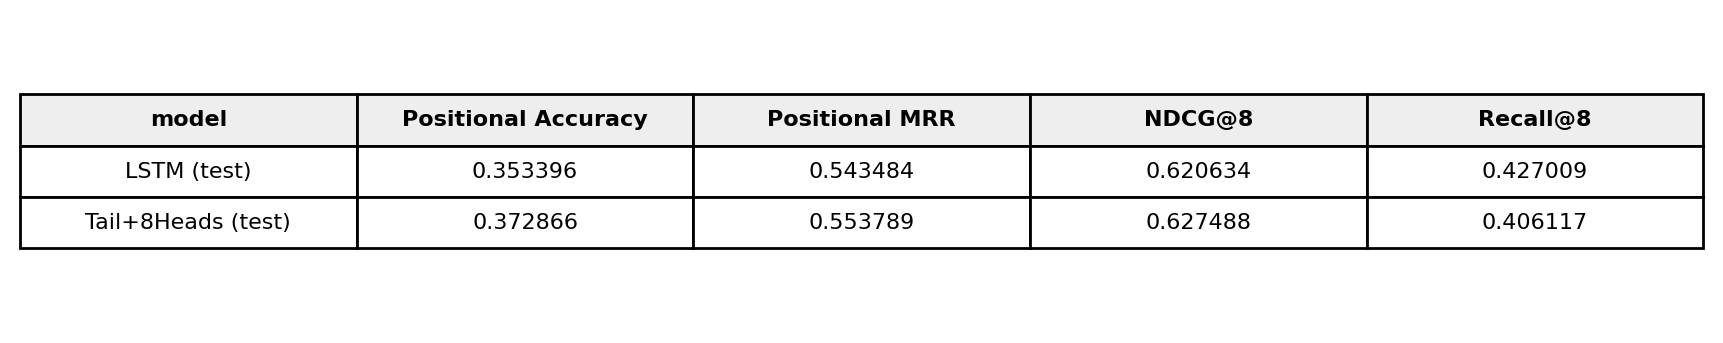

Saved: comparison_table.png


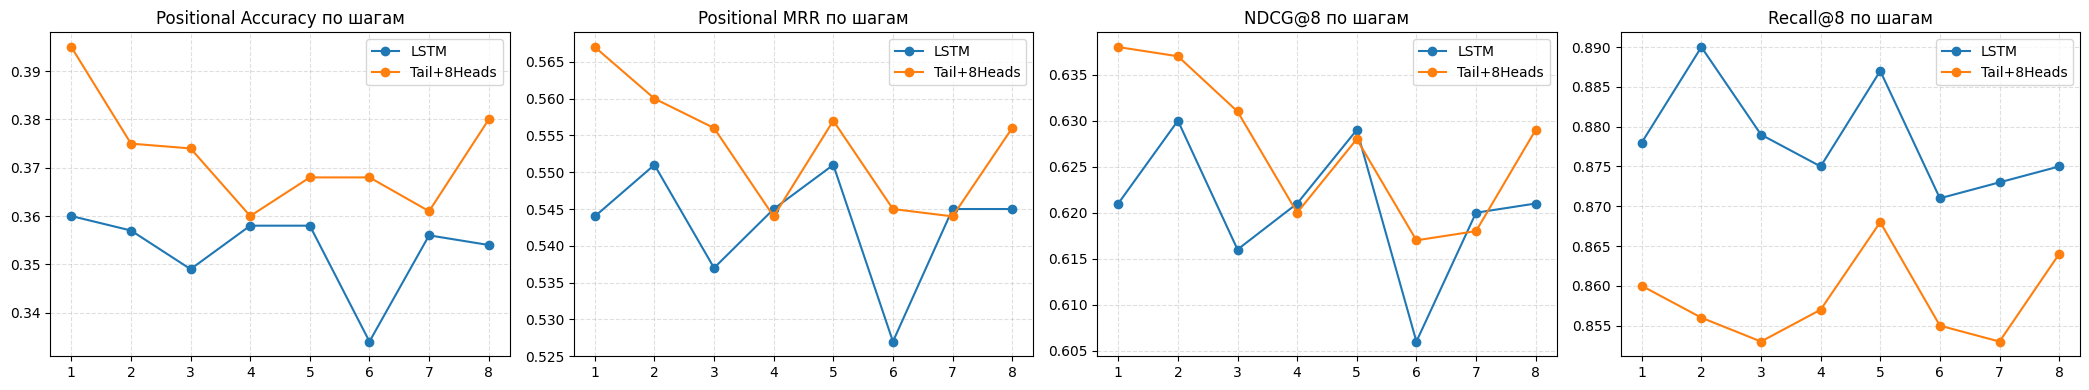

Saved: comparison_steps.png


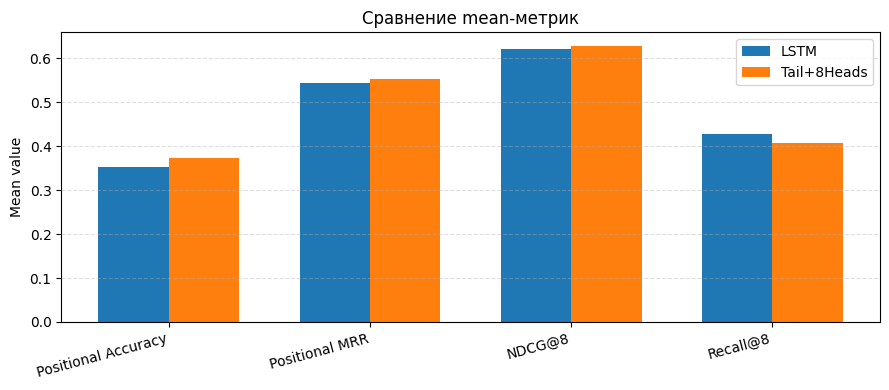

Saved: comparison_mean_bars.png


In [ ]:
# LSTM — отображение таблицы, сохранение PNG и графики сравнения
import matplotlib.pyplot as plt

try:
    from IPython.display import display

    display(cmp.sort_values("NDCG@8", ascending=False))
except Exception:
    print(cmp.sort_values("NDCG@8", ascending=False))

fig, ax = plt.subplots(figsize=(8.5, 1.6), dpi=200)
ax.axis("off")
cmp_img = cmp.copy()
for col in ["Positional Accuracy", "Positional MRR", "NDCG@8", "Recall@8"]:
    cmp_img[col] = cmp_img[col].map(lambda x: f"{float(x):.6f}")
tbl = ax.table(
    cellText=cmp_img.values,
    colLabels=cmp_img.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.25)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#eeeeee")
out_png = "comparison_table.png"
plt.tight_layout(pad=0.3)
plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png)


@torch.no_grad()
def _hit_in_top8_per_step(logits: torch.Tensor, targets: torch.Tensor):
    logits = logits.detach().cpu()
    targets = targets.detach().cpu()
    _, sorted_idx = torch.sort(logits, descending=True, dim=2)
    top8 = sorted_idx[:, :, :8]
    hit = (top8 == targets.unsqueeze(-1)).any(dim=2).float()
    return hit.mean(dim=0).numpy()


steps = np.arange(1, 9)
rec_steps_lstm = _hit_in_top8_per_step(logits_lstm, targets_test_lstm)
rec_steps_tail = _hit_in_top8_per_step(logits_tail, targets_tail_test)

fig, ax = plt.subplots(1, 4, figsize=(21, 4))
ax[0].plot(steps, res_lstm_rank["pos_acc_steps"], "o-", label="LSTM")
ax[0].plot(steps, res_tail_new_dset["pos_acc_steps"], "o-", label="Tail+8Heads")
ax[0].set_title("Positional Accuracy по шагам")
ax[0].set_xticks(steps)
ax[0].grid(ls="--", alpha=0.4)
ax[0].legend()

ax[1].plot(steps, res_lstm_rank["pos_mrr_steps"], "o-", label="LSTM")
ax[1].plot(steps, res_tail_new_dset["pos_mrr_steps"], "o-", label="Tail+8Heads")
ax[1].set_title("Positional MRR по шагам")
ax[1].set_xticks(steps)
ax[1].grid(ls="--", alpha=0.4)
ax[1].legend()

ax[2].plot(steps, res_lstm_rank["ndcg_steps"], "o-", label="LSTM")
ax[2].plot(steps, res_tail_new_dset["ndcg_steps"], "o-", label="Tail+8Heads")
ax[2].set_title("NDCG@8 по шагам")
ax[2].set_xticks(steps)
ax[2].grid(ls="--", alpha=0.4)
ax[2].legend()

ax[3].plot(steps, rec_steps_lstm, "o-", label="LSTM")
ax[3].plot(steps, rec_steps_tail, "o-", label="Tail+8Heads")
ax[3].set_title("Hit@8 по шагам (табличный Recall@8 — multiset top-1)")
ax[3].set_xticks(steps)
ax[3].grid(ls="--", alpha=0.4)
ax[3].legend()
plt.tight_layout()
plt.show()

metrics = ["Positional Accuracy", "Positional MRR", "NDCG@8", "Recall@8"]
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, [res_lstm_rank[m] for m in metrics], width, label="LSTM")
ax.bar(x + width / 2, [res_tail_new_dset[m] for m in metrics], width, label="Tail+8Heads")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.set_ylabel("Mean value")
ax.set_title("Сравнение mean-метрик")
ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

